# Thesis Models 2026 — **v6 THESIS (Full Retrain — یەکجار)**

## ئامانج
یەک pipeline بۆ لیژنە: **text + vision + dual τ + general-phish vaccine + هەموو holdout**.

## Output (تەنها ئەم فۆlderانە)
| Path | چی |
|------|-----|
| `saved_models_thesis/` | text Ultimate_Pro (+ vision ResNet) |
| `results_thesis/` | **هەموو CSV/grap** |

## FULL RETRAIN — Run order (≈8–14h GPU)
```
1 → 2 → 2PRE → 6G → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 10V → 10B → 11 → 25 → 15 → 26 → 14 → 22 → 27F → THESIS
```
| Step | Cell | کات |
|------|------|-----|
| Mount + config | 1, 2 | 2m |
| Restore train + inject | 2PRE, 6G, 3 | 5m |
| Encode + train text | 4–10 | **3–5h** |
| Vision | 10V, 10B | **2–4h** |
| Eval all | 11,25,14,22,27F,THESIS | 1h |

**Cell 2:** `FORCE_RETRAIN = True` · `FULL_RETRAIN_RESET_TRAIN = True`

**Skip 10FT** when FORCE_RETRAIN=True (Cell 10 uses full train including vaccine).

## Upload پێش Colab
- `vaccines/general_phish_vaccine_v65.csv` → `Balanced_Thesis_Dataset_2026/vaccines/`
- `output_v6/train_base_v632k.csv` (optional — بۆ 2PRE restore)

## Primary thesis metrics (Cell 14 + THESIS)
Homoglyph TPR · Unicode FPR · Trusted FPR · Demo100 · Cascade B0/B1/C


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Mount Google Drive (same Gmail as upload account!)
# ══════════════════════════════════════════════════════════════
from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)

if not os.path.isdir("/content/drive/MyDrive"):
    raise RuntimeError("Drive mount failed — try Runtime > Restart, then re-run Cell 1.")
print("Drive mounted OK.")

Mounted at /content/drive
Drive mounted OK.


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Paths & Hyperparameters
# Google Drive: MyDrive > Master2026 > All_Models >
#               Balanced_Thesis_Dataset_2026 > output_v6  (v6 honest ML retrain experiment)
# ══════════════════════════════════════════════════════════════
import os

MYDRIVE = "/content/drive/MyDrive"
DATASET_FOLDER = "output_v6"  # NOT output_v4 — v4 text model can be copied to saved_models_v6

DRIVE_PATH_PARTS = [
    "Master2026",
    "All_Models",
    "Balanced_Thesis_Dataset_2026",
    DATASET_FOLDER,
]

REQUIRED_CSVS = [
    "train.csv", "val.csv", "test.csv",
    "holdout_homoglyph_test.csv",
    "holdout_unicode_safe_test.csv",
    "holdout_trusted_safe_test.csv",
]

if not os.path.isdir(MYDRIVE):
    raise RuntimeError("Drive not mounted! Run CELL 1 first.")


def ci_child(parent, name):
    """Find subfolder ignoring upper/lower case."""
    if not os.path.isdir(parent):
        return None
    want = name.lower()
    for entry in os.listdir(parent):
        if entry.lower() == want:
            return os.path.join(parent, entry)
    return None


def resolve_path(parts):
    p = MYDRIVE
    for part in parts:
        p = ci_child(p, part)
        if p is None:
            return None
    return p


def has_all_csvs(folder):
    return all(os.path.isfile(os.path.join(folder, f)) for f in REQUIRED_CSVS)


# 1) ڕێڕەوی ڕاستەوخۆ
BASE = resolve_path(DRIVE_PATH_PARTS)
DRIVE_ROOT = resolve_path(DRIVE_PATH_PARTS[:-2])  # .../All_Models

if BASE and has_all_csvs(BASE):
    print("Dataset path OK (fixed Drive layout):")
    print(f"  {BASE}")
else:
    # 2) Fallback: گەڕان لە هەموو Drive
    print("Fixed path not visible — searching full Drive (1-3 min)...")
    BASE = None
    for dirpath, _, filenames in os.walk(MYDRIVE):
        if os.path.basename(dirpath).lower() != DATASET_FOLDER.lower():
            continue
        if all(f in filenames for f in REQUIRED_CSVS):
            BASE = dirpath
            break
    if BASE:
        DRIVE_ROOT = resolve_path(["Master2026", "All_Models"]) or os.path.dirname(
            os.path.dirname(BASE)
        )
        print(f"Found via search:\n  {BASE}")
    else:
        print("MyDrive root folders:", os.listdir(MYDRIVE)[:20])
        master = ci_child(MYDRIVE, "Master2026")
        print("Master2026 visible:", master)
        raise FileNotFoundError(
            "output_v6 not found! Upload output_v6 folder to Drive.\n"
            "1) Colab = SAME Gmail as Drive (see screenshot owner)\n"
            "2) Re-run Cell 1 with force_remount\n"
            "3) Path must be: MyDrive/Master2026/All_Models/"
            "Balanced_Thesis_Dataset_2026/output_v6"
        )

missing = [f for f in REQUIRED_CSVS if not os.path.isfile(os.path.join(BASE, f))]
if missing:
    raise FileNotFoundError(f"Missing in {BASE}:\n  " + "\n  ".join(missing))
print(f"OK — all {len(REQUIRED_CSVS)} CSV files ready")

# ── v6.3 isolated output dirs (do NOT overwrite v6.2) ───────────────────────
VERSION_TAG = "v6_THESIS_FULL"
TEXT_MODELS_DIR = os.path.join(DRIVE_ROOT, "Thesis_Models_2026", "saved_models_thesis")
MODELS_DIR = os.path.join(DRIVE_ROOT, "Thesis_Models_2026", "saved_models_thesis")
RESULTS_DIR = os.path.join(DRIVE_ROOT, "Thesis_Models_2026", "results_thesis")
VISUAL_DIR_NAME = "visual_dataset_v63"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR, "vision"), exist_ok=True)
print("FULL RETRAIN -> saved_models_thesis/ + results_thesis/")

# Hyperparameters
SEED = 42
MAX_LENGTH = 256
VOCAB_SIZE = 65536
EMBED_DIM = 64
BATCH_SIZE = 512
EPOCHS = 10
FINAL_THRESHOLD = 0.50  # fallback only if AUTO_TUNE off (sklearn default for binary)
AUTO_TUNE_THRESHOLD = True  # Cell 15: grid-search τ on validation F1 (data-driven, not manual)
FORCE_RETRAIN = True  # FULL RETRAIN — Cell 10 trains on full train.csv
FULL_RETRAIN_RESET_TRAIN = True  # Cell 2PRE restores clean train before 6G
# Vision-only Colab: 1,2,3,11,10V,10B,25,27F

print(f"VERSION:     {VERSION_TAG}")
print(f"BASE:        {BASE}")
print(f"DRIVE_ROOT:  {DRIVE_ROOT}")
print(f"TEXT_MODELS: {TEXT_MODELS_DIR}  (full retrain output)")
print(f"MODELS_DIR:  {MODELS_DIR}  (v6.3 vision writes here)")
print(f"RESULTS_DIR: {RESULTS_DIR}")

Dataset path OK (fixed Drive layout):
  /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/output_v6
OK — all 6 CSV files ready
FULL RETRAIN -> saved_models_thesis/ + results_thesis/
VERSION:     v6_THESIS_FULL
BASE:        /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/output_v6
DRIVE_ROOT:  /content/drive/MyDrive/Master2026/All_Models
TEXT_MODELS: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/saved_models_thesis  (full retrain output)
MODELS_DIR:  /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/saved_models_thesis  (v6.3 vision writes here)
RESULTS_DIR: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis


In [4]:
# ═══ Cell 2PRE — Full retrain: restore clean train + fresh inject ═══
# Run once at start of FULL RETRAIN pipeline (before 6G).
import shutil
from pathlib import Path
import pandas as pd

print("=" * 60)
print("Cell 2PRE — train.csv prepare for FULL RETRAIN")
print("=" * 60)

TRAIN = Path(BASE) / "train.csv"
VACCINE_DIR = Path(BASE).parent / "vaccines"

# Priority: explicit base snapshot → pre-v65 backup → keep current
candidates = [
    Path(BASE) / "train_base_v632k.csv",
    Path(BASE) / "train_pre_v65_general.csv",
    VACCINE_DIR / "train_base_v632k.csv",
]
restored = None
if globals().get("FULL_RETRAIN_RESET_TRAIN", True):
    for c in candidates:
        if c.is_file():
            shutil.copy2(c, TRAIN)
            restored = c
            print(f"Restored train.csv from {c}")
            break
    if restored is None:
        print("WARN: no base train snapshot — using current train.csv")
else:
    print("FULL_RETRAIN_RESET_TRAIN=False — keeping current train.csv")

df = pd.read_csv(TRAIN)
print(f"train.csv: {len(df):,} rows")
if "category" in df.columns:
    gp = df["category"].astype(str).str.contains(
        "general_phish|shortener_phish|tld_phish|general_phish_v65", case=False, na=False
    ).sum()
    print(f"  general/shortener vaccine rows already in train: {gp:,}")
print("Next: 6G (inject general_phish) → 3 (reload) → 4…10")


Cell 2PRE — train.csv prepare for FULL RETRAIN
Restored train.csv from /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/output_v6/train_pre_v65_general.csv
train.csv: 632,963 rows
  general/shortener vaccine rows already in train: 0
Next: 6G (inject general_phish) → 3 (reload) → 4…10


In [5]:
# ═══ Cell 6G — Inject general-phish vaccine (v6.5 / THESIS full retrain) ═══
import pandas as pd
from pathlib import Path

print("=" * 60)
print("Cell 6G — general-phish vaccine inject")
print("=" * 60)

VACCINE_DIR = Path(BASE).parent / "vaccines"
VACCINE_CSV = VACCINE_DIR / "general_phish_vaccine_v65.csv"
TRAIN_PATH = Path(BASE) / "train.csv"
BACKUP = Path(BASE) / "train_pre_v65_general.csv"

if not VACCINE_CSV.is_file():
    raise FileNotFoundError(f"Upload {VACCINE_CSV} from PC vaccines/ folder")

train = pd.read_csv(TRAIN_PATH)
if not BACKUP.is_file():
    train.to_csv(BACKUP, index=False)
    print(f"Backup -> {BACKUP}")

vac = pd.read_csv(VACCINE_CSV).drop_duplicates("url")
if "category" not in vac.columns:
    vac["category"] = "general_phish_v65"
if "source" not in vac.columns:
    vac["source"] = "general_phish_vaccine_v65"
vac = vac[["url", "label", "category", "source"]]

demo_urls = set()
for p in (Path(BASE) / "thesis_demo_urls_100.csv", VACCINE_DIR / "thesis_demo_urls_100.csv"):
    if p.is_file():
        demo_urls |= set(pd.read_csv(p)["url"].astype(str).str.strip())
if demo_urls:
    vac = vac[~vac["url"].astype(str).isin(demo_urls)]
    print(f"Excluded {len(demo_urls)} demo100 URLs")

existing = set(train["url"].astype(str))
new_vac = vac[~vac["url"].astype(str).isin(existing)].copy()
before = len(train)

for col in train.columns:
    if col not in new_vac.columns:
        new_vac[col] = ""

merged = pd.concat([train, new_vac.reindex(columns=train.columns, fill_value="")], ignore_index=True)
merged.to_csv(TRAIN_PATH, index=False)

print(f"Injected {len(new_vac):,} NEW rows | train {before:,} -> {len(merged):,}")
print(f"  phish added: {int(new_vac['label'].sum()):,} | safe added: {int((new_vac['label']==0).sum()):,}")
if len(new_vac) == 0:
    print("WARN: 0 new rows — run Cell 2PRE first OR vaccine already injected")
print("Next: Cell 3 (reload train_df) → 4 → 5 → 6 → … → 10 FORCE_RETRAIN")


Cell 6G — general-phish vaccine inject
Excluded 100 demo100 URLs
Injected 15,968 NEW rows | train 632,963 -> 648,931
  phish added: 11,969 | safe added: 3,999
Next: Cell 3 (reload train_df) → 4 → 5 → 6 → … → 10 FORCE_RETRAIN


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Load All CSV Files
# ══════════════════════════════════════════════════════════════
import pandas as pd

train_df = pd.read_csv(os.path.join(BASE, "train.csv"))
val_df   = pd.read_csv(os.path.join(BASE, "val.csv"))
test_df  = pd.read_csv(os.path.join(BASE, "test.csv"))
hom_hold = pd.read_csv(os.path.join(BASE, "holdout_homoglyph_test.csv"))
uni_hold = pd.read_csv(os.path.join(BASE, "holdout_unicode_safe_test.csv"))

trust_path = os.path.join(BASE, "holdout_trusted_safe_test.csv")
if os.path.isfile(trust_path):
    trust_hold = pd.read_csv(trust_path)
else:
    # fallback: try output_v2 sibling folder
    alt = BASE.replace("/output", "/output_v2").replace("\\output", "\\output_v2")
    alt_path = os.path.join(alt, "holdout_trusted_safe_test.csv")
    if os.path.isfile(alt_path):
        trust_hold = pd.read_csv(alt_path)
        print(f"Loaded trust_hold from: {alt_path}")
    else:
        print("WARN: holdout_trusted_safe_test.csv not found.")
        print("Upload it from output_v2/ OR set BASE to output_v2 folder.")
        trust_hold = pd.DataFrame(columns=["url", "label", "category", "source"])

print("=" * 60)
for name, df in [("train", train_df), ("val", val_df), ("test", test_df),
                 ("homoglyph_holdout", hom_hold), ("unicode_safe_holdout", uni_hold),
                 ("trusted_safe_holdout", trust_hold)]:
    print(f"{name:22s} {len(df):>8,} rows | labels: {dict(df.label.value_counts())}")
    if "category" in df.columns:
        print(f"{'':22s}          categories: {dict(df.category.value_counts())}")
    if "source" in df.columns:
        syn = df.source.astype(str).str.startswith("synthetic_").sum()
        print(f"{'':22s}          synthetic:  {syn:,} ({syn/len(df)*100:.1f}%)")
print("=" * 60)
# ASCII visual holdout (v4)
ascii_hold_path = os.path.join(BASE, "holdout_ascii_visual_test.csv")
if os.path.isfile(ascii_hold_path):
    ascii_hold = pd.read_csv(ascii_hold_path)
    print(f"ascii_visual_holdout: {len(ascii_hold):,} rows")
else:
    ascii_hold = None
    print("holdout_ascii_visual_test.csv not found (optional for v4 eval)")


train                   648,931 rows | labels: {1: np.int64(334606), 0: np.int64(314325)}
                                categories: {'safe_ascii': np.int64(226107), 'phish_general': np.int64(209657), 'phish_homoglyph': np.int64(71990), 'safe_short': np.int64(53765), 'phish_short': np.int64(24902), 'safe_unicode': np.int64(23939), 'phish_ascii_visual': np.int64(16088), 'safe_ascii_control': np.int64(6515), 'tld_phish': np.int64(5382), 'shortener_phish': np.int64(4187), 'benign_generic': np.int64(3938), 'curated_phish': np.int64(1200), 'ip_phish': np.int64(1200), 'shortener_safe': np.int64(56), 'trusted_safe': np.int64(5)}
                                synthetic:  25,977 (4.0%)
val                     141,645 rows | labels: {0: np.int64(75179), 1: np.int64(66466)}
                                categories: {'safe_ascii': np.int64(46653), 'phish_general': np.int64(42092), 'phish_homoglyph': np.int64(21144), 'safe_unicode': np.int64(18061), 'safe_short': np.int64(10133), 'phish_short'

In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Imports, Seed, GPU Check
# ══════════════════════════════════════════════════════════════
import gc
import re
import time
import warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, confusion_matrix, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {gpus if gpus else 'NONE — enable GPU in Runtime settings!'}")
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Preprocessing Functions
# ══════════════════════════════════════════════════════════════

def normalize_url(url: str) -> str:
    u = str(url).strip().lower()
    u = re.sub(r"^https?://", "", u)
    u = re.sub(r"^www\.", "", u)
    return u


OFFICIAL_SAFE_ROOTS = (
    # Core 8 (thesis demo)
    "bbc.com", "google.com", "paypal.com", "wikipedia.org",
    "microsoft.com", "apple.com", "amazon.com", "facebook.com",
    # Extended trusted roots (production-oriented guard)
    "twitter.com", "x.com", "linkedin.com", "github.com",
    "instagram.com", "netflix.com", "youtube.com", "reddit.com",
    "stackoverflow.com", "zoom.us", "slack.com", "adobe.com",
    "spotify.com", "ebay.com", "cnn.com", "nytimes.com",
)

PHISH_PATH_KW = re.compile(r"(login|verify|secure|update|account|banking|signin)", re.I)
TYPO_BRAND_HOST = re.compile(
    r"(paypal|google|apple|microsoft|amazon|facebook|netflix|twitter|linkedin|instagram|github)"
    r"[.-](security|update|login|verify|secure)",
    re.I,
)


def get_registrable_host(url: str) -> str:
    host = normalize_url(url).split("/")[0]
    return host[4:] if host.startswith("www.") else host


def is_clean_official_url(url: str) -> bool:
    host = get_registrable_host(url)
    if not any(host == root or host.endswith("." + root) for root in OFFICIAL_SAFE_ROOTS):
        return False
    rest = normalize_url(url)[len(host):]
    return not PHISH_PATH_KW.search(rest)


def adjust_phish_probability(url: str, prob: float) -> float:
    """Hybrid post-processing (document in thesis): official-domain guard + typosquat boost."""
    if is_clean_official_url(url):
        return min(prob, 0.20)
    u = normalize_url(url)
    host = get_registrable_host(url)
    if TYPO_BRAND_HOST.search(u) or TYPO_BRAND_HOST.search(host):
        if not is_clean_official_url(url):
            return max(prob, 0.60)
    if "paypal-update" in u or "paypal-security" in u:
        return max(prob, 0.60)
    return prob


def adjust_preds_batch(urls, preds):
    out = np.asarray(preds, dtype=float).copy()
    for i, url in enumerate(urls):
        out[i] = adjust_phish_probability(str(url), float(out[i]))
    return out


def url_to_sequence(url: str) -> np.ndarray:
    codes = [min(ord(c), VOCAB_SIZE - 1) for c in normalize_url(url)[:MAX_LENGTH]]
    arr = np.zeros((MAX_LENGTH,), dtype=np.uint16)
    arr[:len(codes)] = codes
    return arr


def extract_lexical_features(url: str) -> np.ndarray:
    u = normalize_url(url)
    suspicious = ["login", "secure", "update", "verify", "account", "banking", "support", "free"]
    return np.array([
        len(u),
        u.count("."),
        u.count("-"),
        u.count("@"),
        u.count("//"),
        1 if re.search(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", u) else 0,
        1 if any(w in u for w in suspicious) else 0,
    ], dtype=np.float32)


def batch_encode_sequences(urls, chunk_size=100_000):
    n = len(urls)
    result = np.zeros((n, MAX_LENGTH), dtype=np.uint16)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        for i, url in enumerate(urls[start:end]):
            codes = [min(ord(c), VOCAB_SIZE - 1) for c in normalize_url(url)[:MAX_LENGTH]]
            result[start + i, :len(codes)] = codes
        print(f"  sequences {end:,}/{n:,}")
    return result


def batch_encode_lexical(urls, chunk_size=100_000):
    n = len(urls)
    result = np.zeros((n, 7), dtype=np.float32)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        for i, url in enumerate(urls[start:end]):
            result[start + i] = extract_lexical_features(url)
        print(f"  lexical   {end:,}/{n:,}")
    return result


print("Preprocessing functions ready.")


Preprocessing functions ready.


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Encode Train / Val / Test (chunked, memory-safe)
# ══════════════════════════════════════════════════════════════
ENC_CACHE = os.path.join(BASE, "encoded_cache")
os.makedirs(ENC_CACHE, exist_ok=True)

CACHE_FILES = {
    "train_seq": os.path.join(ENC_CACHE, "train_seq.npy"),
    "val_seq":   os.path.join(ENC_CACHE, "val_seq.npy"),
    "test_seq":  os.path.join(ENC_CACHE, "test_seq.npy"),
    "train_lex": os.path.join(ENC_CACHE, "train_lex.npy"),
    "val_lex":   os.path.join(ENC_CACHE, "val_lex.npy"),
    "test_lex":  os.path.join(ENC_CACHE, "test_lex.npy"),
}

if all(os.path.exists(p) for p in CACHE_FILES.values()) and not FORCE_RETRAIN:
    print("Loading cached encodings...")
    train_seq = np.load(CACHE_FILES["train_seq"])
    val_seq   = np.load(CACHE_FILES["val_seq"])
    test_seq  = np.load(CACHE_FILES["test_seq"])
    train_lex = np.load(CACHE_FILES["train_lex"])
    val_lex   = np.load(CACHE_FILES["val_lex"])
    test_lex  = np.load(CACHE_FILES["test_lex"])
else:
    print("Encoding TRAIN...")
    train_seq = batch_encode_sequences(train_df["url"].values)
    train_lex = batch_encode_lexical(train_df["url"].values)
    print("Encoding VAL...")
    val_seq = batch_encode_sequences(val_df["url"].values)
    val_lex = batch_encode_lexical(val_df["url"].values)
    print("Encoding TEST...")
    test_seq = batch_encode_sequences(test_df["url"].values)
    test_lex = batch_encode_lexical(test_df["url"].values)
    for key, arr in [("train_seq", train_seq), ("val_seq", val_seq), ("test_seq", test_seq),
                     ("train_lex", train_lex), ("val_lex", val_lex), ("test_lex", test_lex)]:
        np.save(CACHE_FILES[key], arr)
    print("Encodings cached to Drive.")

train_lbl = train_df["label"].values.astype(np.float32)
val_lbl   = val_df["label"].values.astype(np.float32)
test_lbl  = test_df["label"].values.astype(np.float32)

print(f"train_seq: {train_seq.shape} | train_lex: {train_lex.shape} | train_lbl: {train_lbl.shape}")
print(f"val_seq:   {val_seq.shape} | val_lex:   {val_lex.shape}")
print(f"test_seq:  {test_seq.shape} | test_lex:  {test_lex.shape}")

Encoding TRAIN...
  sequences 100,000/648,931
  sequences 200,000/648,931
  sequences 300,000/648,931
  sequences 400,000/648,931
  sequences 500,000/648,931
  sequences 600,000/648,931
  sequences 648,931/648,931
  lexical   100,000/648,931
  lexical   200,000/648,931
  lexical   300,000/648,931
  lexical   400,000/648,931
  lexical   500,000/648,931
  lexical   600,000/648,931
  lexical   648,931/648,931
Encoding VAL...
  sequences 100,000/141,645
  sequences 141,645/141,645
  lexical   100,000/141,645
  lexical   141,645/141,645
Encoding TEST...
  sequences 100,000/129,882
  sequences 129,882/129,882
  lexical   100,000/129,882
  lexical   129,882/129,882
Encodings cached to Drive.
train_seq: (648931, 256) | train_lex: (648931, 7) | train_lbl: (648931,)
val_seq:   (141645, 256) | val_lex:   (141645, 7)
test_seq:  (129882, 256) | test_lex:  (129882, 7)


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Class Weights & Metrics
# ══════════════════════════════════════════════════════════════
labels_int = train_df["label"].values.astype(int)
weights = compute_class_weight("balanced", classes=np.unique(labels_int), y=labels_int)
class_weights = {int(k): float(v) for k, v in zip(np.unique(labels_int), weights)}
print(f"Class weights: {class_weights}")


def get_metrics():
    return [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]

Class weights: {0: 1.0322611946233993, 1: 0.969694207515705}


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Custom Attention Layer
# ══════════════════════════════════════════════════════════════
class AttentionPooling(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.last_attention = None

    def build(self, input_shape):
        feat_dim = int(input_shape[-1])
        self.W = self.add_weight(name="attn_W", shape=(feat_dim, 1),
                                  initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="attn_b", shape=(1,),
                                  initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, x, mask=None):
        e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        if mask is not None:
            mask = tf.cast(mask, e.dtype)
            e = e + (1.0 - mask[:, :, None]) * (-1e9)
        a = tf.nn.softmax(e, axis=1)
        self.last_attention = a  # for XAI Cell 24 (illustrative heatmaps)
        return tf.reduce_sum(x * a, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

    def get_config(self):
        return super().get_config()


CUSTOM_OBJECTS = {"AttentionPooling": AttentionPooling}
print("AttentionPooling ready.")

AttentionPooling ready.


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Model Architectures (All 5 Models)
# ══════════════════════════════════════════════════════════════

def build_cnn():
    inp = tf.keras.layers.Input(shape=(MAX_LENGTH,), name="text_input")
    x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(inp)
    x = tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.GlobalMaxPooling1D()(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.models.Model(inp, out, name="CNN_Baseline")


def build_lstm():
    inp = tf.keras.layers.Input(shape=(MAX_LENGTH,), name="text_input")
    x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(inp)
    x = tf.keras.layers.LSTM(64, return_sequences=True)(x)
    x = AttentionPooling()(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.models.Model(inp, out, name="LSTM_Attention")


def build_bilstm():
    inp = tf.keras.layers.Input(shape=(MAX_LENGTH,), name="text_input")
    x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(inp)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
    x = AttentionPooling()(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.models.Model(inp, out, name="BiLSTM_Attention")


def build_hybrid():
    inp = tf.keras.layers.Input(shape=(MAX_LENGTH,), name="text_input")
    x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(inp)
    x = tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.LSTM(64, return_sequences=True)(x)
    x = AttentionPooling()(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.models.Model(inp, out, name="Hybrid_CNN_LSTM")


def build_ultimate_threat_intel_pro():
    text_in = tf.keras.layers.Input(shape=(MAX_LENGTH,), name="text_input")
    x = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="char_embedding")(text_in)
    x = tf.keras.layers.Dropout(0.2)(x)
    conv3 = tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    conv5 = tf.keras.layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    conv7 = tf.keras.layers.Conv1D(64, 7, padding="same", activation="relu")(x)
    cnn_concat = tf.keras.layers.Concatenate()([conv3, conv5, conv7])
    cnn_features = tf.keras.layers.BatchNormalization()(cnn_concat)
    cnn_features = tf.keras.layers.Dropout(0.3)(cnn_features)
    lstm_out = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.2)
    )(cnn_features)
    lstm_out = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(32, return_sequences=True, dropout=0.2),
        name="target_lstm_layer"
    )(lstm_out)
    attn_out = AttentionPooling(name="attention")(lstm_out)
    lexical_in = tf.keras.layers.Input(shape=(7,), name="lexical_input")
    dense_lex = tf.keras.layers.Dense(32, activation="relu")(lexical_in)
    dense_lex = tf.keras.layers.BatchNormalization()(dense_lex)
    merged = tf.keras.layers.Concatenate()([attn_out, dense_lex])
    z = tf.keras.layers.LayerNormalization()(merged)
    z = tf.keras.layers.Dense(128, activation="relu")(z)
    z = tf.keras.layers.Dropout(0.3)(z)
    out = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(z)
    return tf.keras.models.Model([text_in, lexical_in], out, name="Ultimate_Threat_Intel_Pro")


MODEL_BUILDERS = {
    "CNN":              (build_cnn,                      False),
    "LSTM+Attn":        (build_lstm,                     False),
    "BiLSTM+Attn":      (build_bilstm,                   False),
    "Hybrid":           (build_hybrid,                   False),
    "Ultimate_Pro":     (build_ultimate_threat_intel_pro, True),
}
print(f"{len(MODEL_BUILDERS)} model architectures defined.")

5 model architectures defined.


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — Training Pipeline
# ══════════════════════════════════════════════════════════════
import json
from pathlib import Path

def make_callbacks(safe_name):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]


def make_datasets(seq, lex, lbl, use_lexical, shuffle=False):
    if use_lexical:
        data = ({"text_input": seq, "lexical_input": lex}, lbl)
    else:
        data = (seq, lbl)
    ds = tf.data.Dataset.from_tensor_slices(data)
    if shuffle:
        ds = ds.shuffle(min(len(lbl), 200_000), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


model_registry = {}

if FORCE_RETRAIN:
    import shutil
    for f in os.listdir(MODELS_DIR):
        fp = os.path.join(MODELS_DIR, f)
        if os.path.isfile(fp): os.remove(fp)
        elif os.path.isdir(fp): shutil.rmtree(fp)
    print("Old models deleted.")

for display_name, (build_fn, use_lexical) in MODEL_BUILDERS.items():
    safe_name = display_name.lower().replace("+", "_").replace(" ", "_")
    save_path = os.path.join(MODELS_DIR, f"best_{safe_name}.keras")

    if os.path.exists(save_path) and not FORCE_RETRAIN:
        print(f"Loading [{display_name}] from {save_path}")
        m = tf.keras.models.load_model(save_path, custom_objects=CUSTOM_OBJECTS, compile=False)
        m.compile(optimizer=tf.keras.optimizers.Adam(3e-5, clipnorm=1.0),
                  loss="binary_crossentropy", metrics=get_metrics())
        model_registry[display_name] = m
        continue

    print(f"\n{'='*60}")
    print(f"TRAINING: {display_name}")
    print(f"{'='*60}")
    t0 = time.time()

    m = build_fn()
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-5, clipnorm=1.0),
              loss="binary_crossentropy", metrics=get_metrics())

    train_ds = make_datasets(train_seq, train_lex, train_lbl, use_lexical, shuffle=True)
    val_ds   = make_datasets(val_seq, val_lex, val_lbl, use_lexical)

    hist = m.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                 class_weight=class_weights, callbacks=make_callbacks(safe_name), verbose=1)
    hist_path = os.path.join(RESULTS_DIR, f"text_training_history_{safe_name}.json")
    hd = hist.history
    rows = [{**{k: hd[k][i] for k in hd}, "epoch": i + 1} for i in range(len(hd["loss"]))]
    Path(hist_path).write_text(json.dumps(rows, indent=2))
    print(f"  epoch history -> {hist_path}")

    m.save(save_path)
    model_registry[display_name] = m
    print(f"Saved [{display_name}] in {time.time()-t0:.0f}s -> {save_path}")
    gc.collect()

print(f"\nAll {len(model_registry)} models ready.")

Old models deleted.

TRAINING: CNN
Epoch 1/10
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7083 - auc: 0.7720 - loss: 0.6232 - precision: 0.7044 - recall: 0.7484 - val_accuracy: 0.7719 - val_auc: 0.8521 - val_loss: 0.5298 - val_precision: 0.7314 - val_recall: 0.8122 - learning_rate: 3.0000e-05
Epoch 2/10
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7964 - auc: 0.8835 - loss: 0.4692 - precision: 0.7812 - recall: 0.8407 - val_accuracy: 0.8207 - val_auc: 0.9210 - val_loss: 0.3885 - val_precision: 0.7704 - val_recall: 0.8800 - learning_rate: 3.0000e-05
Epoch 3/10
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.8421 - auc: 0.9263 - loss: 0.3722 - precision: 0.8291 - recall: 0.8739 - val_accuracy: 0.8617 - val_auc: 0.9450 - val_loss: 0.3210 - val_precision: 0.8273 - val_recall: 0.8913 - learning_rate: 3.0000e-05
Epoch 4/10
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.8684 - auc: 0.9433 - loss: 0.3228 - precision: 0.8643 - recall: 0.8835 - 

In [14]:
# ═══ Cell 10V — Build visual image dataset (self-contained for Colab) ═══
!pip install -q pillow scikit-learn
!apt-get -qq install -y fonts-dejavu-core 2>/dev/null || true

import hashlib
import json
import re
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from sklearn.model_selection import train_test_split

import shutil
import time

BUILD_VISUAL_DATASET = True
VISUAL_DIR_DRIVE = Path(BASE) / "visual_dataset_v63"
VISUAL_DIR = Path("/content/visual_dataset_v63")  # Colab SSD — NOT Drive
SEED_V = SEED if "SEED" in dir() else 42
print("v6.3 images ->", VISUAL_DIR, "| Drive metadata ->", VISUAL_DIR_DRIVE)

# ── URL → image (inline — no external v5/ folder) ─────────────────────────────
def _norm_url(url):
    u = str(url).strip().lower()
    return re.sub(r"^https?://", "", u)

def _load_font(size):
    for name in (
        "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
        "DejaVuSansMono.ttf", "arial.ttf", "Arial.ttf",
    ):
        try:
            return ImageFont.truetype(name, size)
        except OSError:
            continue
    return ImageFont.load_default()

def save_url_image(url, out_path, size=224, font_size=28, font_index=0):
    text = _norm_url(url)
    if len(text) > 48:
        text = text[:45] + "..."
    out = Path(out_path)
    out.parent.mkdir(parents=True, exist_ok=True)
    img = Image.new("RGB", (size, size), (255, 255, 255))
    draw = ImageDraw.Draw(img)
    fs = font_size
    while fs >= 12:
        font = _load_font(fs)
        bbox = draw.textbbox((0, 0), text, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
        if tw <= size - 16:
            break
        fs -= 2
    draw.text(((size - tw) // 2, (size - th) // 2), text, fill=(0, 0, 0), font=font)
    for _attempt in range(5):
        try:
            img.save(out, format="PNG")
            return out
        except OSError:
            if _attempt == 4:
                raise
            time.sleep(0.5 * (_attempt + 1))
            out.parent.mkdir(parents=True, exist_ok=True)

def _url_fname(url):
    return hashlib.md5(url.encode()).hexdigest()[:16] + ".png"

LATIN_I_PROBES = [
    ("https://www.googIe.com", 1, "phish_ascii_visual", "curated_latin_I", "latin_I_l"),
    ("https://www.paypaI.com", 1, "phish_ascii_visual", "curated_latin_I", "latin_I_l"),
    ("https://www.appIe.com", 1, "phish_ascii_visual", "curated_latin_I", "latin_I_l"),
    ("https://g00gle.com/login", 1, "phish_ascii_visual", "curated_digit_sub", "digit_sub"),
    ("https://micr0soft.com/verify", 1, "phish_ascii_visual", "curated_digit_sub", "digit_sub"),
]

def build_visual_dataset(output_dir, vaccine_path, holdout_path, seed=42):
    output_dir = Path(output_dir)
    img_root = output_dir / "images"
    img_root.mkdir(parents=True, exist_ok=True)

    main = pd.read_csv(vaccine_path, low_memory=False)
    hold = pd.read_csv(holdout_path, low_memory=False) if Path(holdout_path).is_file() else pd.DataFrame()
    if Path(BOOST_CSV).is_file():
        boost = pd.read_csv(BOOST_CSV, low_memory=False)
        main = pd.concat([main, boost], ignore_index=True).drop_duplicates("url")
        print(f"  + boost -> {len(main):,} URLs")
    probes = pd.DataFrame(LATIN_I_PROBES, columns=["url", "label", "category", "source", "attack_type"])
    main = pd.concat([main, probes], ignore_index=True).drop_duplicates("url")
    if not hold.empty:
        main = main[~main["url"].astype(str).isin(set(hold["url"].astype(str)))]
    print(f"Train pool: {len(main):,} | Holdout: {len(hold):,}")
    # v6.3 — balance train pool toward 60% safe before split
    if "label" in main.columns:
        safe = main[main["label"] == 0]
        phish = main[main["label"] == 1]
        if len(safe) and len(phish):
            target_safe = int(len(phish) * 0.60 / 0.40)
            if len(safe) > target_safe:
                safe = safe.sample(n=target_safe, random_state=seed)
            main = pd.concat([safe, phish], ignore_index=True).sample(frac=1, random_state=seed)
            print(f"  v6.3 balanced pool: {len(main):,} ({100*(main['label']==0).mean():.1f}% safe)")

    train_df, rest = train_test_split(main, test_size=0.20, random_state=seed, stratify=main["label"])
    val_df, test_df = train_test_split(rest, test_size=0.50, random_state=seed, stratify=rest["label"])
    rows = []
    for split, sdf in [("train", train_df), ("val", val_df), ("test", test_df), ("holdout", hold)]:
        if sdf is hold and hold.empty:
            continue
        print(f"Rendering {split}: {len(sdf):,}...")
        for i, row in sdf.reset_index(drop=True).iterrows():
            url = str(row["url"])
            rel = f"{split}/{_url_fname(url)}"
            if split == "train" and int(row["label"]) == 0:
                for fs, fi in SAFE_FONT_VARIANTS:
                    rel_v = f"{split}/{hashlib.md5((url+str(fs)+str(fi)).encode()).hexdigest()[:16]}.png"
                    save_url_image(url, img_root / rel_v, font_size=fs, font_index=fi)
                    rows.append({
                        "url": url, "label": 0,
                        "category": row.get("category", ""),
                        "attack_type": row.get("attack_type", ""),
                        "source": row.get("source", ""),
                        "image_path": rel_v, "split": split,
                    })
                continue
            save_url_image(url, img_root / rel)
            rows.append({
                "url": url, "label": int(row["label"]),
                "category": row.get("category", ""),
                "attack_type": row.get("attack_type", ""),
                "source": row.get("source", ""),
                "image_path": rel, "split": split,
            })
            if (i + 1) % 500 == 0:
                print(f"  {i+1:,}/{len(sdf):,}")
    manifest = pd.DataFrame(rows)
    manifest.to_csv(output_dir / "manifest.csv", index=False)
    report = {
        "total_images": len(manifest),
        "train": int((manifest["split"] == "train").sum()),
        "val": int((manifest["split"] == "val").sum()),
        "test": int((manifest["split"] == "test").sum()),
        "holdout": int((manifest["split"] == "holdout").sum()),
    }
    (output_dir / "build_report_v63.json").write_text(json.dumps(report, indent=2))
    print("Done:", report)
    return report

# ── Generate vaccine CSVs on Colab if not on Drive ─────────────────────────
import random as _random

def _ensure_vaccines(vaccine_dir):
    vaccine_dir = Path(vaccine_dir)
    vaccine_dir.mkdir(parents=True, exist_ok=True)
    main_p = vaccine_dir / "ascii_visual_phish_dataset_v6.csv"
    hold_p = vaccine_dir / "ascii_visual_phish_holdout_v6.csv"
    if main_p.is_file() and hold_p.is_file():
        print("Vaccine CSVs found:", main_p)
        return main_p, hold_p
    print("CSV not on Drive — generating ~5000 ASCII visual URLs in Colab (~30s)...")
    _BRANDS = ("microsoft", "google", "paypal", "apple", "amazon", "facebook", "netflix", "github")
    _TLDS = ("com", "net", "org", "xyz", "top", "shop", "online")
    _PATHS = ("", "/login", "/signin", "/verify", "/account")
    _CURATED_P = [
        ("https://rnicrosoft.com", "rn_prefix"), ("https://rnicrosft.com", "rn_prefix"),
        ("https://g00gle.com/login", "digit_sub"), ("https://paypa1.com/verify", "digit_sub"),
        ("https://arnazon.com/login", "rn_internal"), ("https://www.googIe.com", "latin_I_l"),
        ("https://www.paypaI.com", "latin_I_l"), ("https://micr0soft.com/update", "digit_sub"),
    ]
    _CURATED_S = ["https://www.microsoft.com", "https://www.google.com", "https://www.paypal.com",
                  "https://www.apple.com", "https://github.com"]
    rng = _random.Random(20260610)
    seen, rows = set(), []
    for url, at in _CURATED_P:
        n = _norm_url(url)
        if n not in seen:
            seen.add(n)
            rows.append({"url": url, "label": 1, "category": "phish_ascii_visual",
                         "source": "curated", "attack_type": at})
    while sum(r["label"] == 1 for r in rows) < 2500:
        b = rng.choice(_BRANDS)
        atk = rng.choice(("rn_prefix", "digit_sub", "missing_vowel"))
        if atk == "rn_prefix" and b.startswith("m"):
            host = "rn" + b[1:]
        elif atk == "digit_sub":
            host = b.replace("o", "0").replace("l", "1")
        else:
            host = b[:3] + b[4:] if len(b) > 5 else b
        url = f"https://{host}.{rng.choice(_TLDS)}{rng.choice(_PATHS)}"
        n = _norm_url(url)
        if n not in seen:
            seen.add(n)
            rows.append({"url": url, "label": 1, "category": "phish_ascii_visual",
                         "source": "synthetic", "attack_type": atk})
    for url in _CURATED_S:
        n = _norm_url(url)
        if n not in seen:
            seen.add(n)
            rows.append({"url": url, "label": 0, "category": "safe_ascii_control",
                         "source": "curated", "attack_type": ""})
    while sum(r["label"] == 0 for r in rows) < 2500:
        url = f"https://www.{rng.choice(('learning','morning','partner'))}-{rng.randint(1,9999)}.com"
        n = _norm_url(url)
        if n not in seen:
            seen.add(n)
            rows.append({"url": url, "label": 0, "category": "safe_ascii_control",
                         "source": "synthetic", "attack_type": ""})
    df = pd.DataFrame(rows)
    hold = pd.concat([
        df[df["label"] == 0].sample(n=250, random_state=42),
        df[df["label"] == 1].sample(n=250, random_state=42),
    ], ignore_index=True)
    df.to_csv(main_p, index=False)
    hold.to_csv(hold_p, index=False)
    print(f"Created {len(df):,} URLs + holdout {len(hold):,}")
    return main_p, hold_p


# ── v6.2 safe boost (extra official/trusted safe URLs for ResNet) ───────────
BOOST_CSV = Path(BASE).parent / "vaccines" / "ascii_visual_safe_boost_v63.csv"
if BOOST_CSV.is_file():
    print("v6.3 safe boost:", BOOST_CSV)
else:
    print("Generating v6.3 safe boost (~20k) inline (~12k URLs)...")
    BOOST_CSV.parent.mkdir(parents=True, exist_ok=True)
    _OFFICIAL = ("google.com", "microsoft.com", "apple.com", "amazon.com", "paypal.com",
                 "facebook.com", "github.com", "linkedin.com", "netflix.com", "youtube.com")
    _br, _seen = [], set()
    for root in _OFFICIAL:
        for pfx in ("https://www.", "https://"):
            for path in ("", "/login", "/account", "/help"):
                u = f"{pfx}{root}{path}"
                n = _norm_url(u)
                if n not in _seen:
                    _seen.add(n)
                    _br.append({"url": u, "label": 0, "category": "safe_trusted",
                                "source": "boost_v63", "attack_type": ""})
    rng_b = _random.Random(20260612)
    while len(_br) < 20000:
        u = f"https://www.{rng_b.choice(('learning','morning','partner'))}-{rng_b.randint(1,99999)}.com"
        n = _norm_url(u)
        if n not in _seen:
            _seen.add(n)
            _br.append({"url": u, "label": 0, "category": "safe_ascii_control",
                        "source": "boost_v63", "attack_type": ""})
    pd.DataFrame(_br).to_csv(BOOST_CSV, index=False)
    print(f"Created boost {len(_br):,} -> {BOOST_CSV}")

SAFE_FONT_VARIANTS = [(28, 0)]  # 1 font — 3× made ~69k images / very slow

VACCINE_DIR = Path(BASE).parent / "vaccines"
manifest_path = VISUAL_DIR / "manifest.csv"
if not BUILD_VISUAL_DATASET and manifest_path.is_file():
    print("Skip build — manifest exists:", manifest_path)
else:
    vaccine, holdout = _ensure_vaccines(VACCINE_DIR)
    print("Vaccine:", vaccine)
    print("Holdout:", holdout)
    build_visual_dataset(VISUAL_DIR, vaccine, holdout, seed=SEED_V)
    VISUAL_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
    for _meta in ("manifest.csv", "build_report_v63.json"):
        _src = VISUAL_DIR / _meta
        if _src.is_file():
            shutil.copy2(_src, VISUAL_DIR_DRIVE / _meta)
    print("=" * 60)
    print("10V DONE — images on /content only (fast SSD)")
    print("Run Cell 10B in THIS session — do NOT restart runtime")
    print("=" * 60)


Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
v6.3 images -> /content/visual_dataset_v63 | Drive metadata -> /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/output_v6/visual_dataset_v63
v6.3 safe boost: /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/vaccines/ascii_visual_safe_boost_v63.csv
Vaccine CSVs found: /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/vaccines/ascii_visual_phish_dataset_v6.csv
Vaccine: /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/vaccines/ascii_visual_phish_dataset_v6.csv
Holdout: /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/vac

In [15]:
# ═══ Cell 10B — v6.3 ResNet FAST (Colab GPU) ═══
!pip install -q torch torchvision tqdm scikit-learn

import json
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

TRAIN_VISION = True
EPOCHS = 15
# T4: 128–256 | A100: 512 — larger batch = fewer slow steps
BATCH_SIZE = 256 if torch.cuda.is_available() else 32
NUM_WORKERS = 2
USE_AMP = True
# Optional cap if 10V used 3× font variants (~69k rows). None = use all.
MAX_TRAIN_SAMPLES = None
DROPOUT = 0.3

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

VISION_DIR = Path(MODELS_DIR) / "vision"
VISUAL_DIR = Path("/content/visual_dataset_v63")
if not (VISUAL_DIR / "manifest.csv").is_file():
    VISUAL_DIR = Path(BASE) / "visual_dataset_v63"
print("VISUAL_DIR:", VISUAL_DIR)
CKPT_PATH = VISION_DIR / "resnet18_url_vision_v63_best.pt"
CAL_PATH = VISION_DIR / "vision_calibration_v63.json"
POLICY_PATH = VISION_DIR / "vision_policy_v63.json"
STATUS_JSON = VISION_DIR / "training_status_v63.json"
VISION_DIR.mkdir(parents=True, exist_ok=True)

manifest_path = VISUAL_DIR / "manifest.csv"
if not manifest_path.is_file():
    raise FileNotFoundError(f"Run Cell 10V first: {manifest_path}")

def write_status(**kwargs):
    STATUS_JSON.write_text(json.dumps({
        "updated_at": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC"),
        **kwargs,
    }, indent=2))

class UrlImgDS(Dataset):
    def __init__(self, df, root, augment=False):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.paths = [self.root / "images" / p for p in self.df["image_path"].astype(str)]
        self.labels = self.df["label"].astype(float).values
        if augment:
            self.tf = transforms.Compose([
                transforms.Resize((240, 240)),
                transforms.RandomCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])
        else:
            self.tf = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tf(img), torch.tensor(self.labels[i], dtype=torch.float32)

def _loader(ds, shuffle=False):
    return DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
    )

def eval_loader(model, loader, device):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP and device.type == "cuda"):
                p = torch.sigmoid(model(x).squeeze(1)).float().cpu().numpy()
            ps.extend(np.atleast_1d(p).tolist())
            ys.extend(y.numpy().tolist())
    ys = np.array(ys, dtype=int)
    ps = np.array(ps, dtype=float)
    pred = (ps >= 0.5).astype(int)
    n_pos = int(ys.sum())
    n_neg = int((ys == 0).sum())
    tp = int(((pred == 1) & (ys == 1)).sum())
    fp = int(((pred == 1) & (ys == 0)).sum())
    tpr = tp / n_pos if n_pos else 0.0
    fpr = fp / n_neg if n_neg else 0.0
    return {
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "auc": float(roc_auc_score(ys, ps)) if len(np.unique(ys)) > 1 else 0.0,
        "tpr": tpr, "fpr": fpr,
        "balanced": 0.5 * tpr + 0.5 * (1 - fpr),
    }

if not TRAIN_VISION and CKPT_PATH.is_file():
    print("Skip — v6.3 checkpoint exists:", CKPT_PATH)
else:
    manifest = pd.read_csv(manifest_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tr = manifest[manifest["split"] == "train"]
    va = manifest[manifest["split"] == "val"]
    te = manifest[manifest["split"] == "test"]

    if MAX_TRAIN_SAMPLES and len(tr) > MAX_TRAIN_SAMPLES:
        tr = tr.groupby("label", group_keys=False).apply(
            lambda g: g.sample(
                n=max(1, int(MAX_TRAIN_SAMPLES * len(g) / len(tr))),
                random_state=SEED,
            )
        ).reset_index(drop=True)
        print(f"Train subsampled -> {len(tr):,} (MAX_TRAIN_SAMPLES={MAX_TRAIN_SAMPLES})")

    train_ld = _loader(UrlImgDS(tr, VISUAL_DIR, augment=True), shuffle=True)
    val_ld = _loader(UrlImgDS(va, VISUAL_DIR))
    test_ld = _loader(UrlImgDS(te, VISUAL_DIR))
    steps = len(train_ld)

    print("=" * 60)
    print("v6.3 ResNet-18 FAST — batch", BATCH_SIZE, "workers", NUM_WORKERS, "AMP", USE_AMP)
    print("=" * 60)
    print(f"Device: {device}")
    print(f"Train: {len(tr):,} | Val: {len(va):,} | steps/ep: {steps:,} | Epochs: {EPOCHS}")
    print(f"Save:  {CKPT_PATH}")
    print("=" * 60)

    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(model.fc.in_features, 1))
    model = model.to(device)

    pos = max(1, int(tr["label"].sum()))
    neg = max(1, len(tr) - pos)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg / pos], device=device))
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device.type == "cuda")

    best_bal, best_f1, best_state = -1.0, 0.0, None
    epoch_history = []
    t0_all = time.time()

    for ep in range(1, EPOCHS + 1):
        model.train()
        losses = []
        t0 = time.time()
        for x, y in tqdm(train_ld, desc=f"train ep{ep}", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP and device.type == "cuda"):
                loss = crit(model(x).squeeze(1), y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            losses.append(loss.item())

        ep_sec = time.time() - t0
        vm = eval_loader(model, val_ld, device)
        row = {
            "epoch": ep, "train_loss": round(float(np.mean(losses)), 4),
            "val_f1": round(vm["f1"], 4), "val_fpr": round(vm["fpr"], 4),
            "val_tpr": round(vm["tpr"], 4), "val_balanced": round(vm["balanced"], 4),
            "minutes": round(ep_sec / 60, 2),
        }
        epoch_history.append(row)
        hist_path = Path(RESULTS_DIR) / "vision_training_history_v63.json"
        hist_path.parent.mkdir(parents=True, exist_ok=True)
        hist_path.write_text(json.dumps(epoch_history, indent=2))
        print(f"Epoch {ep}/{EPOCHS} {ep_sec/60:.1f}min loss={np.mean(losses):.4f} "
              f"val_f1={vm['f1']:.4f} fpr={vm['fpr']:.4f} balanced={vm['balanced']:.4f}")

        if vm["balanced"] >= best_bal:
            best_bal = vm["balanced"]
            best_f1 = vm["f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save({
                "model_state": best_state, "val_f1": best_f1,
                "val_balanced": best_bal, "val_fpr": vm["fpr"],
                "epoch": ep, "version": "v6.3",
            }, CKPT_PATH)
            print(f"  saved best -> {CKPT_PATH.name}")

        write_status(epoch=ep, epochs_total=EPOCHS, val_f1=vm["f1"],
                     val_fpr=vm["fpr"], best_balanced=best_bal, batch_size=BATCH_SIZE)

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    logits, labels = [], []
    with torch.no_grad():
        for x, y in val_ld:
            x = x.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP and device.type == "cuda"):
                logits.extend(model(x).squeeze(1).float().cpu().numpy().tolist())
            labels.extend(y.numpy().tolist())
    platt = LogisticRegression(max_iter=500)
    platt.fit(np.array(logits).reshape(-1, 1), np.array(labels, dtype=int))
    cal = {"method": "platt", "scale": float(platt.coef_[0, 0]),
           "bias": float(platt.intercept_[0])}
    CAL_PATH.write_text(json.dumps(cal, indent=2))

    def _apply_cal(logit):
        z = cal["scale"] * logit + cal["bias"]
        return 1.0 / (1.0 + np.exp(-z))

    trusted_csv = Path(BASE) / "holdout_trusted_safe_test.csv"
    if not trusted_csv.is_file():
        trusted_csv = Path(BASE).parent / "vaccines" / "holdout_trusted_safe_test.csv"
    best_tau, best_fpr = 0.50, 1.0
    if trusted_csv.is_file():
        tdf = pd.read_csv(trusted_csv)
        tdf = tdf.sample(n=min(2500, len(tdf)), random_state=SEED)
        t_urls = tdf["url"].astype(str).tolist()
        tf_trusted = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        t_logits = []
        with torch.no_grad():
            for url in t_urls:
                rel = manifest[manifest["url"] == url]
                if len(rel):
                    img = Image.open(VISUAL_DIR / "images" / rel.iloc[0]["image_path"]).convert("RGB")
                else:
                    from PIL import ImageDraw
                    img = Image.new("RGB", (224, 224), (255, 255, 255))
                    ImageDraw.Draw(img).text((10, 100), url[:40], fill=(0, 0, 0))
                x = tf_trusted(img).unsqueeze(0).to(device)
                with torch.cuda.amp.autocast(enabled=USE_AMP and device.type == "cuda"):
                    t_logits.append(float(model(x).squeeze().cpu().numpy()))
        t_probs = np.array([_apply_cal(l) for l in t_logits])
        for t in np.arange(0.05, 0.96, 0.01):
            fpr = float((t_probs >= t).mean())
            if fpr <= 0.03:
                best_tau, best_fpr = float(t), fpr
                break
            if fpr < best_fpr:
                best_fpr, best_tau = fpr, float(t)
        print(f"Trusted τ={best_tau:.2f} FPR={best_fpr:.4f} (cap 3%)")

    policy = {
        "version": "v6.3", "calibration": cal,
        "vision_threshold": best_tau, "trusted_fpr": best_fpr,
        "batch_size": BATCH_SIZE, "train_n": len(tr),
    }
    POLICY_PATH.write_text(json.dumps(policy, indent=2))

    test_m = eval_loader(model, test_ld, device)
    report = {
        "version": "v6.3", "best_val_f1": best_f1, "best_balanced": best_bal,
        "test": test_m, "calibration": cal, "policy": policy,
        "epoch_history": epoch_history,
        "checkpoint": str(CKPT_PATH), "seconds": round(time.time() - t0_all, 1),
    }
    Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
    (Path(RESULTS_DIR) / "vision_train_report_v63.json").write_text(json.dumps(report, indent=2))

    print("\nDONE v6.3")
    print("Checkpoint:", CKPT_PATH)
    print("Total time:", round((time.time() - t0_all) / 60, 1), "min")
    print("Next: Cell 25 -> 27F")


VISUAL_DIR: /content/visual_dataset_v63
v6.3 ResNet-18 FAST — batch 256 workers 2 AMP True
Device: cuda
Train: 31,500 | Val: 3,937 | steps/ep: 124 | Epochs: 15
Save:  /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/saved_models_thesis/vision/resnet18_url_vision_v63_best.pt
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


train ep1:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 1/15 1.4min loss=0.0547 val_f1=0.9987 fpr=0.0013 balanced=0.9990
  saved best -> resnet18_url_vision_v63_best.pt


train ep2:   0%|          | 0/124 [00:00<?, ?it/s]

...

Epoch 13/15 0.8min loss=0.0021 val_f1=0.9997 fpr=0.0004 balanced=0.9998
  saved best -> resnet18_url_vision_v63_best.pt


train ep14:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 14/15 0.8min loss=0.0024 val_f1=0.9997 fpr=0.0004 balanced=0.9998
  saved best -> resnet18_url_vision_v63_best.pt


train ep15:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 15/15 0.8min loss=0.0016 val_f1=0.9997 fpr=0.0004 balanced=0.9998
  saved best -> resnet18_url_vision_v63_best.pt
Trusted τ=0.38 FPR=0.0300 (cap 3%)

DONE v6.3
Checkpoint: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/saved_models_thesis/vision/resnet18_url_vision_v63_best.pt
Total time: 14.9 min
Next: Cell 25 -> 27F


In [16]:
# ═══ Cell 10B-WATCH — Live training progress (run anytime while 10B is running) ═══
import json
from pathlib import Path
from IPython.display import clear_output
import time

status = Path(MODELS_DIR) / "vision" / "training_status_v63.json"
hist_p = Path(RESULTS_DIR) / "vision_training_history_v63.json"
ckpt = Path(MODELS_DIR) / "vision" / "resnet18_url_vision_v63_best.pt"
prog = Path(MODELS_DIR) / "vision" / "resnet18_training_progress.pt"

for _ in range(60):  # refresh 60 times (~5 min); re-run cell to keep watching
    clear_output(wait=True)
    print("=== ResNet-18 training monitor ===\n")
    print("checkpoint:", "YES" if ckpt.is_file() else "no")
    print("progress:  ", "YES" if prog.is_file() else "no")
    if status.is_file():
        d = json.loads(status.read_text())
        print(json.dumps(d, indent=2))
    else:
        print("No training_status.json yet — start Cell 10B first.")
    time.sleep(5)


=== ResNet-18 training monitor ===

checkpoint: YES
progress:   no
{
  "updated_at": "2026-06-20 20:01:55 UTC",
  "epoch": 15,
  "epochs_total": 15,
  "val_f1": 0.999682640431609,
  "val_fpr": 0.0004233700254022015,
  "best_balanced": 0.9997883149872989,
  "batch_size": 256
}


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — Load best_model (FORCE_RETRAIN=False quick path)
# Run first: 1,2,3,4 then 7,8 (or auto-bootstrap below), then this cell.
# Eval-only cascade: 1,2,3,4,7,8,11,12,25,26
# ══════════════════════════════════════════════════════════════

ALL_MODEL_NAMES = ["CNN", "LSTM+Attn", "BiLSTM+Attn", "Hybrid", "Ultimate_Pro"]
LOAD_ALL_MODELS = False  # set True before Cell 13 / 14B  # True only if you need Cell 13 / 14B (all 5 models)

# Auto-bootstrap after runtime restart (minimal Cells 7-8 if skipped)
if "CUSTOM_OBJECTS" not in globals():
    import tensorflow as tf

    class AttentionPooling(tf.keras.layers.Layer):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.last_attention = None

        def build(self, input_shape):
            feat_dim = int(input_shape[-1])
            self.W = self.add_weight(name="attn_W", shape=(feat_dim, 1),
                                     initializer="glorot_uniform", trainable=True)
            self.b = self.add_weight(name="attn_b", shape=(1,),
                                     initializer="zeros", trainable=True)
            super().build(input_shape)

        def call(self, x, mask=None):
            e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
            if mask is not None:
                mask = tf.cast(mask, e.dtype)
                e = e + (1.0 - mask[:, :, None]) * (-1e9)
            a = tf.nn.softmax(e, axis=1)
            self.last_attention = a
            return tf.reduce_sum(x * a, axis=1)

        def compute_mask(self, inputs, mask=None):
            return None

        def get_config(self):
            return super().get_config()

    CUSTOM_OBJECTS = {"AttentionPooling": AttentionPooling}
    print("AUTO: CUSTOM_OBJECTS ready (Cells 7-8 skipped — OK for load/inference).")

if "get_metrics" not in globals():
    import tensorflow as tf

    def get_metrics():
        return [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    print("AUTO: get_metrics ready.")


def load_saved_model(display_name):
    safe_name = display_name.lower().replace("+", "_").replace(" ", "_")
    save_path = None
    for root in (TEXT_MODELS_DIR, MODELS_DIR):
        candidate = os.path.join(root, f"best_{safe_name}.keras")
        if os.path.exists(candidate):
            save_path = candidate
            break
    if not save_path:
        raise FileNotFoundError(
            f"Missing best_{safe_name}.keras in:\n  {MODELS_DIR}\n  {TEXT_MODELS_DIR}\n"
            "Upload v6.2 text model OR run Cell 10 with FORCE_RETRAIN=True."
        )
    print(f"Loading [{display_name}] from {save_path}")
    m = tf.keras.models.load_model(save_path, custom_objects=CUSTOM_OBJECTS, compile=False)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(3e-5, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=get_metrics(),
    )
    return m


if "model_registry" not in globals():
    model_registry = {}

if not model_registry:
    if LOAD_ALL_MODELS:
        names = list(MODEL_BUILDERS.keys()) if "MODEL_BUILDERS" in globals() else ALL_MODEL_NAMES
        print(f"Loading all {len(names)} saved models...")
        for display_name in names:
            model_registry[display_name] = load_saved_model(display_name)
    else:
        print("Quick load: Ultimate_Pro only.")
        model_registry["Ultimate_Pro"] = load_saved_model("Ultimate_Pro")

if "Ultimate_Pro" not in model_registry:
    model_registry["Ultimate_Pro"] = load_saved_model("Ultimate_Pro")


def ensure_model(display_name):
    """Lazy-load any saved model (use in Cell 13 / 14B when LOAD_ALL_MODELS=False)."""
    if display_name not in model_registry:
        print(f"Lazy-loading [{display_name}]...")
        model_registry[display_name] = load_saved_model(display_name)
    return model_registry[display_name]


best_model = model_registry["Ultimate_Pro"]
print(f"best_model ready: {best_model.name}")
best_model.summary()

best_model ready: Ultimate_Threat_Intel_Pro


Model: "Ultimate_Threat_Intel_Pro"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 256, 64)   │  4,194,304 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 64)   │          0 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 64)   │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 256, 64)   │     20,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 256, 64)   │     28,736 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 192)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 192)  │        768 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 192)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 256, 128)  │    131,584 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lexical_input       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_lstm_layer   │ (None, 256, 64)   │     41,216 │ bidirectional_1[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        256 │ lexical_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 64)        │         65 │ target_lstm_laye… │
│ (AttentionPooling)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ attention[0][0],  │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 96)        │        192 │ concatenate_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     12,416 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]   

 Total params: 13,327,176 (50.84 MB)

 Trainable params: 4,442,242 (16.95 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 8,884,486 (33.89 MB)

In [19]:
# ═══ Cell 10FT — Balanced fine-tune (ONLY if FORCE_RETRAIN=False) ═══
# FULL RETRAIN: do not run — Cell 10 already trained on full train.csv.
import os, re, json
from pathlib import Path

print("=" * 60)
print("Cell 10FT — balanced fine-tune (general + homoglyph)")
print("=" * 60)

if globals().get("FORCE_RETRAIN", False):
    print("OK — SKIP (no error): FORCE_RETRAIN=True")
    print("Cell 10 already trained Ultimate_Pro on full train.csv (+ vaccine).")
    print("Continue → Cell 12 (eval) or Cell 14 / 22 / 27F / THESIS")
else:
    if "best_model" not in globals():
        raise RuntimeError("Run Cell 11 first.")

    # bootstrap encoders (same as before)
    if "batch_encode_sequences" not in globals():
        import numpy as np
        MAX_LENGTH = globals().get("MAX_LENGTH", 256)
        VOCAB_SIZE = globals().get("VOCAB_SIZE", 65536)
        if "normalize_url" not in globals():
            def normalize_url(url):
                u = str(url).strip().lower()
                u = re.sub(r"^https?://", "", u)
                u = re.sub(r"^www\.", "", u)
                return u
        if "extract_lexical_features" not in globals():
            def extract_lexical_features(url):
                u = normalize_url(url)
                sus = ["login","secure","update","verify","account","banking","bank","alert","free"]
                return np.array([len(u), u.count("."), u.count("-"), u.count("@"), u.count("//"),
                    1 if re.search(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", u) else 0,
                    1 if any(w in u for w in sus) else 0], dtype=np.float32)
        def batch_encode_sequences(urls, chunk_size=100_000):
            n = len(urls)
            result = np.zeros((n, MAX_LENGTH), dtype=np.uint16)
            for start in range(0, n, chunk_size):
                end = min(start + chunk_size, n)
                for i, url in enumerate(urls[start:end]):
                    codes = [min(ord(c), VOCAB_SIZE-1) for c in normalize_url(url)[:MAX_LENGTH]]
                    result[start+i, :len(codes)] = codes
            return result
        def batch_encode_lexical(urls, chunk_size=100_000):
            n = len(urls)
            result = np.zeros((n, 7), dtype=np.float32)
            for start in range(0, n, chunk_size):
                end = min(start + chunk_size, n)
                for i, url in enumerate(urls[start:end]):
                    result[start+i] = extract_lexical_features(url)
            return result

    import pandas as pd
    import numpy as np
    import tensorflow as tf
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

    SEED = globals().get("SEED", 42)
    THESIS_DIR = os.path.join(DRIVE_ROOT, "Thesis_Models_2026", "saved_models_thesis")
    os.makedirs(THESIS_DIR, exist_ok=True)

    train = pd.read_csv(os.path.join(BASE, "train.csv"))
    cat = train["category"].astype(str) if "category" in train.columns else pd.Series([""]*len(train))

    gp = train[cat.str.contains("general_phish|shortener_phish|tld_phish", case=False, na=False)]
    hg = train[cat.str.contains("homoglyph|ascii_visual|rn_", case=False, na=False)]
    base = train.sample(n=min(30000, len(train)), random_state=SEED)

    parts = []
    for df_part, cap in ((hg, 20000), (gp, 20000), (base, 30000)):
        if len(df_part):
            parts.append(df_part.sample(n=min(cap, len(df_part)), random_state=SEED))
    ft_df = pd.concat(parts, ignore_index=True).drop_duplicates("url").sample(frac=1, random_state=SEED)
    print(f"Balanced fine-tune pool: {len(ft_df):,} (homoglyph={len(hg):,} general={len(gp):,} in train)")

    ft_urls = ft_df["url"].astype(str).values
    ft_y = ft_df["label"].values.astype(np.float32)
    ft_seq = batch_encode_sequences(ft_urls)
    ft_lex = batch_encode_lexical(ft_urls)

    best_model.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
        loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

    ckpt = os.path.join(THESIS_DIR, "best_ultimate_pro.keras")
    hist = best_model.fit({"text_input": ft_seq, "lexical_input": ft_lex}, ft_y,
        validation_split=0.05, epochs=3, batch_size=512,
        callbacks=[EarlyStopping(monitor="val_auc", mode="max", patience=1, restore_best_weights=True)],
        verbose=1)
    best_model.save(ckpt)
    TEXT_MODELS_DIR = THESIS_DIR
    RESULTS_DIR = os.path.join(DRIVE_ROOT, "Thesis_Models_2026", "results_thesis")
    Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
    print(f"Saved -> {ckpt}")
    print("best_model in memory — run Cell 14, 22, 27F, THESIS")


Cell 10FT — balanced fine-tune (general + homoglyph)
OK — SKIP (no error): FORCE_RETRAIN=True
Cell 10 already trained Ultimate_Pro on full train.csv (+ vaccine).
Continue → Cell 12 (eval) or Cell 14 / 22 / 27F / THESIS


In [20]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — Evaluation Function
# ══════════════════════════════════════════════════════════════

def predict_model(model, seq, lex, use_lexical, chunk=50_000):
    """Chunked prediction for large arrays."""
    preds = []
    n = len(seq)
    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        if use_lexical:
            p = model.predict(
                {"text_input": seq[start:end], "lexical_input": lex[start:end]},
                verbose=0
            ).flatten()
        else:
            p = model.predict(seq[start:end], verbose=0).flatten()
        preds.append(p)
    return np.concatenate(preds)


def evaluate_model(model, seq, lex, lbl, name, use_lexical, threshold=FINAL_THRESHOLD):
    preds = predict_model(model, seq, lex, use_lexical)
    pred_cls = (preds >= threshold).astype(int)
    metrics = {
        "name": name,
        "auc": roc_auc_score(lbl, preds),
        "f1": f1_score(lbl, pred_cls, zero_division=0),
        "precision": precision_score(lbl, pred_cls, zero_division=0),
        "recall": recall_score(lbl, pred_cls, zero_division=0),
        "mcc": matthews_corrcoef(lbl, pred_cls),
        "threshold": threshold,
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC:       {metrics['auc']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  MCC:       {metrics['mcc']:.4f}")
    print(f"  Confusion matrix:")
    print(confusion_matrix(lbl, pred_cls))
    return metrics, preds


def predict_url(url: str, threshold=FINAL_THRESHOLD) -> dict:
    seq = np.expand_dims(url_to_sequence(url), 0)
    lex = np.expand_dims(extract_lexical_features(url), 0)
    prob = float(best_model.predict({"text_input": seq, "lexical_input": lex}, verbose=0)[0][0])
    prob = adjust_phish_probability(url, prob)
    return {"url": url, "probability": prob, "label": "PHISHING" if prob >= threshold else "SAFE"}

print("Evaluation functions ready.")

Evaluation functions ready.


In [21]:
# ══════════════════════════════════════════════════════════════
# CELL 13 — Evaluate ALL Models on Test Set
# ══════════════════════════════════════════════════════════════
if "ensure_model" not in globals():
    raise RuntimeError("Run Cell 11 first (ensure_model / load_saved_model).")

all_results = []

for display_name, (_, use_lexical) in MODEL_BUILDERS.items():
    m = ensure_model(display_name)
    metrics, _ = evaluate_model(
        m, test_seq, test_lex, test_lbl,
        name=f"TEST — {display_name}", use_lexical=use_lexical
    )
    metrics["model"] = display_name
    metrics["split"] = "test"
    all_results.append(metrics)

results_df = pd.DataFrame(all_results)
print("\n\nSUMMARY — Test Set:")
print(results_df[["model", "auc", "f1", "precision", "recall", "mcc"]].to_string(index=False))
results_df.to_csv(os.path.join(RESULTS_DIR, "test_results_all_models.csv"), index=False)
print(f"\nSaved: {RESULTS_DIR}/test_results_all_models.csv")


  TEST — CNN
  AUC:       0.9542
  F1:        0.8900
  Precision: 0.8647
  Recall:    0.9168
  MCC:       0.7626
  Confusion matrix:
[[52000  9768]
 [ 5667 62447]]

  TEST — LSTM+Attn
  AUC:       0.9251
  F1:        0.8631
  Precision: 0.8364
  Recall:    0.8917
  MCC:       0.7034
  Confusion matrix:
[[49885 11883]
 [ 7380 60734]]

  TEST — BiLSTM+Attn
  AUC:       0.9428
  F1:        0.8874
  Precision: 0.8661
  Recall:    0.9097
  MCC:       0.7577
  Confusion matrix:
[[52189  9579]
 [ 6148 61966]]

  TEST — Hybrid
  AUC:       0.9697
  F1:        0.9110
  Precision: 0.8806
  Recall:    0.9435
  MCC:       0.8078
  Confusion matrix:
[[53058  8710]
 [ 3847 64267]]

  TEST — Ultimate_Pro
  AUC:       0.9797
  F1:        0.9423
  Precision: 0.9340
  Recall:    0.9507
  MCC:       0.8776
  Confusion matrix:
[[57191  4577]
 [ 3355 64759]]


SUMMARY — Test Set:
       model      auc       f1  precision   recall      mcc
         CNN 0.954247 0.890008   0.864737 0.916801 0.762554
   LSTM

In [22]:
# ══════════════════════════════════════════════════════════════
# CELL 14 — HOLDOUT Evaluation (FPR / TPR — thesis-critical)
# FORCE_RETRAIN=False quick path: 1,2,3,4,5,7,8,11,12,6,14
# ══════════════════════════════════════════════════════════════
if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first (best_model).")

if "predict_model" not in globals():
    print("predict_model missing — defining now (or run Cell 12).")
    def predict_model(model, seq, lex, use_lexical, chunk=50_000):
        preds = []
        n = len(seq)
        for start in range(0, n, chunk):
            end = min(start + chunk, n)
            if use_lexical:
                p = model.predict(
                    {"text_input": seq[start:end], "lexical_input": lex[start:end]},
                    verbose=0,
                ).flatten()
            else:
                p = model.predict(seq[start:end], verbose=0).flatten()
            preds.append(p)
        return np.concatenate(preds)

if "predict_url" not in globals():
    def predict_url(url: str, threshold=FINAL_THRESHOLD) -> dict:
        seq = np.expand_dims(url_to_sequence(url), 0)
        lex = np.expand_dims(extract_lexical_features(url), 0)
        prob = float(best_model.predict({"text_input": seq, "lexical_input": lex}, verbose=0)[0][0])
        prob = adjust_phish_probability(url, prob)
        return {"url": url, "probability": prob, "label": "PHISHING" if prob >= threshold else "SAFE"}

print("Encoding holdout sets...")

hom_seq = batch_encode_sequences(hom_hold["url"].values)
hom_lex = batch_encode_lexical(hom_hold["url"].values)
hom_lbl = hom_hold["label"].values.astype(int)

uni_seq = batch_encode_sequences(uni_hold["url"].values)
uni_lex = batch_encode_lexical(uni_hold["url"].values)
uni_lbl = uni_hold["label"].values.astype(int)

trust_seq = batch_encode_sequences(trust_hold["url"].values)
trust_lex = batch_encode_lexical(trust_hold["url"].values)
trust_lbl = trust_hold["label"].values.astype(int)

print(f"  homoglyph: {len(hom_lbl):,} | unicode: {len(uni_lbl):,} | trusted: {len(trust_lbl):,}")


def eval_holdout(model, urls, lbl, name, use_lexical=True, threshold=FINAL_THRESHOLD):
    seq = batch_encode_sequences(urls)
    lex = batch_encode_lexical(urls)
    preds = predict_model(model, seq, lex, use_lexical)
    pred_cls = (preds >= threshold).astype(int)
    row = {"split": name, "n": len(lbl), "threshold": threshold}

    if int(lbl[0]) == 0:  # all safe → FPR matters
        row["fpr"] = float(pred_cls.mean())
        row["accuracy"] = float((pred_cls == 0).mean())
        row["metric_primary"] = "FPR (lower=better)"
        print(f"\n=== {name} (all SAFE) ===")
        print(f"  FPR:      {row['fpr']*100:.2f}%")
        print(f"  Accuracy: {row['accuracy']*100:.2f}%")
    else:  # all phish → TPR matters
        row["tpr"] = float(pred_cls.mean())
        row["accuracy"] = float((pred_cls == 1).mean())
        row["metric_primary"] = "TPR (higher=better)"
        print(f"\n=== {name} (all PHISH) ===")
        print(f"  TPR:      {row['tpr']*100:.2f}%")
        print(f"  Accuracy: {row['accuracy']*100:.2f}%")
    return row

holdout_results = []
holdout_results.append(eval_holdout(best_model, hom_hold["url"].values, hom_hold["label"].values, "HOMOGLYPH (TPR)"))
holdout_results.append(eval_holdout(best_model, uni_hold["url"].values, uni_hold["label"].values, "UNICODE SAFE (FPR)"))
holdout_results.append(eval_holdout(best_model, trust_hold["url"].values, trust_hold["label"].values, "TRUSTED SAFE (FPR)"))

# Manual thesis demo URLs
demo = [
    ("https://www.google.com", 0),
    ("https://www.bbc.com/news", 0),
    ("https://www.paypal.com", 0),
    ("https://ru.wikipedia.org/wiki/Москва", 0),
    ("https://paypal-security-verification.xyz", 1),
    ("https://www.paypal-update.net", 1),
    ("http://appleid-apple.com.verify-account.net", 1),
    ("https://www.gооgle.com", 1),
    ("https://bit.ly/verify-account", 1),
]
print("\n=== MANUAL DEMO URLs ===")
for url, true_lbl in demo:
    r = predict_url(url)
    ok = (r["label"] == "PHISHING") == bool(true_lbl)
    print(f"  {'OK' if ok else 'FAIL'} | {r['probability']:.4f} | {r['label']:8s} | expected {true_lbl} | {url}")

holdout_df = pd.DataFrame(holdout_results)
holdout_df.to_csv(os.path.join(RESULTS_DIR, "holdout_results_v2.csv"), index=False)
print(f"\nSaved: {RESULTS_DIR}/holdout_results_v2.csv")

Encoding holdout sets...
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 2,500/2,500
  lexical   2,500/2,500
  homoglyph: 5,000 | unicode: 5,000 | trusted: 2,500
  sequences 5,000/5,000
  lexical   5,000/5,000

=== HOMOGLYPH (TPR) (all PHISH) ===
  TPR:      99.62%
  Accuracy: 99.62%
  sequences 5,000/5,000
  lexical   5,000/5,000

=== UNICODE SAFE (FPR) (all SAFE) ===
  FPR:      0.00%
  Accuracy: 100.00%
  sequences 2,500/2,500
  lexical   2,500/2,500

=== TRUSTED SAFE (FPR) (all SAFE) ===
  FPR:      2.00%
  Accuracy: 98.00%

=== MANUAL DEMO URLs ===
  OK | 0.0081 | SAFE     | expected 0 | https://www.google.com
  OK | 0.0794 | SAFE     | expected 0 | https://www.bbc.com/news
  OK | 0.0338 | SAFE     | expected 0 | https://www.paypal.com
  OK | 0.0059 | SAFE     | expected 0 | https://ru.wikipedia.org/wiki/Москва
  OK | 0.9831 | PHISHING | expected 1 | https://paypal-security-verification.xyz
  OK | 0.7767 | PHISHING | expe

In [23]:
# ══════════════════════════════════════════════════════════════
# CELL 14B — Model Comparison (thesis evidence)
# ══════════════════════════════════════════════════════════════
THESIS_DEMO = [
    ("https://www.google.com", 0),
    ("https://www.bbc.com/news", 0),
    ("https://www.paypal.com", 0),
    ("https://ru.wikipedia.org/wiki/Москва", 0),
    ("https://paypal-security-verification.xyz", 1),
    ("https://www.paypal-update.net", 1),
    ("http://appleid-apple.com.verify-account.net", 1),
    ("https://www.gооgle.com", 1),
    ("https://bit.ly/verify-account", 1),
]
HOLDOUT_SETS = [
    ("test", test_seq, test_lex, test_lbl, "mixed"),
    ("homoglyph", hom_seq, hom_lex, hom_lbl, "phish_only"),
    ("unicode_safe", uni_seq, uni_lex, uni_lbl, "safe_only"),
    ("trusted_safe", trust_seq, trust_lex, trust_lbl, "safe_only"),
]


def _predict_one_adj(model, url, use_lexical):
    seq = np.expand_dims(url_to_sequence(url), 0)
    lex = np.expand_dims(extract_lexical_features(url), 0)
    if use_lexical:
        p = float(model.predict({"text_input": seq, "lexical_input": lex}, verbose=0)[0][0])
    else:
        p = float(model.predict(seq, verbose=0)[0][0])
    return adjust_phish_probability(url, p)


comparison_rows = []
for display_name, (_, use_lexical) in MODEL_BUILDERS.items():
    m = ensure_model(display_name)
    row = {"model": display_name}
    for split_name, seq, lex, lbl, kind in HOLDOUT_SETS:
        urls = hom_hold["url"].values if split_name == "homoglyph" else (
            uni_hold["url"].values if split_name == "unicode_safe" else (
                trust_hold["url"].values if split_name == "trusted_safe" else test_df["url"].values
            )
        )
        preds = predict_model(m, seq, lex, use_lexical)
        if display_name == "Ultimate_Pro":
            preds = adjust_preds_batch(urls, preds)
        pred_cls = (preds >= FINAL_THRESHOLD).astype(int)
        if kind == "mixed":
            row[f"{split_name}_auc"] = roc_auc_score(lbl, preds)
            row[f"{split_name}_f1"] = f1_score(lbl, pred_cls, zero_division=0)
        elif kind == "phish_only":
            row[f"{split_name}_tpr"] = float(pred_cls.mean())
        else:
            row[f"{split_name}_fpr"] = float(pred_cls.mean())
    demo_ok = sum(
        int((_predict_one_adj(m, u, use_lexical) >= FINAL_THRESHOLD) == bool(lbl))
        for u, lbl in THESIS_DEMO
    )
    row["demo_accuracy"] = demo_ok / len(THESIS_DEMO)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)


def thesis_score(r):
    return (
        0.15 * (1.0 - r.get("unicode_safe_fpr", 1.0))
        + 0.15 * (1.0 - r.get("trusted_safe_fpr", 1.0))
        + 0.20 * r.get("homoglyph_tpr", 0.0)
        + 0.15 * r.get("test_auc", 0.0)
        + 0.15 * r.get("test_f1", 0.0)
        + 0.20 * r.get("demo_accuracy", 0.0)
    )


comparison_df["thesis_score"] = comparison_df.apply(thesis_score, axis=1)
comparison_df = comparison_df.sort_values("thesis_score", ascending=False)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison_thesis.csv"), index=False)
print(f"Saved: {RESULTS_DIR}/model_comparison_thesis.csv")


       model  test_auc  test_f1  homoglyph_tpr  unicode_safe_fpr  trusted_safe_fpr  demo_accuracy  thesis_score
Ultimate_Pro  0.978902 0.937080         0.9962            0.0000            0.0192       1.000000      0.983757
      Hybrid  0.969687 0.911001         0.9930            0.0114            0.0312       1.000000      0.974313
 BiLSTM+Attn  0.942771 0.887390         0.9892            0.0356            0.0748       1.000000      0.955804
         CNN  0.954247 0.890008         0.9878            0.0128            0.0972       0.888889      0.935476
   LSTM+Attn  0.925076 0.863122         0.9320            0.0448            0.1244       1.000000      0.929250
Saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/model_comparison_thesis.csv


In [24]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — Automatic threshold τ on VALIDATION (not test)
# τ is a post-training decision rule, NOT a weight-training hyperparameter.
# Selection: grid τ∈[0.10,0.89] → maximize F1 on val (hybrid probs).
# Holdouts reported AFTER τ is fixed (lock-box check only).
# ══════════════════════════════════════════════════════════════
import pandas as pd

val_raw = predict_model(best_model, val_seq, val_lex, use_lexical=True)
val_hybrid = adjust_preds_batch(val_df["url"].values, val_raw)

trust_raw = predict_model(best_model, trust_seq, trust_lex, use_lexical=True)
trust_hybrid = adjust_preds_batch(trust_hold["url"].values, trust_raw)
hom_raw = predict_model(best_model, hom_seq, hom_lex, use_lexical=True)
hom_hybrid = adjust_preds_batch(hom_hold["url"].values, hom_raw)

best_thresh_val = 0.50
best_f1_val = 0.0
sweep_rows = []

for t in np.arange(0.10, 0.90, 0.01):
    f1 = f1_score(val_lbl, (val_hybrid >= t).astype(int), zero_division=0)
    sweep_rows.append({"threshold": round(float(t), 2), "val_f1_hybrid": round(float(f1), 4)})
    if f1 > best_f1_val:
        best_f1_val = f1
        best_thresh_val = float(t)

sweep_df = pd.DataFrame(sweep_rows)
sweep_path = os.path.join(RESULTS_DIR, "threshold_sweep_validation.csv")
sweep_df.to_csv(sweep_path, index=False)

manual_thresh = FINAL_THRESHOLD
if AUTO_TUNE_THRESHOLD:
    FINAL_THRESHOLD = best_thresh_val
    selection_mode = "validation_f1_max"
else:
    selection_mode = "manual_cell2"

policy_row = {
    "selection_mode": selection_mode,
    "manual_fallback": manual_thresh,
    "selected_threshold": round(FINAL_THRESHOLD, 2),
    "val_f1_at_selected": round(
        best_f1_val if AUTO_TUNE_THRESHOLD else float(
            f1_score(val_lbl, (val_hybrid >= FINAL_THRESHOLD).astype(int), zero_division=0)
        ), 4),
    "trusted_fpr_at_selected": round(float((trust_hybrid >= FINAL_THRESHOLD).mean()), 4),
    "homoglyph_tpr_at_selected": round(float((hom_hybrid >= FINAL_THRESHOLD).mean()), 4),
}
policy_df = pd.DataFrame([policy_row])
policy_df.to_csv(os.path.join(RESULTS_DIR, "threshold_selection_policy.csv"), index=False)

print("=" * 60)
print("THRESHOLD SELECTION (validation-driven)")
print("=" * 60)
print(f"  Mode:              {selection_mode}")
print(f"  Manual fallback:   {manual_thresh:.2f}")
print(f"  Selected τ:        {FINAL_THRESHOLD:.2f}")
print(f"  Val F1 (hybrid):   {policy_row['val_f1_at_selected']:.4f}")
print(f"  Trusted FPR:       {policy_row['trusted_fpr_at_selected']*100:.2f}%  (report only)")
print(f"  Homoglyph TPR:     {policy_row['homoglyph_tpr_at_selected']*100:.2f}%  (report only)")
print(f"  Saved sweep:       {sweep_path}")
print(f"  Saved policy:      {RESULTS_DIR}/threshold_selection_policy.csv")

print(f"\nRe-evaluating TEST with τ={FINAL_THRESHOLD:.2f} (test was NOT used to pick τ)...")
metrics, _ = evaluate_model(
    best_model, test_seq, test_lex, test_lbl,
    name="TEST — Ultimate_Pro (validation-selected τ)", use_lexical=True,
    threshold=FINAL_THRESHOLD
)

THRESHOLD SELECTION (validation-driven)
  Mode:              validation_f1_max
  Manual fallback:   0.50
  Selected τ:        0.47
  Val F1 (hybrid):   0.9556
  Trusted FPR:       2.20%  (report only)
  Homoglyph TPR:     99.62%  (report only)
  Saved sweep:       /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/threshold_sweep_validation.csv
  Saved policy:      /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/threshold_selection_policy.csv

Re-evaluating TEST with τ=0.47 (test was NOT used to pick τ)...

  TEST — Ultimate_Pro (validation-selected τ)
  AUC:       0.9797
  F1:        0.9424
  Precision: 0.9314
  Recall:    0.9537
  MCC:       0.8776
  Confusion matrix:
[[56986  4782]
 [ 3157 64957]]


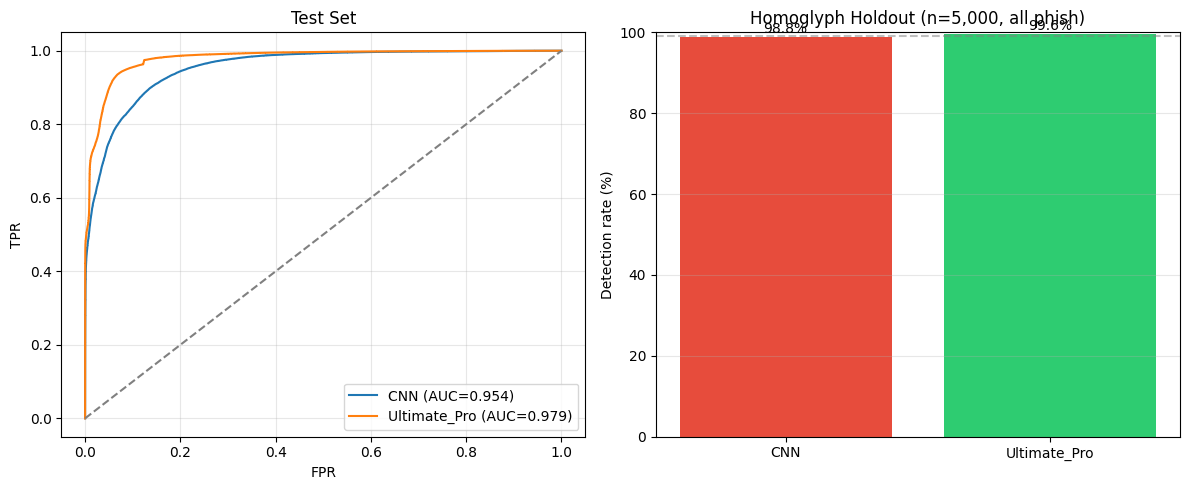

Saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/roc_curves.png
Note: ROC/AUC on homoglyph holdout is undefined (single class); TPR bar chart used instead.


In [25]:
# ══════════════════════════════════════════════════════════════
# CELL 16 — ROC Curves (Ultimate Pro vs CNN Baseline)
# Homoglyph holdout is single-class (all phish) → score histogram, not AUC
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Test set (mixed labels — valid ROC/AUC)
ax = axes[0]
for display_name, (_, use_lex) in [("CNN", MODEL_BUILDERS["CNN"]), ("Ultimate_Pro", MODEL_BUILDERS["Ultimate_Pro"])]:
    m = ensure_model(display_name)
    preds = predict_model(m, test_seq, test_lex, use_lex, chunk=50_000)
    if display_name == "Ultimate_Pro":
        preds = adjust_preds_batch(test_df["url"].values, preds)
    fpr, tpr, _ = roc_curve(test_lbl, preds)
    auc_val = roc_auc_score(test_lbl, preds)
    ax.plot(fpr, tpr, label=f"{display_name} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("Test Set")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Homoglyph holdout (all phish — AUC undefined; show detection rate)
ax = axes[1]
bar_labels, bar_vals = [], []
for display_name, (_, use_lex) in [("CNN", MODEL_BUILDERS["CNN"]), ("Ultimate_Pro", MODEL_BUILDERS["Ultimate_Pro"])]:
    m = ensure_model(display_name)
    preds = predict_model(m, hom_seq, hom_lex, use_lex, chunk=50_000)
    if display_name == "Ultimate_Pro":
        preds = adjust_preds_batch(hom_hold["url"].values, preds)
    tpr = float((preds >= FINAL_THRESHOLD).mean())
    bar_labels.append(display_name)
    bar_vals.append(tpr * 100)
ax.bar(bar_labels, bar_vals, color=["#e74c3c", "#2ecc71"])
ax.set_ylim(0, 100)
ax.set_ylabel("Detection rate (%)")
ax.set_title(f"Homoglyph Holdout (n={len(hom_lbl):,}, all phish)")
ax.axhline(99, color="gray", linestyle="--", alpha=0.5, label="99% reference")
for i, v in enumerate(bar_vals):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_curves.png"), dpi=150)
plt.show()
print(f"Saved: {RESULTS_DIR}/roc_curves.png")
print("Note: ROC/AUC on homoglyph holdout is undefined (single class); TPR bar chart used instead.")


In [26]:
# ══════════════════════════════════════════════════════════════
# CELL 17 — Live URL Prediction (Inference)
# ══════════════════════════════════════════════════════════════

def predict_url(url: str, threshold=FINAL_THRESHOLD) -> dict:
    seq = np.expand_dims(url_to_sequence(url), 0)
    lex = np.expand_dims(extract_lexical_features(url), 0)
    prob = float(best_model.predict({"text_input": seq, "lexical_input": lex}, verbose=0)[0][0])
    prob = adjust_phish_probability(url, prob)
    label = "PHISHING" if prob >= threshold else "SAFE"
    return {"url": url, "probability": prob, "label": label}


demo_urls = [
    ("https://www.google.com", "Safe"),
    ("https://www.gооgle.com", "Homoglyph Phish"),
    ("https://www.paypal-update.net", "Phish"),
    ("https://ru.wikipedia.org/wiki/Москва", "Safe Unicode"),
    ("https://bit.ly/verify-account", "Short Phish"),
]

print(f"Threshold: {FINAL_THRESHOLD:.2f}\n")
for url, expected in demo_urls:
    r = predict_url(url)
    icon = "🔴" if r["label"] == "PHISHING" else "🟢"
    print(f"{icon} [{expected:16s}] prob={r['probability']:.4f} | {url}")

Threshold: 0.47

🟢 [Safe            ] prob=0.0081 | https://www.google.com
🔴 [Homoglyph Phish ] prob=0.9996 | https://www.gооgle.com
🔴 [Phish           ] prob=0.7767 | https://www.paypal-update.net
🟢 [Safe Unicode    ] prob=0.0059 | https://ru.wikipedia.org/wiki/Москва
🔴 [Short Phish     ] prob=0.9998 | https://bit.ly/verify-account


In [27]:
# ══════════════════════════════════════════════════════════════
# CELL 19 — ABLATION: Neural Only vs Full Hybrid (FAST batch version)
# Uses predict_model() in chunks — NOT one predict() per URL (~2-5 min on A100)
# Requires: Cell 6 (encodings), Cell 11 (best_model), Cell 14 (holdout encodings)
# ══════════════════════════════════════════════════════════════
from sklearn.metrics import f1_score, roc_auc_score
import time

if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first (best_model).")

print("=" * 60)
print("ABLATION STUDY — Neural only vs Full hybrid (batch mode)")
print("=" * 60)

t0 = time.time()


def eval_ablation_batch(urls, labels, seq, lex, split_name, mode_name, use_hybrid=False):
    probs = predict_model(best_model, seq, lex, use_lexical=True)
    if use_hybrid:
        probs = adjust_preds_batch(urls, probs)
    preds = (probs >= FINAL_THRESHOLD).astype(int)
    labels = np.asarray(labels).astype(int)
    row = {
        "mode": mode_name,
        "split": split_name,
        "n": len(labels),
        "threshold": FINAL_THRESHOLD,
    }
    if labels.sum() == 0:
        row["fpr"] = round(float(preds.mean()), 4)
        row["accuracy"] = round(float((preds == 0).mean()), 4)
    elif labels.sum() == len(labels):
        row["tpr"] = round(float(preds.mean()), 4)
        row["accuracy"] = round(float((preds == 1).mean()), 4)
    else:
        row["auc"] = round(float(roc_auc_score(labels, probs)), 4)
        row["f1"] = round(float(f1_score(labels, preds, zero_division=0)), 4)
    return row


ABLATION_SETS = [
    ("test", test_df["url"].values, test_df["label"].values, test_seq, test_lex),
    ("homoglyph", hom_hold["url"].values, hom_hold["label"].values, hom_seq, hom_lex),
    ("unicode_safe", uni_hold["url"].values, uni_hold["label"].values, uni_seq, uni_lex),
    ("trusted_safe", trust_hold["url"].values, trust_hold["label"].values, trust_seq, trust_lex),
]

demo_urls_ab = [u for u, _ in demo]
demo_lbl_ab = np.array([l for _, l in demo], dtype=int)

ablation_rows = []
for mode_name, use_hybrid in [("neural_only", False), ("full_hybrid", True)]:
    print(f"\n--- {mode_name} ---")
    for split_name, urls, labels, seq, lex in ABLATION_SETS:
        print(f"  {split_name} ({len(labels):,} URLs)...", flush=True)
        ablation_rows.append(
            eval_ablation_batch(urls, labels, seq, lex, split_name, mode_name, use_hybrid)
        )

    demo_probs = []
    for u in demo_urls_ab:
        p = float(
            best_model.predict(
                {
                    "text_input": np.expand_dims(url_to_sequence(u), 0),
                    "lexical_input": np.expand_dims(extract_lexical_features(u), 0),
                },
                verbose=0,
            )[0][0]
        )
        if use_hybrid:
            p = adjust_phish_probability(u, p)
        demo_probs.append(p)
    demo_preds = (np.array(demo_probs) >= FINAL_THRESHOLD).astype(int)
    demo_ok = int((demo_preds == demo_lbl_ab).sum())
    ablation_rows.append({
        "mode": mode_name,
        "split": "demo_urls",
        "n": len(demo_lbl_ab),
        "threshold": FINAL_THRESHOLD,
        "demo_accuracy": round(demo_ok / len(demo_lbl_ab), 4),
    })

ablation_df = pd.DataFrame(ablation_rows)
print("\n" + ablation_df.to_string(index=False))
out_path = os.path.join(RESULTS_DIR, "ablation_neural_vs_hybrid.csv")
ablation_df.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
print(f"Done in {time.time() - t0:.0f}s — use in thesis Chapter 4 (Ablation).")


ABLATION STUDY — Neural only vs Full hybrid (batch mode)

--- neural_only ---
  test (129,882 URLs)...
  homoglyph (5,000 URLs)...
  unicode_safe (5,000 URLs)...
  trusted_safe (2,500 URLs)...

--- full_hybrid ---
  test (129,882 URLs)...
  homoglyph (5,000 URLs)...
  unicode_safe (5,000 URLs)...
  trusted_safe (2,500 URLs)...

       mode        split      n  threshold    auc     f1    tpr  accuracy    fpr  demo_accuracy
neural_only         test 129882       0.47 0.9797 0.9424    NaN       NaN    NaN            NaN
neural_only    homoglyph   5000       0.47    NaN    NaN 0.9962    0.9962    NaN            NaN
neural_only unicode_safe   5000       0.47    NaN    NaN    NaN    1.0000 0.0000            NaN
neural_only trusted_safe   2500       0.47    NaN    NaN    NaN    0.9772 0.0228            NaN
neural_only    demo_urls      9       0.47    NaN    NaN    NaN       NaN    NaN            1.0
full_hybrid         test 129882       0.47 0.9789 0.9372    NaN       NaN    NaN            Na

In [28]:
# ══════════════════════════════════════════════════════════════
# CELL 20 — Threshold Comparison (0.40 vs 0.49) — supervisor request
# Requires: Cells 6, 11, 12, 14 (encodings + demo list)
# ══════════════════════════════════════════════════════════════
import pandas as pd

if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first.")
if "predict_model" not in globals():
    raise RuntimeError("Run Cell 12 first.")

THRESHOLDS_COMPARE = [0.40, 0.49]
demo_urls_th = [u for u, _ in demo]
demo_lbl_th = np.array([l for _, l in demo], dtype=int)

EVAL_SETS = [
    ("test", test_df["url"].values, test_df["label"].values, test_seq, test_lex),
    ("homoglyph", hom_hold["url"].values, hom_hold["label"].values, hom_seq, hom_lex),
    ("unicode_safe", uni_hold["url"].values, uni_hold["label"].values, uni_seq, uni_lex),
    ("trusted_safe", trust_hold["url"].values, trust_hold["label"].values, trust_seq, trust_lex),
]

hybrid_probs = {}
for split_name, urls, labels, seq, lex in EVAL_SETS:
    raw = predict_model(best_model, seq, lex, use_lexical=True)
    hybrid_probs[split_name] = adjust_preds_batch(urls, raw)

demo_raw = np.array([
    float(best_model.predict({
        "text_input": np.expand_dims(url_to_sequence(u), 0),
        "lexical_input": np.expand_dims(extract_lexical_features(u), 0),
    }, verbose=0)[0][0])
    for u in demo_urls_th
])
demo_hybrid = np.array([adjust_phish_probability(u, p) for u, p in zip(demo_urls_th, demo_raw)])

rows = []
for thresh in THRESHOLDS_COMPARE:
    row = {"threshold": thresh}
    for split_name, urls, labels, seq, lex in EVAL_SETS:
        probs = hybrid_probs[split_name]
        preds = (probs >= thresh).astype(int)
        labels = np.asarray(labels).astype(int)
        if labels.sum() == 0:
            row[f"{split_name}_fpr"] = round(float(preds.mean()), 4)
        elif labels.sum() == len(labels):
            row[f"{split_name}_tpr"] = round(float(preds.mean()), 4)
        else:
            row[f"{split_name}_f1"] = round(float(f1_score(labels, preds, zero_division=0)), 4)
            row[f"{split_name}_auc"] = round(float(roc_auc_score(labels, probs)), 4)
    demo_pred = (demo_hybrid >= thresh).astype(int)
    row["demo_accuracy"] = round(float((demo_pred == demo_lbl_th).mean()), 4)
    row["demo_correct"] = f"{int((demo_pred == demo_lbl_th).sum())}/{len(demo_lbl_th)}"
    rows.append(row)

threshold_df = pd.DataFrame(rows)
print("=" * 60)
print("THRESHOLD COMPARISON (Ultimate_Pro + hybrid post-processing)")
print("=" * 60)
print(threshold_df.to_string(index=False))
print("\nInterpretation:")
print("  tau=0.40 — thesis choice: protects low-score demo typosquats (e.g. appleid ~0.44).")
print("  tau=0.49 — validation-tuned: usually lower trusted FPR; may miss borderline phish.")
out = os.path.join(RESULTS_DIR, "threshold_comparison_040_vs_049.csv")
threshold_df.to_csv(out, index=False)
print(f"\nSaved: {out}")


THRESHOLD COMPARISON (Ultimate_Pro + hybrid post-processing)
 threshold  test_f1  test_auc  homoglyph_tpr  unicode_safe_fpr  trusted_safe_fpr  demo_accuracy demo_correct
      0.40   0.9364    0.9789         0.9964               0.0            0.0320            1.0          9/9
      0.49   0.9372    0.9789         0.9962               0.0            0.0204            1.0          9/9

Interpretation:
  tau=0.40 — thesis choice: protects low-score demo typosquats (e.g. appleid ~0.44).
  tau=0.49 — validation-tuned: usually lower trusted FPR; may miss borderline phish.

Saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/threshold_comparison_040_vs_049.csv


In [29]:
# ══════════════════════════════════════════════════════════════
# CELL 21 — Random Forest Baseline (supervisor request)
# Char TF-IDF + RandomForest on same splits as deep models (~15-30 min)
# Requires: Cells 3, 5, 11, 14 (for holdouts + demo)
# ══════════════════════════════════════════════════════════════
import time
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, f1_score

RF_THRESHOLD = 0.40
MAX_RF_TRAIN = 200_000  # increase to len(train_df) if you have time/RAM

t0 = time.time()
train_rf = train_df[["url", "label"]].copy()
if len(train_rf) > MAX_RF_TRAIN:
    train_rf = train_rf.sample(MAX_RF_TRAIN, random_state=SEED)
    print(f"RF train subsample: {len(train_rf):,} (set MAX_RF_TRAIN higher for full train)")

X_train_txt = [normalize_url(u) for u in train_rf["url"].values]
y_train_rf = train_rf["label"].values.astype(int)

print("Fitting TF-IDF + Random Forest...")
vectorizer = TfidfVectorizer(
    analyzer="char", ngram_range=(3, 5), max_features=20_000, sublinear_tf=True,
)
X_train = vectorizer.fit_transform(X_train_txt)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=28,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train_rf)
print(f"RF trained in {time.time() - t0:.0f}s")


def rf_eval(urls, labels, split_name, threshold=RF_THRESHOLD):
    X = vectorizer.transform([normalize_url(u) for u in urls])
    probs = rf.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    labels = np.asarray(labels).astype(int)
    row = {"model": "RandomForest", "split": split_name, "n": len(labels), "threshold": threshold}
    if len(np.unique(labels)) > 1:
        row["auc"] = round(float(roc_auc_score(labels, probs)), 4)
        row["f1"] = round(float(f1_score(labels, preds, zero_division=0)), 4)
    if labels.sum() == 0:
        row["fpr"] = round(float(preds.mean()), 4)
    elif labels.sum() == len(labels):
        row["tpr"] = round(float(preds.mean()), 4)
    return row


rf_rows = []
rf_rows.append(rf_eval(test_df["url"].values, test_df["label"].values, "test"))
rf_rows.append(rf_eval(hom_hold["url"].values, hom_hold["label"].values, "homoglyph"))
rf_rows.append(rf_eval(uni_hold["url"].values, uni_hold["label"].values, "unicode_safe"))
rf_rows.append(rf_eval(trust_hold["url"].values, trust_hold["label"].values, "trusted_safe"))

demo_urls_rf = [u for u, _ in demo]
demo_lbl_rf = np.array([l for _, l in demo], dtype=int)
X_demo = vectorizer.transform([normalize_url(u) for u in demo_urls_rf])
demo_probs_rf = rf.predict_proba(X_demo)[:, 1]
demo_ok = int(((demo_probs_rf >= RF_THRESHOLD).astype(int) == demo_lbl_rf).sum())
rf_rows.append({
    "model": "RandomForest", "split": "demo_urls", "n": len(demo_lbl_rf),
    "threshold": RF_THRESHOLD, "demo_accuracy": round(demo_ok / len(demo_lbl_rf), 4),
})

rf_df = pd.DataFrame(rf_rows)
print("\n" + "=" * 60)
print("RANDOM FOREST BASELINE (char TF-IDF, no hybrid rules)")
print("=" * 60)
print(rf_df.to_string(index=False))
out = os.path.join(RESULTS_DIR, "random_forest_baseline.csv")
rf_df.to_csv(out, index=False)
print(f"\nSaved: {out}")
print(f"Total time: {time.time() - t0:.0f}s")
print("Compare this table with Ultimate_Pro in model_comparison_thesis.csv for the thesis.")


RF train subsample: 200,000 (set MAX_RF_TRAIN higher for full train)
Fitting TF-IDF + Random Forest...
RF trained in 56s

RANDOM FOREST BASELINE (char TF-IDF, no hybrid rules)
       model        split      n  threshold    auc     f1    tpr    fpr  demo_accuracy
RandomForest         test 129882        0.4 0.8534 0.7633    NaN    NaN            NaN
RandomForest    homoglyph   5000        0.4    NaN    NaN 0.8014    NaN            NaN
RandomForest unicode_safe   5000        0.4    NaN    NaN    NaN 0.2828            NaN
RandomForest trusted_safe   2500        0.4    NaN    NaN    NaN 0.3096            NaN
RandomForest    demo_urls      9        0.4    NaN    NaN    NaN    NaN         0.7778

Saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/random_forest_baseline.csv
Total time: 66s
Compare this table with Ultimate_Pro in model_comparison_thesis.csv for the thesis.


In [30]:
# ══════════════════════════════════════════════════════════════
# CELL 21B — Dictionary / Rule Lookup Baseline (supervisor R08)
# O(N) character scan — no neural network. Compare vs RF (Cell 21) and Ultimate_Pro.
# Requires: Cells 3, 5, 14. Optional: Cell 21 done first (not required).
# ~2 min CPU only — safe to run anytime; writes results_v63/dictionary_lookup_baseline.csv
# ══════════════════════════════════════════════════════════════
import pandas as pd

DICT_THRESHOLD = 0.40

# Common Unicode confusables → Latin (subset used in homoglyph attacks)
CONFUSABLE_MAP = str.maketrans({
    "\u0430": "a", "\u0435": "e", "\u043e": "o", "\u0440": "p", "\u0441": "c",
    "\u0443": "y", "\u0445": "x", "\u0456": "i", "\u04cf": "l", "\u0501": "d",
    "\u051b": "h", "\u0261": "g", "\u03bf": "o", "\u03c1": "p", "\u03bd": "v",
    "\u03b1": "a", "\u03b5": "e", "\u03b9": "i", "\u03ba": "k", "\u03c4": "t",
    "\u1d00": "a", "\u026a": "i", "\u029f": "l", "\u1d1b": "t",
})

ASCII_DEFANG = str.maketrans({"I": "l", "\u0131": "i", "\u0142": "l"})

BRAND_ROOTS = tuple(
    r.split(".")[0] for r in OFFICIAL_SAFE_ROOTS if len(r.split(".")[0]) >= 4
)


def _host_label(url: str) -> str:
    raw = str(url).strip()
    raw = re.sub(r"^https?://", "", raw, flags=re.I)
    raw = re.sub(r"^www\.", "", raw, flags=re.I)
    return raw.split("/")[0].split(".")[0]


def dictionary_phish_prob(url: str) -> float:
    """
    Rule baseline (supervisor dictionary lookup analogue):
      1) Non-ASCII confusable char in host → phish
      2) Mixed scripts in host label → phish
      3) ASCII rn→m / I→l defang matches brand but host is not official → phish
    Else → benign (low score).
    """
    if is_clean_official_url(url):
        return 0.10

    host = get_registrable_host(url)
    label = _host_label(url)

    # (1) Unicode homoglyph chars present
    if any(ord(c) > 127 for c in host):
        return 0.92

    # (2) Mixed scripts after normalization
    scripts = set()
    for c in label:
        if c.isalpha():
            scripts.add("latin" if ord(c) < 128 else "other")
    if len(scripts) > 1:
        return 0.90

    # (3) Defanged ASCII brand spoof (rn→m, I→l)
    defanged = label.translate(ASCII_DEFANG).lower()
    canonical = label.translate(CONFUSABLE_MAP).lower()
    for brand in BRAND_ROOTS:
        for form in (defanged, canonical):
            if form == brand and host != f"{brand}.com" and not host.endswith(f".{brand}.com"):
                if not is_clean_official_url(url):
                    return 0.88

    # Typosquat keyword pattern (minimal rule — not full hybrid)
    if TYPO_BRAND_HOST.search(host) or TYPO_BRAND_HOST.search(normalize_url(url)):
        return 0.75

    return 0.12


def dict_eval(urls, labels, split_name, threshold=DICT_THRESHOLD):
    probs = np.array([dictionary_phish_prob(u) for u in urls], dtype=float)
    preds = (probs >= threshold).astype(int)
    labels = np.asarray(labels).astype(int)
    row = {"model": "DictionaryLookup", "split": split_name, "n": len(labels), "threshold": threshold}
    if len(np.unique(labels)) > 1:
        row["auc"] = round(float(roc_auc_score(labels, probs)), 4)
        row["f1"] = round(float(f1_score(labels, preds, zero_division=0)), 4)
    if labels.sum() == 0:
        row["fpr"] = round(float(preds.mean()), 4)
    elif labels.sum() == len(labels):
        row["tpr"] = round(float(preds.mean()), 4)
    return row


dict_rows = []
dict_rows.append(dict_eval(test_df["url"].values, test_df["label"].values, "test"))
dict_rows.append(dict_eval(hom_hold["url"].values, hom_hold["label"].values, "homoglyph"))
dict_rows.append(dict_eval(uni_hold["url"].values, uni_hold["label"].values, "unicode_safe"))
dict_rows.append(dict_eval(trust_hold["url"].values, trust_hold["label"].values, "trusted_safe"))

if "ascii_hold" in dir() and ascii_hold is not None and len(ascii_hold):
    dict_rows.append(dict_eval(ascii_hold["url"].values, ascii_hold["label"].values, "ascii_visual"))

demo_urls_d = [u for u, _ in demo]
demo_lbl_d = np.array([l for _, l in demo], dtype=int)
demo_probs_d = np.array([dictionary_phish_prob(u) for u in demo_urls_d])
demo_ok = int(((demo_probs_d >= DICT_THRESHOLD).astype(int) == demo_lbl_d).sum())
dict_rows.append({
    "model": "DictionaryLookup", "split": "demo_urls", "n": len(demo_lbl_d),
    "threshold": DICT_THRESHOLD, "demo_accuracy": round(demo_ok / len(demo_lbl_d), 4),
})

# Spot probes (thesis examples)
for probe in ["https://rnicrosoft.com", "https://www.gооgle.com", "https://www.google.com"]:
    p = dictionary_phish_prob(probe)
    print(f"  probe {probe[:45]:45s} -> {p:.2f} ({'PHISH' if p >= DICT_THRESHOLD else 'safe'})")

dict_df = pd.DataFrame(dict_rows)
print("\n" + "=" * 60)
print("DICTIONARY / RULE LOOKUP BASELINE (supervisor R08)")
print("=" * 60)
print(dict_df.to_string(index=False))
out_dict = os.path.join(RESULTS_DIR, "dictionary_lookup_baseline.csv")
dict_df.to_csv(out_dict, index=False)
print(f"\nSaved: {out_dict}")
print("Thesis note: high homoglyph TPR but high unicode/trusted FPR shows why DL generalizes better.")


  probe https://rnicrosoft.com                        -> 0.12 (safe)
  probe https://www.gооgle.com                        -> 0.92 (PHISH)
  probe https://www.google.com                        -> 0.10 (safe)

DICTIONARY / RULE LOOKUP BASELINE (supervisor R08)
           model        split      n  threshold    auc     f1  tpr    fpr  demo_accuracy
DictionaryLookup         test 129882        0.4 0.5873 0.3565  NaN    NaN            NaN
DictionaryLookup    homoglyph   5000        0.4    NaN    NaN  1.0    NaN            NaN
DictionaryLookup unicode_safe   5000        0.4    NaN    NaN  NaN 0.3772            NaN
DictionaryLookup trusted_safe   2500        0.4    NaN    NaN  NaN 0.0224            NaN
DictionaryLookup ascii_visual    500        0.4 0.5060 0.0237  NaN    NaN            NaN
DictionaryLookup    demo_urls      9        0.4    NaN    NaN  NaN    NaN         0.7778

Saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/dictionary_lookup_baseline.csv

In [31]:
# ══════════════════════════════════════════════════════════════
# CELL 22 — Thesis fixes: 100 demo URLs + component ablation + FPR<2% sweep
# Requires: Cells 5, 11, 12, 14. Upload vaccines/thesis_demo_urls_100.csv to Drive
#           or place in BASE folder. ~5-15 min on GPU.
# ══════════════════════════════════════════════════════════════
import pandas as pd
from sklearn.metrics import f1_score

if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first.")

import numpy as np
import re

if "FINAL_THRESHOLD" not in globals():
    FINAL_THRESHOLD = 0.50

if "predict_model" not in globals():
    def predict_model(model, seq, lex, use_lexical, chunk=50_000):
        preds = []
        n = len(seq)
        for start in range(0, n, chunk):
            end = min(start + chunk, n)
            if use_lexical:
                p = model.predict(
                    {"text_input": seq[start:end], "lexical_input": lex[start:end]},
                    verbose=0,
                ).flatten()
            else:
                p = model.predict(seq[start:end], verbose=0).flatten()
            preds.append(p)
        return np.concatenate(preds)
    print("AUTO: predict_model (Cell 12 bootstrap)")

if "batch_encode_sequences" not in globals():
    if "MAX_LENGTH" not in globals():
        MAX_LENGTH = 256
    if "VOCAB_SIZE" not in globals():
        VOCAB_SIZE = 65536
    if "normalize_url" not in globals():
        def normalize_url(url):
            u = str(url).strip().lower()
            u = re.sub(r"^https?://", "", u)
            u = re.sub(r"^www\.", "", u)
            return u
    if "extract_lexical_features" not in globals():
        def extract_lexical_features(url):
            u = normalize_url(url)
            suspicious = ["login", "secure", "update", "verify", "account", "banking", "support", "free", "bank", "alert"]
            return np.array([
                len(u), u.count("."), u.count("-"), u.count("@"), u.count("//"),
                1 if re.search(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", u) else 0,
                1 if any(w in u for w in suspicious) else 0,
            ], dtype=np.float32)
    def batch_encode_sequences(urls, chunk_size=100_000):
        n = len(urls)
        result = np.zeros((n, MAX_LENGTH), dtype=np.uint16)
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            for i, url in enumerate(urls[start:end]):
                codes = [min(ord(c), VOCAB_SIZE - 1) for c in normalize_url(url)[:MAX_LENGTH]]
                result[start + i, : len(codes)] = codes
        return result
    def batch_encode_lexical(urls, chunk_size=100_000):
        n = len(urls)
        result = np.zeros((n, 7), dtype=np.float32)
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            for i, url in enumerate(urls[start:end]):
                result[start + i] = extract_lexical_features(url)
        return result
    print("AUTO: batch_encode_* (Cell 5 bootstrap)")

if "adjust_phish_probability" not in globals():
    if "get_registrable_host" not in globals():
        def get_registrable_host(url):
            host = normalize_url(url).split("/")[0]
            return host[4:] if host.startswith("www.") else host
    if "is_clean_official_url" not in globals():
        _OFFICIAL = ("google.com", "paypal.com", "microsoft.com", "apple.com", "amazon.com", "bbc.com", "wikipedia.org")
        _PHISH_KW = re.compile(r"(login|verify|secure|update|account|banking|signin)", re.I)
        def is_clean_official_url(url):
            host = get_registrable_host(url)
            if not any(host == r or host.endswith("." + r) for r in _OFFICIAL):
                return False
            return not _PHISH_KW.search(normalize_url(url)[len(host):])
    if "TYPO_BRAND_HOST" not in globals():
        TYPO_BRAND_HOST = re.compile(
            r"(paypal|google|apple|microsoft|amazon|facebook|netflix|twitter|linkedin|instagram|github)"
            r"[.-](security|update|login|verify|secure)", re.I)
    def adjust_phish_probability(url, prob):
        if is_clean_official_url(url):
            return min(float(prob), 0.20)
        u = normalize_url(url)
        host = get_registrable_host(url)
        if TYPO_BRAND_HOST.search(u) or TYPO_BRAND_HOST.search(host):
            if not is_clean_official_url(url):
                return max(float(prob), 0.60)
        if "paypal-update" in u or "paypal-security" in u:
            return max(float(prob), 0.60)
        return float(prob)
    def adjust_preds_batch(urls, preds):
        out = np.asarray(preds, dtype=float).copy()
        for i, url in enumerate(urls):
            out[i] = adjust_phish_probability(str(url), float(out[i]))
        return out
    print("AUTO: hybrid adjust (Cell 5 bootstrap)")

if "trust_seq" not in globals() and "trust_hold" in globals():
    trust_urls = trust_hold["url"].astype(str).values
    trust_seq = batch_encode_sequences(trust_urls)
    trust_lex = batch_encode_lexical(trust_urls)
    print("AUTO: trust_seq/trust_lex for sweep")


# --- Load 100-url curated benchmark (auto-find / auto-create for Colab) ---
import shutil
from io import StringIO
from pathlib import Path

_DEMO100_BUILTIN = 'url,label,category\nhttps://www.google.com,0,trusted_safe\nhttps://www.bbc.com/news,0,trusted_safe\nhttps://www.paypal.com,0,trusted_safe\nhttps://www.microsoft.com,0,trusted_safe\nhttps://www.apple.com,0,trusted_safe\nhttps://www.amazon.com,0,trusted_safe\nhttps://github.com,0,trusted_safe\nhttps://stackoverflow.com,0,trusted_safe\nhttps://www.youtube.com,0,trusted_safe\nhttps://www.wikipedia.org,0,trusted_safe\nhttps://www.reddit.com,0,trusted_safe\nhttps://www.linkedin.com,0,trusted_safe\nhttps://www.cnn.com,0,trusted_safe\nhttps://www.spotify.com,0,trusted_safe\nhttps://www.ebay.com,0,trusted_safe\nhttps://ru.wikipedia.org/wiki/Москва,0,unicode_safe\nhttps://ar.wikipedia.org/wiki/العربية,0,unicode_safe\nhttps://fa.wikipedia.org/wiki/ایران,0,unicode_safe\nhttps://zh.wikipedia.org/wiki/中文,0,unicode_safe\nhttps://ja.wikipedia.org/wiki/日本,0,unicode_safe\nhttps://de.wikipedia.org/wiki/Deutschland,0,unicode_safe\nhttps://fr.wikipedia.org/wiki/France,0,unicode_safe\nhttps://es.wikipedia.org/wiki/España,0,unicode_safe\nhttps://tr.wikipedia.org/wiki/Türkiye,0,unicode_safe\nhttps://uk.wikipedia.org/wiki/Україна,0,unicode_safe\nhttps://he.wikipedia.org/wiki/ישראל,0,unicode_safe\nhttps://el.wikipedia.org/wiki/Ελλάδα,0,unicode_safe\nhttps://paypal-security-verification.xyz,1,typosquat\nhttps://www.paypal-update.net,1,typosquat\nhttps://www.paypal-security-verify.top,1,typosquat\nhttps://microsoft-security-verification.xyz,1,typosquat\nhttps://www.apple-update.net,1,typosquat\nhttps://amazon-security-verification.online,1,typosquat\nhttps://google-security-verify.xyz,1,typosquat\nhttps://facebook-login-secure.site,1,typosquat\nhttp://appleid-apple.com.verify-account.net,1,typosquat\nhttps://secure-paypal-login.xyz,1,typosquat\nhttps://www.netflix-update.com,1,typosquat\nhttps://instagram-verify-account.top,1,typosquat\nhttps://www.linkedin-security-verify.net,1,typosquat\nhttps://paypal-update.net/verify,1,typosquat\nhttps://www.microsoft-update.shop,1,typosquat\nhttps://appleid-apple.com.verify-account.org,1,typosquat\nhttps://www.google-update.online,1,typosquat\nhttps://amazon-account-verification.xyz,1,typosquat\nhttps://www.paypal-login-secure.net,1,typosquat\nhttps://microsoft-update-verify.top,1,typosquat\nhttps://apple-security-verification.xyz,1,typosquat\nhttps://www.facebook-update.net,1,typosquat\nhttps://netflix-security-verify.shop,1,typosquat\nhttps://www.gооgle.com,1,homoglyph\nhttps://www.googIe.com,1,homoglyph\nhttps://www.micrоsoft.com,1,homoglyph\nhttps://www.paypaI.com,1,homoglyph\nhttps://www.appIe.com,1,homoglyph\nhttps://www.amazоn.com,1,homoglyph\nhttps://www.facebоok.com,1,homoglyph\nhttps://www.gооgle.com/login,1,homoglyph\nhttps://micrоsoft.com/verify,1,homoglyph\nhttps://www.gооgle.com/search,1,homoglyph\nhttps://www.аpple.com,1,homoglyph\nhttps://www.goоgle.com/signin,1,homoglyph\nhttps://www.micrоsoft.com/login,1,homoglyph\nhttps://www.paypаl.com,1,homoglyph\nhttps://www.gооgle.com/account,1,homoglyph\nhttps://bit.ly/verify-account,1,shortener\nhttps://bit.ly/secure-login-bank,1,shortener\nhttps://tinyurl.com/paypal-update,1,shortener\nhttps://goo.gl/account-verify,1,shortener\nhttps://t.co/secure-banking,1,shortener\nhttps://bit.ly/microsoft-login,1,shortener\nhttps://cutt.ly/apple-verify,1,shortener\nhttps://rebrand.ly/paypal-secure,1,shortener\nhttps://bit.ly/update-password,1,shortener\nhttps://tiny.cc/bank-alert,1,shortener\nhttps://bit.ly/apple-id-verify,1,shortener\nhttps://ow.ly/bank-secure,1,shortener\nhttps://is.gd/paypal-login,1,shortener\nhttp://192.168.0.1/login,1,general_phish\nhttp://10.0.0.1/admin,1,general_phish\nhttps://free-gift-cards.xyz,1,general_phish\nhttps://login-secure-banking.tk,1,general_phish\nhttps://verify-account-now.ml,1,general_phish\nhttps://account-suspended-alert.ga,1,general_phish\nhttps://secure-update-required.cf,1,general_phish\nhttps://confirm-identity-now.top,1,general_phish\nhttps://banking-login-portal.shop,1,general_phish\nhttps://wallet-connect-verify.online,1,general_phish\nhttps://crypto-airdrop-claim.xyz,1,general_phish\nhttps://tax-refund-portal.ml,1,general_phish\nhttps://dhl-package-reschedule.tk,1,general_phish\nhttps://invoice-payment-due.ga,1,general_phish\nhttps://office365-password-expired.top,1,general_phish\nhttps://icloud-storage-full.shop,1,general_phish\nhttps://whatsapp-premium-verify.online,1,general_phish\nhttps://telegram-login-security.xyz,1,general_phish\nhttps://steam-community-trade.tk,1,general_phish\nhttps://netflix-billing-update.ml,1,general_phish\npaypal-security-verify.xyz,1,typosquat_extra\npaypal-account-verification.xyz,1,typosquat_extra\n'

def load_demo100_csv():
    root_ds = Path(BASE).parent
    dest = Path(BASE) / "thesis_demo_urls_100.csv"
    candidates = [
        dest,
        root_ds / "vaccines" / "thesis_demo_urls_100.csv",
        root_ds / "output_v6" / "thesis_demo_urls_100.csv",
        root_ds / "output_v5" / "thesis_demo_urls_100.csv",
        root_ds / "output_v4" / "thesis_demo_urls_100.csv",
        Path(DRIVE_ROOT) / "All_Models" / "Balanced_Thesis_Dataset_2026" / "vaccines" / "thesis_demo_urls_100.csv",
        Path(DRIVE_ROOT) / "All_Models" / "Balanced_Thesis_Dataset_2026" / "output_v6" / "thesis_demo_urls_100.csv",
        Path(DRIVE_ROOT) / "All_Models" / "Balanced_Thesis_Dataset_2026" / "output_v5" / "thesis_demo_urls_100.csv",
    ]
    for p in candidates:
        p = Path(p)
        if p.is_file():
            if p.resolve() != dest.resolve():
                dest.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(p, dest)
                print(f"Copied demo100 -> {dest}")
            df = pd.read_csv(p)
            print(f"Loaded demo100: {p} ({len(df)} rows)")
            return df
    print("demo100 not on Drive — using built-in 100 URL benchmark")
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(_DEMO100_BUILTIN, encoding="utf-8")
    return pd.read_csv(StringIO(_DEMO100_BUILTIN))

demo100_df = load_demo100_csv()

demo100_urls = demo100_df["url"].astype(str).values
demo100_lbl = demo100_df["label"].values.astype(int)
demo100_cat = demo100_df["category"].astype(str).values if "category" in demo100_df.columns else ["all"] * len(demo100_df)

# --- Component ablation helpers (split hybrid rules) ---
def adjust_official_guard_only(url: str, prob: float) -> float:
    if is_clean_official_url(url):
        return min(prob, 0.20)
    return prob

def adjust_typosquat_boost_only(url: str, prob: float) -> float:
    u = normalize_url(url)
    host = get_registrable_host(url)
    if TYPO_BRAND_HOST.search(u) or TYPO_BRAND_HOST.search(host):
        if not is_clean_official_url(url):
            return max(prob, 0.60)
    if "paypal-update" in u or "paypal-security" in u:
        return max(prob, 0.60)
    return prob

def apply_adjust_batch(urls, preds, mode: str):
    out = np.asarray(preds, dtype=float).copy()
    for i, url in enumerate(urls):
        p = float(out[i])
        if mode == "neural_only":
            pass
        elif mode == "official_guard":
            p = adjust_official_guard_only(url, p)
        elif mode == "typosquat_boost":
            p = adjust_typosquat_boost_only(url, p)
        elif mode == "full_hybrid":
            p = adjust_phish_probability(url, p)
        else:
            raise ValueError(mode)
        out[i] = p
    return out

def raw_probs_urls(urls):
    seq = batch_encode_sequences(urls)
    lex = batch_encode_lexical(urls)
    return predict_model(best_model, seq, lex, use_lexical=True)

def eval_mode_urls(urls, labels, mode, threshold=FINAL_THRESHOLD):
    raw = raw_probs_urls(urls)
    probs = apply_adjust_batch(urls, raw, mode)
    preds = (probs >= threshold).astype(int)
    labels = np.asarray(labels).astype(int)
    acc = float((preds == labels).mean())
    row = {"mode": mode, "n": len(labels), "threshold": threshold, "accuracy": round(acc, 4)}
    if labels.sum() == 0:
        row["fpr"] = round(float(preds.mean()), 4)
    elif labels.sum() == len(labels):
        row["tpr"] = round(float(preds.mean()), 4)
    return row

# --- 1) Extended demo benchmark (100 URLs) ---
print("=" * 60)
print("100-URL DEMO BENCHMARK (component ablation)")
print("=" * 60)
modes = ["neural_only", "official_guard", "typosquat_boost", "full_hybrid"]
demo100_rows = [eval_mode_urls(demo100_urls, demo100_lbl, m) for m in modes]
demo100_summary = pd.DataFrame(demo100_rows)
print(demo100_summary.to_string(index=False))

# Per-category breakdown (full_hybrid vs neural_only)
raw100 = raw_probs_urls(demo100_urls)
for mode in ["neural_only", "full_hybrid"]:
    probs = apply_adjust_batch(demo100_urls, raw100, mode)
    preds = (probs >= FINAL_THRESHOLD).astype(int)
    print(f"\n--- {mode} by category (threshold={FINAL_THRESHOLD}) ---")
    for cat in sorted(set(demo100_cat)):
        mask = demo100_cat == cat
        ok = (preds[mask] == demo100_lbl[mask]).mean()
        print(f"  {cat:18s}  {ok*100:5.1f}%  ({mask.sum()} URLs)")

# --- 2) Trusted FPR threshold sweep (hybrid) ---
print("\n" + "=" * 60)
print("TRUSTED HOLDOUT — threshold sweep (full hybrid)")
print("=" * 60)
trust_urls = trust_hold["url"].values
trust_raw = predict_model(best_model, trust_seq, trust_lex, use_lexical=True)
trust_hybrid = adjust_preds_batch(trust_urls, trust_raw)

sweep_rows = []
for t in np.arange(0.38, 0.52, 0.01):
    fpr = float((trust_hybrid >= t).mean())
    demo_probs = apply_adjust_batch(demo100_urls, raw100, "full_hybrid")
    demo_acc = float(((demo_probs >= t).astype(int) == demo100_lbl).mean())
    sweep_rows.append({
        "threshold": round(t, 2),
        "trusted_fpr": round(fpr, 4),
        "demo100_accuracy": round(demo_acc, 4),
        "fpr_under_2pct": fpr < 0.02,
    })
sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df[sweep_df["fpr_under_2pct"]].head(10).to_string(index=False))
best_under2 = sweep_df[sweep_df["fpr_under_2pct"]].sort_values("demo100_accuracy", ascending=False)
if len(best_under2):
    rec = best_under2.iloc[0]
    print(f"\nRecommended (FPR<2% + max demo100 acc): threshold={rec['threshold']:.2f}")
    print(f"  trusted FPR={rec['trusted_fpr']*100:.2f}% | demo100 acc={rec['demo100_accuracy']*100:.2f}%")
else:
    print("\nNo threshold in sweep achieved FPR<2% with current hybrid — report 0.49 from Cell 20.")

# --- 3) Component ablation on trusted holdout ---
print("\n" + "=" * 60)
print("COMPONENT ABLATION — trusted holdout (2,500 URLs)")
print("=" * 60)
comp_rows = []
for mode in modes:
    probs = apply_adjust_batch(trust_urls, trust_raw, mode)
    preds = (probs >= FINAL_THRESHOLD).astype(int)
    comp_rows.append({
        "mode": mode,
        "trusted_fpr": round(float(preds.mean()), 4),
        "threshold": FINAL_THRESHOLD,
    })
comp_df = pd.DataFrame(comp_rows)
print(comp_df.to_string(index=False))

# Save all
for name, df in [
    ("demo100_component_ablation.csv", demo100_summary),
    ("trusted_threshold_sweep.csv", sweep_df),
    ("trusted_component_ablation.csv", comp_df),
]:
    path = os.path.join(RESULTS_DIR, name)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")
print("\nUse these tables in thesis: stronger demo N=100 + rule-level ablation + FPR<2% threshold choice.")


Loaded demo100: /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/output_v6/thesis_demo_urls_100.csv (100 rows)
100-URL DEMO BENCHMARK (component ablation)
  sequences 100/100
  lexical   100/100
  sequences 100/100
  lexical   100/100
  sequences 100/100
  lexical   100/100
  sequences 100/100
  lexical   100/100
           mode   n  threshold  accuracy
    neural_only 100       0.47      0.87
 official_guard 100       0.47      0.87
typosquat_boost 100       0.47      0.88
    full_hybrid 100       0.47      0.88
  sequences 100/100
  lexical   100/100

--- neural_only by category (threshold=0.46999999999999986) ---
  general_phish        60.0%  (20 URLs)
  homoglyph            80.0%  (15 URLs)
  shortener            92.3%  (13 URLs)
  trusted_safe        100.0%  (15 URLs)
  typosquat            95.7%  (23 URLs)
  typosquat_extra     100.0%  (2 URLs)
  unicode_safe        100.0%  (12 URLs)

--- full_hybrid by category (threshold=0.46999999999999986) ---
  gene

In [32]:
# ══════════════════════════════════════════════════════════════
# CELL 23 — Threshold policy + FP analysis + homoglyph ablation + McNemar
# Requires: Cells 5, 11, 12, 14. Optional: Cell 22 (demo100)
# ══════════════════════════════════════════════════════════════
import pandas as pd
from scipy.stats import binomtest

if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first.")

if "adjust_official_guard_only" not in globals():
    def adjust_official_guard_only(url, prob):
        return min(prob, 0.20) if is_clean_official_url(url) else prob
    def adjust_typosquat_boost_only(url, prob):
        u, host = normalize_url(url), get_registrable_host(url)
        if (TYPO_BRAND_HOST.search(u) or TYPO_BRAND_HOST.search(host)) and not is_clean_official_url(url):
            return max(prob, 0.60)
        if "paypal-update" in u or "paypal-security" in u:
            return max(prob, 0.60)
        return prob
    def apply_adjust_batch(urls, preds, mode):
        out = np.asarray(preds, dtype=float).copy()
        for i, url in enumerate(urls):
            p = float(out[i])
            if mode == "official_guard":
                p = adjust_official_guard_only(url, p)
            elif mode == "typosquat_boost":
                p = adjust_typosquat_boost_only(url, p)
            elif mode == "full_hybrid":
                p = adjust_phish_probability(url, p)
            out[i] = p
        return out

trust_urls = trust_hold["url"].values
trust_raw = predict_model(best_model, trust_seq, trust_lex, use_lexical=True)
trust_hybrid = adjust_preds_batch(trust_urls, trust_raw)

# demo100 or fallback 9 URLs
if "demo100_df" not in globals():
    demo100_df = load_demo100_csv() if "load_demo100_csv" in globals() else pd.read_csv(os.path.join(BASE, "thesis_demo_urls_100.csv"))
d100_u = demo100_df["url"].astype(str).values
d100_l = demo100_df["label"].values.astype(int)
d100_raw = predict_model(best_model, batch_encode_sequences(d100_u), batch_encode_lexical(d100_u), True)

# --- A) THRESHOLD POLICY ---
print("=" * 60)
print("A) THRESHOLD POLICY")
print("=" * 60)
policy_rows = []
for t in [0.40, 0.42, 0.45, 0.49]:
    trust_fpr = float((trust_hybrid >= t).mean())
    dh = apply_adjust_batch(d100_u, d100_raw, "full_hybrid")
    demo_acc = float(((dh >= t).astype(int) == d100_l).mean())
    policy_rows.append({
        "threshold": t,
        "trusted_fpr_pct": round(trust_fpr * 100, 2),
        "trusted_fp_count": int((trust_hybrid >= t).sum()),
        "demo_accuracy_pct": round(demo_acc * 100, 2),
        "demo_correct": f"{int(((dh >= t).astype(int) == d100_l).sum())}/{len(d100_l)}",
        "fpr_under_2pct": trust_fpr < 0.02,
    })
policy_df = pd.DataFrame(policy_rows)
print(policy_df.to_string(index=False))

# --- D) TRUSTED FALSE POSITIVES (criticism #7) ---
print("\n" + "=" * 60)
print(f"D) TRUSTED HOLDOUT FALSE POSITIVES (threshold={FINAL_THRESHOLD})")
print("=" * 60)
fp_mask = trust_hybrid >= FINAL_THRESHOLD
fp_df = trust_hold.iloc[np.where(fp_mask)[0]].copy()
fp_probs = trust_hybrid[fp_mask]
fp_df["probability"] = fp_probs
fp_df["domain"] = fp_df["url"].astype(str).map(get_registrable_host)
fp_df = fp_df.sort_values("probability", ascending=False)
print(f"Total false positives: {len(fp_df)} / {len(trust_hold)} ({len(fp_df)/len(trust_hold)*100:.2f}%)")
print("\nTop 15 false positives:")
cols = [c for c in ["url", "domain", "probability", "category", "source"] if c in fp_df.columns]
print(fp_df[cols].head(15).to_string(index=False))
if len(fp_df):
    print("\nFalse positives by domain (top 10):")
    print(fp_df["domain"].value_counts().head(10).to_string())

# --- B) NEURAL vs HYBRID failures on demo ---
print("\n" + "=" * 60)
print("B) DEMO — neural vs hybrid differences")
print("=" * 60)
fail_rows = []
for i, (url, lbl) in enumerate(zip(d100_u, d100_l)):
    p_raw, p_hyb = float(d100_raw[i]), adjust_phish_probability(url, float(d100_raw[i]))
    pr, ph = int(p_raw >= FINAL_THRESHOLD), int(p_hyb >= FINAL_THRESHOLD)
    if pr != lbl or ph != lbl or abs(p_raw - p_hyb) > 0.05:
        fail_rows.append({
            "url": str(url)[:90], "true_label": int(lbl),
            "neural_prob": round(p_raw, 4), "hybrid_prob": round(p_hyb, 4),
            "neural_correct": pr == lbl, "hybrid_correct": ph == lbl,
        })
fail_df = pd.DataFrame(fail_rows)
print(f"Changed or wrong URLs: {len(fail_df)}")
if len(fail_df):
    print(fail_df.to_string(index=False))

# --- C) HOMOGLYPH component ablation ---
print("\n" + "=" * 60)
print("C) HOMOGLYPH component ablation")
print("=" * 60)
hom_raw = predict_model(best_model, hom_seq, hom_lex, use_lexical=True)
hom_rows = []
for mode in ["neural_only", "official_guard", "typosquat_boost", "full_hybrid"]:
    probs = hom_raw if mode == "neural_only" else apply_adjust_batch(hom_hold["url"].values, hom_raw, mode)
    hom_rows.append({
        "mode": mode,
        "homoglyph_tpr_pct": round(float((probs >= FINAL_THRESHOLD).mean()) * 100, 2),
    })
hom_comp_df = pd.DataFrame(hom_rows)
print(hom_comp_df.to_string(index=False))


# --- F) ASCII visual holdout (v4) ---
if "ascii_hold" in dir() and ascii_hold is not None and len(ascii_hold):
    print("\n" + "=" * 60)
    print("F) ASCII VISUAL holdout (Ultimate_Pro + hybrid)")
    print("=" * 60)
    asc_seq = batch_encode_sequences(ascii_hold["url"].astype(str).values)
    asc_lex = batch_encode_lexical(ascii_hold["url"].astype(str).values)
    asc_lbl = ascii_hold["label"].values.astype(int)
    asc_raw = predict_model(best_model, asc_seq, asc_lex, use_lexical=True)
    for mode in ["neural_only", "full_hybrid"]:
        probs = asc_raw if mode == "neural_only" else apply_adjust_batch(
            ascii_hold["url"].astype(str).values, asc_raw, mode
        )
        pred = (probs >= FINAL_THRESHOLD).astype(int)
        if (asc_lbl == 1).all():
            tpr = float(pred.mean())
            print(f"  {mode}: TPR={tpr*100:.2f}% (n={len(asc_lbl)}, all phish)")
        else:
            acc = float((pred == asc_lbl).mean())
            print(f"  {mode}: accuracy={acc*100:.2f}% (n={len(asc_lbl)})")
    # Spot-check rnicrosoft
    for probe in ["https://rnicrosoft.com", "https://rnicrosft.com"]:
        p = float(adjust_phish_probability(probe, predict_model(
            best_model,
            batch_encode_sequences([probe]),
            batch_encode_lexical([probe]),
            True,
        )[0]))
        print(f"  probe {probe} -> {p:.4f} ({'PHISH' if p >= FINAL_THRESHOLD else 'safe'})")

# --- E) McNemar: Ultimate_Pro vs Hybrid on test (subsample for speed) ---
print("\n" + "=" * 60)
print("E) McNemar test — Ultimate_Pro vs Hybrid (test subsample n=5000)")
print("=" * 60)
n_mcn = min(5000, len(test_lbl))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(test_lbl), n_mcn, replace=False)
sub_lbl = test_lbl[idx].astype(int)

up = ensure_model("Ultimate_Pro")
hy = ensure_model("Hybrid")
p_up = predict_model(up, test_seq[idx], test_lex[idx], True)
p_hy = predict_model(hy, test_seq[idx], test_lex[idx], False)
p_up = adjust_preds_batch(test_df["url"].values[idx], p_up)
pred_up = (p_up >= FINAL_THRESHOLD).astype(int)
pred_hy = (p_hy >= FINAL_THRESHOLD).astype(int)

up_only = (pred_up == sub_lbl) & (pred_hy != sub_lbl)
hy_only = (pred_up != sub_lbl) & (pred_hy == sub_lbl)
b, c = int(up_only.sum()), int(hy_only.sum())
print(f"  Ultimate correct / Hybrid wrong: {b}")
print(f"  Ultimate wrong / Hybrid correct: {c}")
if b + c > 0:
    p_mcn = binomtest(min(b, c), b + c, 0.5, alternative="two-sided").pvalue
    print(f"  McNemar p-value (discordant pairs): {p_mcn:.4f}")
    print("  Thesis wording: differences are not statistically significant at alpha=0.05"
          if p_mcn > 0.05 else "  Significant discordant pairs found — report counts in thesis")
else:
    p_mcn = 1.0
    print("  Identical predictions on subsample — no McNemar needed")

mcnemar_row = {"n": n_mcn, "ultimate_better": b, "hybrid_better": c,
               "p_value": round(p_mcn, 4) if b + c > 0 else 1.0}

# Save
for name, df in [
    ("thesis_threshold_policy.csv", policy_df),
    ("thesis_trusted_false_positives.csv", fp_df[cols + ["probability"]] if len(fp_df) else fp_df),
    ("thesis_neural_hybrid_failures.csv", fail_df),
    ("thesis_homoglyph_component_ablation.csv", hom_comp_df),
    ("thesis_mcnemar_ultimate_vs_hybrid.csv", pd.DataFrame([mcnemar_row])),
]:
    path = os.path.join(RESULTS_DIR, name)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


  sequences 100/100
  lexical   100/100
A) THRESHOLD POLICY
 threshold  trusted_fpr_pct  trusted_fp_count  demo_accuracy_pct demo_correct  fpr_under_2pct
      0.40             3.20                80               89.0       89/100           False
      0.42             2.92                73               89.0       89/100           False
      0.45             2.52                63               88.0       88/100           False
      0.49             2.04                51               88.0       88/100           False

D) TRUSTED HOLDOUT FALSE POSITIVES (threshold=0.46999999999999986)
Total false positives: 55 / 2500 (2.20%)

Top 15 false positives:
                          url               domain  probability     category                   source
 https://www.google.com/login           google.com     0.959849 trusted_safe trusted_safe_vaccine.csv
  https://tracookiepixel.xyz/   tracookiepixel.xyz     0.948903 trusted_safe trusted_safe_vaccine.csv
https://fitgirl-repacks.site/ 

In [33]:
# ══════════════════════════════════════════════════════════════
# CELL 24 — XAI: Unicode scan + attention heatmaps (Ultimate_Pro)
# Requires: Cells 5, 8, 11. No retrain. ~3-5 min.
# Jain & Wallace (2019): attention is illustrative, NOT a faithful proof.
# Outputs: results_v63/thesis_xai_report.csv + thesis_xai_*.png
# ══════════════════════════════════════════════════════════════
import unicodedata
import matplotlib.pyplot as plt
import pandas as pd

if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first.")

CONFUSABLE_TO_ASCII = {
    "\u0430": "a", "\u0435": "e", "\u043e": "o", "\u0440": "p", "\u0441": "c",
    "\u0443": "y", "\u0445": "x", "\u0456": "i", "\u04cf": "l",
}
ASCII_DEFANG = str.maketrans({"I": "l", "\u0131": "i", "\u0142": "l"})

BRAND_ROOTS_XAI = tuple(
    r.split(".")[0] for r in OFFICIAL_SAFE_ROOTS if len(r.split(".")[0]) >= 4
)


def _host_label_raw(url: str) -> str:
    u = str(url).strip()
    u = re.sub(r"^https?://", "", u, flags=re.I)
    u = re.sub(r"^www\.", "", u, flags=re.I)
    return u.split("/")[0].split(".")[0]


def _seq_chars(url: str) -> list:
    u = normalize_url(url)[:MAX_LENGTH]
    return list(u)


def unicode_findings(url: str) -> list:
    label = _host_label_raw(url)
    out = []
    for i, ch in enumerate(label):
        if ord(ch) > 127:
            out.append({
                "position": i, "char": ch, "codepoint": f"U+{ord(ch):04X}",
                "reason": unicodedata.name(ch, "NON-ASCII"),
                "lookalike": CONFUSABLE_TO_ASCII.get(ch, "?"),
                "source": "unicode_scan",
            })
        elif ch == "I":
            out.append({
                "position": i, "char": ch, "codepoint": "U+0049",
                "reason": "Latin capital I vs l", "lookalike": "l", "source": "latin_I",
            })
    return out


def ascii_findings(url: str) -> list:
    label = _host_label_raw(url)
    low = label.lower()
    out = []
    if "rn" in low:
        out.append({
            "position": low.find("rn"), "char": "rn", "codepoint": "ASCII",
            "reason": "rn may look like m", "lookalike": "m", "source": "ascii_rn",
        })
    defanged = low.replace("rn", "m").translate(ASCII_DEFANG)
    for brand in BRAND_ROOTS_XAI:
        if defanged == brand and low != brand:
            out.append({
                "position": 0, "char": label[:12], "codepoint": "ASCII",
                "reason": f"defanged host matches {brand}", "lookalike": brand,
                "source": "ascii_brand",
            })
            break
    return out


def get_attention_weights(url: str) -> tuple[list, list]:
    """Compute attention from LSTM features + layer weights (works with saved .keras)."""
    global _XAI_FEAT_MODEL
    if "_XAI_FEAT_MODEL" not in globals() or _XAI_FEAT_MODEL is None:
        lstm_layer = best_model.get_layer("target_lstm_layer")
        _XAI_FEAT_MODEL = tf.keras.Model(inputs=best_model.inputs, outputs=lstm_layer.output)

    seq = url_to_sequence(url)[None, :]
    lex = extract_lexical_features(url)[None, :]
    lstm_out = _XAI_FEAT_MODEL.predict(
        {"text_input": seq, "lexical_input": lex}, verbose=0
    )

    attn_layer = best_model.get_layer("attention")
    W = attn_layer.W.numpy()
    b = attn_layer.b.numpy()
    e = np.tanh(lstm_out @ W + b)
    e = e - e.max(axis=1, keepdims=True)
    a = np.exp(e)
    a = a / a.sum(axis=1, keepdims=True)
    w = a[0, :, 0]

    chars = _seq_chars(url)
    n = min(len(chars), len(w))
    return chars[:n], w[:n].tolist()


_XAI_FEAT_MODEL = None


def plot_attention(url: str, chars: list, weights: list, prob: float, out_path: str):
    n = len(chars)
    fig, ax = plt.subplots(figsize=(max(8, n * 0.22), 2.8))
    x = list(range(n))
    bars = ax.bar(x, weights[:n], color="#3498db", alpha=0.85)
    for i, (c, w) in enumerate(zip(chars[:n], weights[:n])):
        if ord(c) > 127 or c == "I":
            bars[i].set_color("#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(chars[:n], fontsize=9)
    ax.set_ylabel("Attention (illustrative)")
    ax.set_title(f"Ultimate_Pro attention | p={prob:.3f} | {url[:70]}")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()


XAI_DEMOS = [
    ("https://www.google.com", 0, "safe"),
    ("https://www.paypal.com", 0, "safe"),
    ("https://www.gооgle.com", 1, "homoglyph_cyrillic"),
    ("https://www.googIe.com", 1, "homoglyph_latin_I"),
    ("https://www.paypaI.com", 1, "homoglyph_latin_I"),
    ("https://rnicrosoft.com", 1, "ascii_rn"),
    ("https://rnicrosft.com", 1, "ascii_rn"),
    ("https://paypal-security-verification.xyz", 1, "typosquat"),
    ("https://g00gle.com/login", 1, "ascii_digit"),
    ("https://free-gift-cards.xyz", 1, "general_phish"),
]

rows = []
print("=" * 60)
print("CELL 24 — XAI report (Unicode + attention)")
print("=" * 60)

for url, label, category in XAI_DEMOS:
    seq = url_to_sequence(url)[None, :]
    lex = extract_lexical_features(url)[None, :]
    prob = float(best_model.predict({"text_input": seq, "lexical_input": lex}, verbose=0)[0][0])
    hyb = float(adjust_phish_probability(url, prob))
    uni = unicode_findings(url)
    asc = ascii_findings(url)
    chars, attn_w = get_attention_weights(url)
    top_attn = sorted(
        [{"pos": i, "char": c, "w": float(attn_w[i])} for i, c in enumerate(chars) if c],
        key=lambda x: -x["w"],
    )[:8]
    safe_name = re.sub(r"[^a-z0-9]+", "_", category)[:40]
    png = os.path.join(RESULTS_DIR, f"thesis_xai_{safe_name}.png")
    plot_attention(url, chars, attn_w, hyb, png)

    rows.append({
        "url": url,
        "true_label": label,
        "category": category,
        "neural_prob": round(prob, 4),
        "hybrid_prob": round(hyb, 4),
        "predicted_phish": int(hyb >= FINAL_THRESHOLD),
        "unicode_flags": len(uni),
        "ascii_flags": len(asc),
        "top_attention_char": top_attn[0]["char"] if top_attn else "",
        "top_attention_weight": round(top_attn[0]["w"], 4) if top_attn else 0,
        "unicode_detail": "; ".join(f"{u['char']}({u['codepoint']})" for u in uni[:5]),
        "ascii_detail": "; ".join(f"{a['reason']}" for a in asc[:3]),
        "heatmap_png": os.path.basename(png),
    })
    print(f"\n[{category}] {url[:55]}")
    print(f"  hybrid={hyb:.3f} | unicode_flags={len(uni)} ascii_flags={len(asc)}")
    if uni:
        print("  Unicode:", uni[0])
    if asc:
        print("  ASCII:", asc[0])
    print(f"  top attention: {top_attn[:3]}")
    print(f"  saved: {png}")

xai_df = pd.DataFrame(rows)
xai_path = os.path.join(RESULTS_DIR, "thesis_xai_report.csv")
xai_df.to_csv(xai_path, index=False)
print(f"\nSaved: {xai_path}")
print("XAI complete. Use thesis_xai_report.csv + PNGs in thesis/app UI.")


CELL 24 — XAI report (Unicode + attention)

[safe] https://www.google.com
  hybrid=0.008 | unicode_flags=0 ascii_flags=0
  top attention: [{'pos': 7, 'char': 'c', 'w': 0.020023534074425697}, {'pos': 6, 'char': '.', 'w': 0.01999581791460514}, {'pos': 8, 'char': 'o', 'w': 0.019954349845647812}]
  saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/thesis_xai_safe.png

[safe] https://www.paypal.com
  hybrid=0.034 | unicode_flags=0 ascii_flags=0
  top attention: [{'pos': 6, 'char': '.', 'w': 0.020055457949638367}, {'pos': 7, 'char': 'c', 'w': 0.019999293610453606}, {'pos': 8, 'char': 'o', 'w': 0.019964812323451042}]
  saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/thesis_xai_safe.png

[homoglyph_cyrillic] https://www.gооgle.com
  hybrid=1.000 | unicode_flags=2 ascii_flags=0
  Unicode: {'position': 1, 'char': 'о', 'codepoint': 'U+043E', 'reason': 'CYRILLIC SMALL LETTER O', 'lookalike': 'o', 'source': 'unicode_scan'}
  

In [34]:
# ══════════════════════════════════════════════════════════════
# CELL 18 — Final Summary
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("THESIS MODELS 2026 — FINAL SUMMARY")
print("=" * 60)
print(f"Dataset:     {BASE}")
print(f"Train:       {len(train_df):,}")
print(f"Test:        {len(test_df):,}")
print(f"Models:      {list(model_registry.keys())}")
print(f"Threshold:   {FINAL_THRESHOLD:.2f}")
print(f"Saved models:{MODELS_DIR}")
print(f"Results:     {RESULTS_DIR}")
print("=" * 60)
print("\nTest results:")
print(results_df[["model", "auc", "f1", "mcc"]].to_string(index=False))
print("\nHoldout results (FPR/TPR — single-class holdouts):")
holdout_cols = [c for c in [
    "split", "n", "threshold", "fpr", "tpr", "accuracy", "metric_primary",
] if c in holdout_df.columns]
print(holdout_df[holdout_cols].to_string(index=False))
print(f"\nSaved: {RESULTS_DIR}/holdout_results_v2.csv")
print("\nDONE. Share holdout_results_v2.csv + test_results for thesis review.")

THESIS MODELS 2026 — FINAL SUMMARY
Dataset:     /content/drive/MyDrive/Master2026/All_Models/Balanced_Thesis_Dataset_2026/output_v6
Train:       648,931
Test:        129,882
Models:      ['CNN', 'LSTM+Attn', 'BiLSTM+Attn', 'Hybrid', 'Ultimate_Pro']
Threshold:   0.47
Saved models:/content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/saved_models_thesis
Results:     /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis

Test results:
       model      auc       f1      mcc
         CNN 0.954247 0.890008 0.762554
   LSTM+Attn 0.925076 0.863122 0.703367
 BiLSTM+Attn 0.942771 0.887390 0.757686
      Hybrid 0.969687 0.911001 0.807759
Ultimate_Pro 0.979737 0.942292 0.877610

Holdout results (FPR/TPR — single-class holdouts):
             split    n  threshold  fpr    tpr  accuracy      metric_primary
   HOMOGLYPH (TPR) 5000        0.5  NaN 0.9962    0.9962 TPR (higher=better)
UNICODE SAFE (FPR) 5000        0.5 0.00    NaN    1.0000  FPR (lower=better)
TRUSTE

In [35]:
# ═══ Cell 25 — Cascade router + multimodal inference (v6.4 dual τ) ═══
import re
from dataclasses import dataclass, field
from enum import Enum
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
from torchvision import models, transforms

# ── render (same as 10V) ────────────────────────────────────────────────────
def _render_url(url, size=224):
    u = re.sub(r"^https?://", "", str(url).strip().lower())
    if len(u) > 48:
        u = u[:45] + "..."
    img = Image.new("RGB", (size, size), (255, 255, 255))
    draw = ImageDraw.Draw(img)
    for fname in ("/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf", "DejaVuSansMono.ttf", "arial.ttf"):
        try:
            font = ImageFont.truetype(fname, 24)
            break
        except OSError:
            font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), u, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.text(((size - tw) // 2, (size - th) // 2), u, fill=(0, 0, 0), font=font)
    return img

# ── cascade router (v5.2 — vision-dominant when text blind) ───────────────
class RouteDecision(str, Enum):
    SAFE_FAST, PHISH_FAST, VISION, TEXT_GRAY = "safe_fast", "phish_fast", "vision", "text_gray"

@dataclass
class CascadeConfig:
    t_low: float = 0.15
    t_high: float = 0.85
    w_text: float = 0.35
    w_vision: float = 0.65
    vision_threshold: float = 0.50      # ResNet @ 0.5 (fixed — training default)
    vision_threshold_suspicion: float = 0.50  # flagged ASCII (googIe, rn_)
    trust_vision_on_flags: bool = True        # homoglyph: p_final=p_vision
    text_gray_threshold: float = 0.50   # tuned on validation in Cell 26
    final_threshold: float = 0.50     # alias for text_gray_threshold
    force_vision_on_suspicion: bool = True
    require_ascii_for_vision: bool = True
    enable_safe_fast: bool = True  # v6.1: False in cascade_neural
    route_profile: str = "production"  # production | v6_baseline | v63_neural
    trusted_guard_fn: object = field(default=None, repr=False)

@dataclass
class CascadeResult:
    url: str
    p_text: float
    p_vision: float | None
    p_final: float
    route: RouteDecision
    prediction: int
    suspicion_flags: list

def _host_parts(url):
    raw = re.sub(r"^www\.", "", re.sub(r"^https?://", "", str(url).strip()))
    host = raw.split("/")[0]
    return host.lower(), host

def _ascii_flags(url):
    host, host_orig = _host_parts(url)
    f = []
    for label in host.split("."):
        if label.startswith("rn-"):
            continue
        if "rn" in label:
            f.append("rn_mimic")
            break
    if re.search(r"[a-z]0|0[a-z]", host):
        f.append("digit_zero")
    if re.search(r"(?<=[a-z])I(?=[a-z.])", host_orig):
        f.append("latin_I")
    if re.search(r"vv", host):
        f.append("vv_w")
    return f

def _route(p, url, cfg):
    if cfg.trusted_guard_fn and cfg.trusted_guard_fn(url):
        return RouteDecision.SAFE_FAST
    flags = _ascii_flags(url)
    if p >= cfg.t_high:
        return RouteDecision.PHISH_FAST
    if cfg.force_vision_on_suspicion and flags:
        return RouteDecision.VISION
    profile = getattr(cfg, "route_profile", "production")
    if profile == "v63_neural":
        return RouteDecision.VISION
    if profile == "v6_baseline":
        if cfg.enable_safe_fast and p <= cfg.t_low:
            return RouteDecision.SAFE_FAST
        return RouteDecision.VISION
    if cfg.enable_safe_fast and p <= cfg.t_low:
        return RouteDecision.SAFE_FAST
    if cfg.require_ascii_for_vision:
        return RouteDecision.TEXT_GRAY
    return RouteDecision.VISION

def _effective_tau(flags, cfg):
    if flags:
        return cfg.vision_threshold_suspicion
    return cfg.vision_threshold

def _fuse(p, pv, route, cfg, flags=None):
    flags = flags or []
    if route in (RouteDecision.SAFE_FAST, RouteDecision.PHISH_FAST, RouteDecision.TEXT_GRAY):
        return float(p)
    if pv is None:
        return float(p)
    if cfg.trust_vision_on_flags and flags and route == RouteDecision.VISION:
        return float(pv)
    if float(p) <= cfg.t_low:
        return float(pv)
    return cfg.w_text * float(p) + cfg.w_vision * float(pv)

def _pred_at_cfg(route, p_final, cfg, flags=None):
    if route == RouteDecision.SAFE_FAST:
        return 0
    if route == RouteDecision.PHISH_FAST:
        return 1
    if route == RouteDecision.VISION:
        return int(p_final >= _effective_tau(flags or [], cfg))
    return int(p_final >= cfg.text_gray_threshold)

def cascade_predict_batch(urls, p_texts, vision_fn, cfg):
    routes = [_route(float(p), u, cfg) for u, p in zip(urls, np.asarray(p_texts, dtype=float))]
    vision_urls = [u for u, r in zip(urls, routes) if r == RouteDecision.VISION]
    vision_map = {}
    if vision_urls and vision_fn is not None:
        for u, v in zip(vision_urls, vision_fn(vision_urls)):
            vision_map[u] = float(v)
    results = []
    for u, p, route in zip(urls, p_texts, routes):
        pv = vision_map.get(u)
        flags = _ascii_flags(u)
        pf = _fuse(p, pv, route, cfg, flags)
        pred = _pred_at_cfg(route, pf, cfg, flags)
        results.append(CascadeResult(u, float(p), pv, pf, route, pred, flags))
    return results

def cascade_stats(results):
    n = len(results)
    routes = [r.route.value for r in results]
    return {
        "n": n,
        "safe_fast_pct": round(100 * routes.count("safe_fast") / n, 2),
        "phish_fast_pct": round(100 * routes.count("phish_fast") / n, 2),
        "vision_pct": round(100 * routes.count("vision") / n, 2),
        "text_gray_pct": round(100 * routes.count("text_gray") / n, 2),
    }

def apply_cascade_threshold(results, cfg):
    for r in results:
        r.prediction = _pred_at_cfg(r.route, r.p_final, cfg, r.suspicion_flags)
    return results

class VisionPredictor:
    """v6.3 — dropout 0.3 ResNet + Platt + vision_policy_v63 threshold."""
    def __init__(self, checkpoint):
        import torch.nn as nn
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ckpt = torch.load(checkpoint, map_location=self.device, weights_only=False)
        state = ckpt["model_state"]
        self.model = models.resnet18(weights=None)
        dropout = 0.3 if any(k.startswith("fc.1.") for k in state) else 0.0
        if dropout:
            self.model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(self.model.fc.in_features, 1))
        else:
            self.model.fc = nn.Linear(self.model.fc.in_features, 1)
        self.model.load_state_dict(state)
        self.model.to(self.device).eval()
        vdir = Path(checkpoint).parent
        cal_p = vdir / "vision_calibration_v63.json"
        self.calibration = {"method": "identity", "scale": 1.0, "bias": 0.0}
        if cal_p.is_file():
            self.calibration = json.loads(cal_p.read_text())
        pol_p = vdir / "vision_policy_v63.json"
        self.policy_threshold = None
        if pol_p.is_file():
            self.policy_threshold = float(json.loads(pol_p.read_text()).get("vision_threshold", 0.5))
        self.tf = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def _calibrate(self, logit):
        c = self.calibration
        if c.get("method") == "identity":
            return 1.0 / (1.0 + np.exp(-logit))
        z = c["scale"] * logit + c["bias"]
        return 1.0 / (1.0 + np.exp(-z))

    def predict_urls(self, urls):
        out = []
        with torch.no_grad():
            for url in urls:
                x = self.tf(_render_url(url)).unsqueeze(0).to(self.device)
                logit = float(self.model(x).squeeze().cpu().numpy())
                out.append(self._calibrate(logit))
        return np.array(out, dtype=float)

# ── Text pipeline deps (Cells 2,5,11,12 — bootstrap if skipped) ─────────────
if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first (best_model).\nQuick path: 1 → 2 → 3 → 5 → 11 → 12 → 25")
if "MODELS_DIR" not in globals():
    raise RuntimeError("Run Cell 2 first (MODELS_DIR / BASE paths).")
if "MAX_LENGTH" not in globals():
    MAX_LENGTH = 256
if "VOCAB_SIZE" not in globals():
    VOCAB_SIZE = 65536
if "normalize_url" not in globals():
    def normalize_url(url):
        u = str(url).strip().lower()
        u = re.sub(r"^https?://", "", u)
        u = re.sub(r"^www\.", "", u)
        return u
if "extract_lexical_features" not in globals():
    def extract_lexical_features(url):
        u = normalize_url(url)
        suspicious = ["login", "secure", "update", "verify", "account", "banking", "support", "free"]
        return np.array([
            len(u), u.count("."), u.count("-"), u.count("@"), u.count("//"),
            1 if re.search(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", u) else 0,
            1 if any(w in u for w in suspicious) else 0,
        ], dtype=np.float32)
if "batch_encode_sequences" not in globals():
    def batch_encode_sequences(urls, chunk_size=100_000):
        n = len(urls)
        result = np.zeros((n, MAX_LENGTH), dtype=np.uint16)
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            for i, url in enumerate(urls[start:end]):
                codes = [min(ord(c), VOCAB_SIZE - 1) for c in normalize_url(url)[:MAX_LENGTH]]
                result[start + i, :len(codes)] = codes
            if n > 1:
                print(f"  sequences {end:,}/{n:,}")
        return result
    print("AUTO: batch_encode_sequences")
if "batch_encode_lexical" not in globals():
    def batch_encode_lexical(urls, chunk_size=100_000):
        n = len(urls)
        result = np.zeros((n, 7), dtype=np.float32)
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            for i, url in enumerate(urls[start:end]):
                result[start + i] = extract_lexical_features(url)
            if n > 1:
                print(f"  lexical   {end:,}/{n:,}")
        return result
    print("AUTO: batch_encode_lexical")
if "get_registrable_host" not in globals():
    def get_registrable_host(url):
        host = normalize_url(url).split("/")[0]
        return host[4:] if host.startswith("www.") else host
if "is_clean_official_url" not in globals():
    _OFFICIAL_SAFE_ROOTS = (
        "bbc.com", "google.com", "paypal.com", "wikipedia.org",
        "microsoft.com", "apple.com", "amazon.com", "facebook.com",
        "twitter.com", "x.com", "linkedin.com", "github.com",
        "instagram.com", "netflix.com", "youtube.com", "reddit.com",
        "stackoverflow.com", "zoom.us", "slack.com", "adobe.com",
        "spotify.com", "ebay.com", "cnn.com", "nytimes.com",
    )
    _PHISH_PATH_KW = re.compile(r"(login|verify|secure|update|account|banking|signin)", re.I)
    def is_clean_official_url(url):
        host = get_registrable_host(url)
        if not any(host == root or host.endswith("." + root) for root in _OFFICIAL_SAFE_ROOTS):
            return False
        rest = normalize_url(url)[len(host):]
        return not _PHISH_PATH_KW.search(rest)
if "adjust_phish_probability" not in globals():
    _TYPO_BRAND_HOST = re.compile(
        r"(paypal|google|apple|microsoft|amazon|facebook|netflix|twitter|linkedin|instagram|github)"
        r"[.-](security|update|login|verify|secure)", re.I)
    def adjust_phish_probability(url, prob):
        if is_clean_official_url(url):
            return min(float(prob), 0.20)
        u = normalize_url(url)
        host = get_registrable_host(url)
        if _TYPO_BRAND_HOST.search(u) or _TYPO_BRAND_HOST.search(host):
            if not is_clean_official_url(url):
                return max(float(prob), 0.60)
        if "paypal-update" in u or "paypal-security" in u:
            return max(float(prob), 0.60)
        return float(prob)
if "adjust_preds_batch" not in globals():
    def adjust_preds_batch(urls, preds):
        out = np.asarray(preds, dtype=float).copy()
        for i, url in enumerate(urls):
            out[i] = adjust_phish_probability(str(url), float(out[i]))
        return out
    print("AUTO: adjust_preds_batch")
if "predict_model" not in globals():
    def predict_model(model, seq, lex, use_lexical, chunk=50_000):
        preds = []
        n = len(seq)
        for start in range(0, n, chunk):
            end = min(start + chunk, n)
            if use_lexical:
                p = model.predict(
                    {"text_input": seq[start:end], "lexical_input": lex[start:end]}, verbose=0
                ).flatten()
            else:
                p = model.predict(seq[start:end], verbose=0).flatten()
            preds.append(p)
        return np.concatenate(preds)
    print("AUTO: predict_model")

import json
VISION_TAU_TRUSTED = 0.50
VISION_TAU_SUSP = 0.50
_pol_p = Path(MODELS_DIR) / "vision" / "vision_policy_v63.json"
if _pol_p.is_file():
    _pol = json.loads(_pol_p.read_text())
    VISION_TAU_TRUSTED = float(_pol.get("vision_threshold", 0.50))
    VISION_TAU_SUSP = float(_pol.get("vision_threshold_suspicion", 0.50))
    print(f"Loaded vision_policy_v63: τ_trusted={VISION_TAU_TRUSTED} τ_susp={VISION_TAU_SUSP}")

CASCADE_CFG = CascadeConfig(
    vision_threshold=VISION_TAU_TRUSTED,
    vision_threshold_suspicion=VISION_TAU_SUSP,
    trust_vision_on_flags=True,
    text_gray_threshold=0.50,
    final_threshold=0.50,
    trusted_guard_fn=is_clean_official_url if "is_clean_official_url" in dir() else None,
)
VISION_CKPT = Path(MODELS_DIR) / "vision" / "resnet18_url_vision_v63_best.pt"
vision_model = VisionPredictor(VISION_CKPT) if VISION_CKPT.is_file() else None
if vision_model is None:
    print("WARNING: vision checkpoint missing —", VISION_CKPT)

def text_probs_urls(urls):
    seq = batch_encode_sequences(urls)
    lex = batch_encode_lexical(urls)
    raw = predict_model(best_model, seq, lex, use_lexical=True)
    return adjust_preds_batch(urls, raw)

def cascade_urls(urls):
    v_fn = vision_model.predict_urls if vision_model else None
    return cascade_predict_batch(urls, text_probs_urls(urls), v_fn, CASCADE_CFG)

def predict_url_cascade(url):
    r = cascade_urls([url])[0]
    return {
        "url": url, "p_text": round(r.p_text, 4),
        "p_vision": round(r.p_vision, 4) if r.p_vision is not None else None,
        "p_final": round(r.p_final, 4), "route": r.route.value,
        "flags": r.suspicion_flags, "label": "PHISH" if r.prediction else "SAFE",
    }

print("Cascade v6.4: dual τ + trust_vision_on_flags (googIe fix)")
print("  τ_trusted=%.2f | τ_suspicion=%.2f | τ_text_gray tuned in Cell 26 | text τ: %.2f" % (
    CASCADE_CFG.vision_threshold, CASCADE_CFG.vision_threshold_suspicion,
    FINAL_THRESHOLD if "FINAL_THRESHOLD" in dir() else 0.5))
PROBE_URLS = [
    "https://www.google.com", "https://rnicrosoft.com", "https://www.googIe.com",
    "https://g00gle.com/login", "https://www.gооgle.com",
    "https://paypal-security-verification.xyz",
]
print("Cascade probes:")
for u in PROBE_URLS:
    print(predict_url_cascade(u))


Loaded vision_policy_v63: τ_trusted=0.38000000000000006 τ_susp=0.5
Cascade v6.4: dual τ + trust_vision_on_flags (googIe fix)
  τ_trusted=0.38 | τ_suspicion=0.50 | τ_text_gray tuned in Cell 26 | text τ: 0.47
Cascade probes:
  sequences 1/1
  lexical   1/1
{'url': 'https://www.google.com', 'p_text': 0.0081, 'p_vision': None, 'p_final': 0.0081, 'route': 'safe_fast', 'flags': [], 'label': 'SAFE'}
  sequences 1/1
  lexical   1/1
{'url': 'https://rnicrosoft.com', 'p_text': 0.0052, 'p_vision': 0.9999, 'p_final': 0.9999, 'route': 'vision', 'flags': ['rn_mimic'], 'label': 'PHISH'}
  sequences 1/1
  lexical   1/1
{'url': 'https://www.googIe.com', 'p_text': 0.0062, 'p_vision': 0.9789, 'p_final': 0.9789, 'route': 'vision', 'flags': ['latin_I'], 'label': 'PHISH'}
  sequences 1/1
  lexical   1/1
{'url': 'https://g00gle.com/login', 'p_text': 0.9972, 'p_vision': None, 'p_final': 0.9972, 'route': 'phish_fast', 'flags': ['digit_zero'], 'label': 'PHISH'}
  sequences 1/1
  lexical   1/1
{'url': 'https://w

In [36]:
# ═══ Cell 26 — Cascade evaluation + validation τ tuning (v6.0) ═══
import json
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

def _holdout_metrics(name, results, labels):
    lbl = np.asarray(labels, dtype=int)
    preds = np.array([r.prediction for r in results])
    routes = cascade_stats(results)
    n_pos, n_neg = int(lbl.sum()), int((lbl == 0).sum())
    if n_pos == len(lbl):
        print(f"{name}: TPR={preds.mean()*100:.2f}% | routes: {routes}")
    elif n_neg == len(lbl):
        print(f"{name}: FPR={preds.mean()*100:.2f}% | routes: {routes}")
    else:
        tp = int(((preds == 1) & (lbl == 1)).sum())
        fp = int(((preds == 1) & (lbl == 0)).sum())
        tpr = tp / n_pos if n_pos else 0.0
        fpr = fp / n_neg if n_neg else 0.0
        acc = float((preds == lbl).mean())
        print(f"{name}: TPR={tpr*100:.2f}% FPR={fpr*100:.2f}% Acc={acc*100:.2f}% | routes: {routes}")
    return results

def eval_cascade_holdout(name, urls, labels):
    return _holdout_metrics(name, cascade_urls(urls), labels)

def _load_val_df():
    if "val_df" in globals() and val_df is not None and len(val_df):
        return val_df
    for name in ("val.csv", "validation.csv"):
        p = Path(BASE) / name
        if p.is_file():
            return pd.read_csv(p)
    raise FileNotFoundError(f"val.csv not found under {BASE} — run Cell 3")

def _load_test_df():
    if "test_df" in globals() and test_df is not None and len(test_df):
        return test_df
    p = Path(BASE) / "test.csv"
    if not p.is_file():
        raise FileNotFoundError(f"test.csv not found under {BASE} — run Cell 3")
    return pd.read_csv(p)

# ── τ_cascade on validation ONLY (no holdout leakage) ───────────────────────
print("=" * 60)
print("CASCADE THRESHOLD TUNING (validation subsample)")
print("=" * 60)
val_df = _load_val_df()
val_sub = val_df.sample(n=min(8000, len(val_df)), random_state=SEED)
val_res = cascade_urls(val_sub["url"].astype(str).values)
val_probs = np.array([r.p_final for r in val_res])
val_y = val_sub["label"].values.astype(int)

CASCADE_CFG.vision_threshold = 0.50
best_tau, best_f1 = 0.50, 0.0
sweep_rows = []
for t in np.arange(0.10, 0.91, 0.01):
    CASCADE_CFG.text_gray_threshold = float(t)
    CASCADE_CFG.final_threshold = float(t)
    preds = np.array([_pred_at_cfg(r.route, r.p_final, CASCADE_CFG, r.suspicion_flags) for r in val_res])
    f1 = f1_score(val_y, preds, zero_division=0)
    sweep_rows.append({
        "text_gray_threshold": round(float(t), 2),
        "vision_threshold": 0.50,
        "val_f1_cascade": round(float(f1), 4),
    })
    if f1 > best_f1:
        best_f1, best_tau = float(t), f1

CASCADE_CFG.text_gray_threshold = best_tau
CASCADE_CFG.final_threshold = best_tau
print(f"  τ_vision=0.50 (fixed, ResNet training)")
print(f"  τ_text_gray={best_tau:.2f} (val F1={best_f1:.4f})")
print(f"  Text τ (Cell 15, hybrid): {FINAL_THRESHOLD:.2f}  ← separate")
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
pd.DataFrame(sweep_rows).to_csv(f"{RESULTS_DIR}/cascade_threshold_sweep_validation.csv", index=False)
policy = {
    "selection_mode": "validation_f1_max_text_gray_only",
    "vision_threshold": 0.50,
    "text_gray_threshold": round(best_tau, 2),
    "text_threshold_cell15": round(float(FINAL_THRESHOLD), 2),
    "val_f1_at_selected": round(best_f1, 4),
    "fusion_rule": "p_final=p_vision when route=vision and p_text<=t_low",
}
Path(f"{RESULTS_DIR}/cascade_threshold_policy.json").write_text(json.dumps(policy, indent=2))
print(f"  Saved: {RESULTS_DIR}/cascade_threshold_sweep_validation.csv")

print("\n" + "=" * 60)
print("CASCADE HOLDOUT EVALUATION (v6.0)")
print("=" * 60)

hom = pd.read_csv(f"{BASE}/holdout_homoglyph_test.csv")
eval_cascade_holdout("HOMOGLYPH", hom["url"].values, hom["label"].values)

uni = pd.read_csv(f"{BASE}/holdout_unicode_safe_test.csv")
eval_cascade_holdout("UNICODE SAFE", uni["url"].values, uni["label"].values)

trust = pd.read_csv(f"{BASE}/holdout_trusted_safe_test.csv")
eval_cascade_holdout("TRUSTED SAFE", trust["url"].values, trust["label"].values)

ascii_path = f"{BASE}/holdout_ascii_visual_test.csv"
if Path(ascii_path).is_file():
    asc = pd.read_csv(ascii_path)
    res = eval_cascade_holdout("ASCII VISUAL", asc["url"].values, asc["label"].values)
    preds = np.array([r.prediction for r in res])
    lbl = asc["label"].values.astype(int)
    print(f"  ASCII accuracy: {(preds == lbl).mean() * 100:.2f}%")
    print(f"  ASCII F1: {f1_score(lbl, preds, zero_division=0):.4f}")
    if "category" in asc.columns:
        asc2 = asc.copy()
        asc2["pred"] = preds
        for cat, g in asc2.groupby("category"):
            acc = (g["pred"].values == g["label"].values).mean()
            print(f"    {cat}: acc={acc * 100:.1f}% (n={len(g)})")

print("\nTest subsample (n=5000)...")
test_df = _load_test_df()
sub = test_df.sample(n=min(5000, len(test_df)), random_state=SEED)
cres = cascade_urls(sub["url"].astype(str).values)
probs = np.array([r.p_final for r in cres])
preds = np.array([r.prediction for r in cres])
y = sub["label"].values.astype(int)
print(f"  AUC: {roc_auc_score(y, probs):.4f}")
print(f"  F1:  {f1_score(y, preds, zero_division=0):.4f}")
print(f"  Routes: {cascade_stats(cres)}")
print(f"  CM: {confusion_matrix(y, preds).tolist()}")

pd.DataFrame([{
    "model": "cascade_v6",
    "vision_threshold": CASCADE_CFG.vision_threshold,
    "text_gray_threshold": CASCADE_CFG.text_gray_threshold,
    "text_threshold_cell15": FINAL_THRESHOLD,
    "test_sub_auc": roc_auc_score(y, probs),
    "test_sub_f1": f1_score(y, preds, zero_division=0),
    **cascade_stats(cres),
}]).to_csv(f"{RESULTS_DIR}/cascade_v6_eval.csv", index=False)
print(f"\nSaved: {RESULTS_DIR}/cascade_v6_eval.csv")


CASCADE THRESHOLD TUNING (validation subsample)
  sequences 8,000/8,000
  lexical   8,000/8,000
  τ_vision=0.50 (fixed, ResNet training)
  τ_text_gray=0.93 (val F1=0.9000)
  Text τ (Cell 15, hybrid): 0.47  ← separate
  Saved: /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/cascade_threshold_sweep_validation.csv

CASCADE HOLDOUT EVALUATION (v6.0)
  sequences 5,000/5,000
  lexical   5,000/5,000
HOMOGLYPH: TPR=99.52% | routes: {'n': 5000, 'safe_fast_pct': 0.32, 'phish_fast_pct': 99.46, 'vision_pct': 0.06, 'text_gray_pct': 0.16}
  sequences 5,000/5,000
  lexical   5,000/5,000
UNICODE SAFE: FPR=0.00% | routes: {'n': 5000, 'safe_fast_pct': 100.0, 'phish_fast_pct': 0.0, 'vision_pct': 0.0, 'text_gray_pct': 0.0}
  sequences 2,500/2,500
  lexical   2,500/2,500
TRUSTED SAFE: FPR=1.48% | routes: {'n': 2500, 'safe_fast_pct': 84.6, 'phish_fast_pct': 0.2, 'vision_pct': 2.24, 'text_gray_pct': 12.96}
  sequences 500/500
  lexical   500/500
ASCII VISUAL: TPR=85.20% FPR=25.

In [37]:
# ═══ Cell 27F — v6.3 FAST ablation (~45 min, no 248k vision grid) ═══
# Modes: A neural_only | B0 cascade_v6_baseline | B1 cascade_v63 | C cascade_v62
# Requires: 1,2,3,11,10B-v63,25
import json
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

print("=" * 60)
print("v6.3 FAST ABLATION — B0 / B1 / C")
print("=" * 60)

if "best_model" not in globals():
    raise RuntimeError("Run Cell 11 first (best_model).")
if "cascade_predict_batch" not in globals():
    raise RuntimeError("Run Cell 25 first (cascade router).")

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
VACCINE_DIR = Path(BASE).parent / "vaccines"

def _raw_text_probs(urls):
    seq = batch_encode_sequences(urls)
    lex = batch_encode_lexical(urls)
    return predict_model(best_model, seq, lex, use_lexical=True)

def _hybrid_text_probs(urls):
    return adjust_preds_batch(urls, _raw_text_probs(urls))

def _vision_fn(urls):
    if vision_model is None:
        return None
    return vision_model.predict_urls(urls)

# Load τ from v6.3 policy (trusted FPR cap) — no slow grid
VISION_TAU = 0.50
policy_p = Path(MODELS_DIR) / "vision" / "vision_policy_v63.json"
if policy_p.is_file():
    pol = json.loads(policy_p.read_text())
    VISION_TAU = float(pol.get("vision_threshold", 0.50))
    print(f"Loaded vision_policy_v63 τ={VISION_TAU}")

def _cfg_b0():
    # v6 baseline: safe_fast + uncertain → vision (no rules)
    return CascadeConfig(
        vision_threshold=VISION_TAU,
        text_gray_threshold=0.50,
        force_vision_on_suspicion=False,
        require_ascii_for_vision=False,
        enable_safe_fast=True,
        trusted_guard_fn=None,
    )

def _cfg_b1():
    # v6.3 neural + v6.4 dual τ
    return CascadeConfig(
        vision_threshold=VISION_TAU,
        vision_threshold_suspicion=0.50,
        trust_vision_on_flags=True,
        text_gray_threshold=0.50,
        force_vision_on_suspicion=False,
        require_ascii_for_vision=False,
        enable_safe_fast=False,
        trusted_guard_fn=None,
    )

def _cfg_c():
    guard = is_clean_official_url if "is_clean_official_url" in dir() else None
    tg = CASCADE_CFG.text_gray_threshold if "CASCADE_CFG" in dir() else 0.50
    vt = getattr(CASCADE_CFG, "vision_threshold", VISION_TAU) if "CASCADE_CFG" in dir() else VISION_TAU
    vs = getattr(CASCADE_CFG, "vision_threshold_suspicion", 0.50) if "CASCADE_CFG" in dir() else 0.50
    return CascadeConfig(
        vision_threshold=vt,
        vision_threshold_suspicion=vs,
        trust_vision_on_flags=True,
        text_gray_threshold=tg,
        force_vision_on_suspicion=True,
        require_ascii_for_vision=True,
        enable_safe_fast=True,
        trusted_guard_fn=guard,
    )

def _metrics_row(mode, holdout, labels, preds, probs=None, threshold=None, routes=None):
    lbl = np.asarray(labels, dtype=int)
    preds = np.asarray(preds, dtype=int)
    n_pos, n_neg = int(lbl.sum()), int((lbl == 0).sum())
    row = {"mode": mode, "holdout": holdout, "n": len(lbl), "threshold": threshold}
    if routes:
        for k, v in routes.items():
            row[f"route_{k}"] = v
    if probs is not None and len(np.unique(lbl)) > 1:
        row["auc"] = round(float(roc_auc_score(lbl, probs)), 4)
    if n_pos == len(lbl):
        row["tpr"] = round(float(preds.mean()), 4)
    elif n_neg == len(lbl):
        row["fpr"] = round(float(preds.mean()), 4)
    else:
        tp = int(((preds == 1) & (lbl == 1)).sum())
        fp = int(((preds == 1) & (lbl == 0)).sum())
        row["tpr"] = round(tp / n_pos if n_pos else 0.0, 4)
        row["fpr"] = round(fp / n_neg if n_neg else 0.0, 4)
        row["accuracy"] = round(float((preds == lbl).mean()), 4)
        row["f1"] = round(float(f1_score(lbl, preds, zero_division=0)), 4)
    return row

def _eval_cascade(urls, labels, holdout, cfg, text_fn, mode_name):
    probs_text = text_fn(urls)
    results = cascade_predict_batch(urls, probs_text, _vision_fn, cfg)
    preds = np.array([r.prediction for r in results])
    pfinal = np.array([r.p_final for r in results])
    # B0/B1 use vision_threshold; C uses text_gray_threshold
    th = cfg.vision_threshold if not cfg.force_vision_on_suspicion else cfg.text_gray_threshold
    return _metrics_row(mode_name, holdout, labels, preds, pfinal, threshold=th,
                        routes=cascade_stats(results))

# τ_neural on validation subset
if "val_df" in globals() and val_df is not None and len(val_df):
    val_src = val_df
else:
    val_src = pd.read_csv(f"{BASE}/val.csv")
val_sub = val_src.sample(n=min(8000, len(val_src)), random_state=SEED)
val_probs = _raw_text_probs(val_sub["url"].astype(str).values)
val_y = val_sub["label"].values.astype(int)
best_tau, best_f1 = 0.50, 0.0
for t in np.arange(0.10, 0.91, 0.01):
    f1 = f1_score(val_y, (val_probs >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_tau = float(f1), float(t)
print(f"  A neural_only: τ={best_tau:.2f} val_f1={best_f1:.4f}")

HOLDOUTS = [
    ("homoglyph_phish", "holdout_homoglyph_test.csv"),
    ("unicode_safe", "holdout_unicode_safe_test.csv"),
    ("trusted_safe", "holdout_trusted_safe_test.csv"),
    ("ascii_visual_phish", "holdout_ascii_visual_test.csv"),
]

def _find_holdout_csv(fname):
    for root in (VACCINE_DIR, Path(BASE)):
        p = root / fname
        if p.is_file():
            return p
    return VACCINE_DIR / fname

rows = []
for holdout, fname in HOLDOUTS:
    p = _find_holdout_csv(fname)
    if not p.is_file():
        print(f"  skip {holdout} — {fname} missing")
        continue
    df = pd.read_csv(p)
    urls = df["url"].astype(str).values
    labels = df["label"].values.astype(int)
    print(f"\n--- {holdout} (n={len(df)}) ---")
    rows.append(_metrics_row("neural_only", holdout, labels,
                             (_raw_text_probs(urls) >= best_tau).astype(int),
                             _raw_text_probs(urls), threshold=best_tau))
    rows.append(_eval_cascade(urls, labels, holdout, _cfg_b0(), _raw_text_probs, "cascade_v6_baseline"))
    rows.append(_eval_cascade(urls, labels, holdout, _cfg_b1(), _raw_text_probs, "cascade_v63"))
    rows.append(_eval_cascade(urls, labels, holdout, _cfg_c(), _hybrid_text_probs, "cascade_v62"))

# Probes
PROBES = [
    "https://www.google.com",
    "https://rnicrosoft.com/login",
    "https://www.googIe.com/accounts",
]
print("\n--- Probes ---")
for u in PROBES:
    pt = float(_raw_text_probs([u])[0])
    for name, cfg, tf in [
        ("B0", _cfg_b0(), _raw_text_probs),
        ("B1", _cfg_b1(), _raw_text_probs),
        ("C", _cfg_c(), _hybrid_text_probs),
    ]:
        r = cascade_predict_batch([u], tf([u]), _vision_fn, cfg)[0]
        print(f"  {u[:40]:40} {name}: route={r.route.value} p_text={pt:.3f} "
              f"p_vis={r.p_vision} pred={r.prediction}")

ablation_df = pd.DataFrame(rows)
out_csv = Path(RESULTS_DIR) / "ablation_holdout_v63.csv"
ablation_df.to_csv(out_csv, index=False)
print(f"\nSaved {out_csv}")
policy = {
    "version": "v6.3",
    "neural_tau": round(best_tau, 2),
    "vision_threshold": VISION_TAU,
    "modes": {
        "A": "neural_only",
        "B0": "v6_baseline — safe_fast + uncertainty vision (honest 88%/0%)",
        "B1": "v63_neural — all non-phish_fast to calibrated vision",
        "C": "production — hybrid + rules + guard",
    },
}
(Path(RESULTS_DIR) / "ablation_policy_v63.json").write_text(json.dumps(policy, indent=2))
print("Done Cell 27F")


v6.3 FAST ABLATION — B0 / B1 / C
Loaded vision_policy_v63 τ=0.38000000000000006
  sequences 8,000/8,000
  lexical   8,000/8,000
  A neural_only: τ=0.58 val_f1=0.9560

--- homoglyph_phish (n=5000) ---
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000

--- unicode_safe (n=5000) ---
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000

--- trusted_safe (n=2500) ---
  sequences 2,500/2,500
  lexical   2,500/2,500
  sequences 2,500/2,500
  lexical   2,500/2,500
  sequences 2,500/2,500
  lexical   2,500/2,500
  sequences 2,500/2,500
  lexical   2,500/2,500
  sequences 2,500/2,500
  lexical   2,500/2,500

--- ascii_visual_

TRAINING EPOCHS — each model separately

────────────────────────────────────────────────────────────
TEXT — CNN  (10 epochs)
────────────────────────────────────────────────────────────
 epoch     loss  val_loss  accuracy  val_accuracy      auc  val_auc
     1 0.623208  0.529848  0.708336      0.771923 0.772037 0.852093
     2 0.469196  0.388533  0.796419      0.820664 0.883534 0.920994
     3 0.372240  0.321040  0.842091      0.861661 0.926324 0.945015
     4 0.322805  0.284770  0.868391      0.881528 0.943322 0.956108
     5 0.291697  0.261353  0.883344      0.893162 0.952876 0.962368
     6 0.269446  0.244505  0.892876      0.901380 0.959320 0.966740
     7 0.252370  0.232663  0.900207      0.906188 0.964027 0.969501
     8 0.239036  0.222709  0.905643      0.910671 0.967477 0.971515
     9 0.228375  0.215020  0.910143      0.913827 0.970040 0.973307
    10 0.219529  0.208779  0.914040      0.916375 0.972118 0.974557


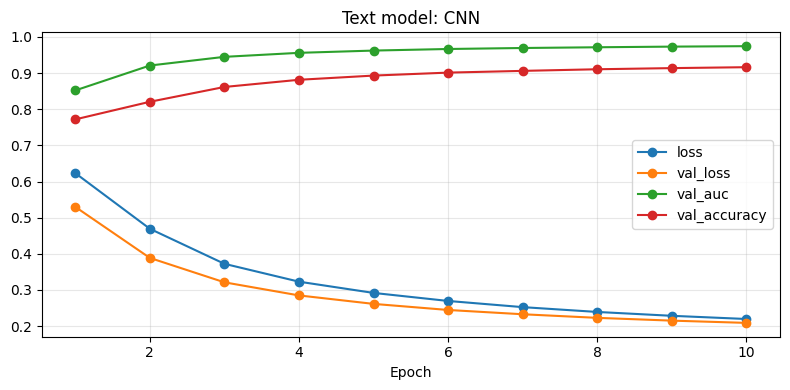

  saved plot -> /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/training_curve_text_cnn.png

────────────────────────────────────────────────────────────
TEXT — LSTM+Attn  (9 epochs)
────────────────────────────────────────────────────────────
 epoch     loss  val_loss  accuracy  val_accuracy      auc  val_auc
     1 0.582490  0.475076  0.699227      0.794020 0.763624 0.860069
     2 0.453259  0.400249  0.788293      0.833436 0.870083 0.904258
     3 0.393662  0.358586  0.826724      0.855717 0.904218 0.924458
     4 0.363091  0.335721  0.845313      0.865918 0.918933 0.933938
     5 0.339760  0.304381  0.858534      0.879742 0.929152 0.943227
     6 0.313965  0.283067  0.871895      0.887628 0.939239 0.951287
     7 0.290932  0.299826  0.882035      0.881351 0.947672 0.947156
     8 0.273684  0.318065  0.889979      0.878781 0.953645 0.942258
     9 0.264173  0.317536  0.894380      0.882396 0.956765 0.944985


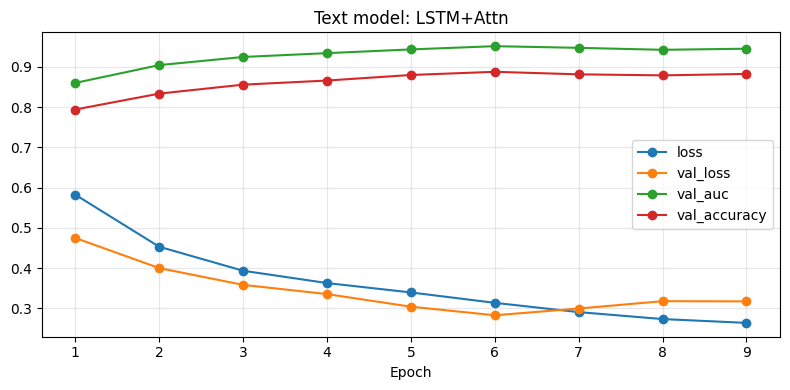

  saved plot -> /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/training_curve_text_lstm_attn.png

────────────────────────────────────────────────────────────
TEXT — BiLSTM+Attn  (10 epochs)
────────────────────────────────────────────────────────────
 epoch     loss  val_loss  accuracy  val_accuracy      auc  val_auc
     1 0.550610  0.422978  0.736191      0.812418 0.802178 0.891629
     2 0.419575  0.352149  0.815631      0.848014 0.890465 0.926049
     3 0.358918  0.319773  0.847677      0.872505 0.920948 0.940484
     4 0.317965  0.314200  0.869410      0.874214 0.938393 0.943905
     5 0.296143  0.316319  0.879719      0.877165 0.946340 0.944201
     6 0.281824  0.300116  0.886490      0.883377 0.951238 0.949304
     7 0.269664  0.307993  0.892116      0.884465 0.955343 0.948993
     8 0.258593  0.264145  0.896991      0.897511 0.958935 0.959639
     9 0.249539  0.249446  0.901014      0.902044 0.961739 0.963283
    10 0.242188  0.243396  0.904531 

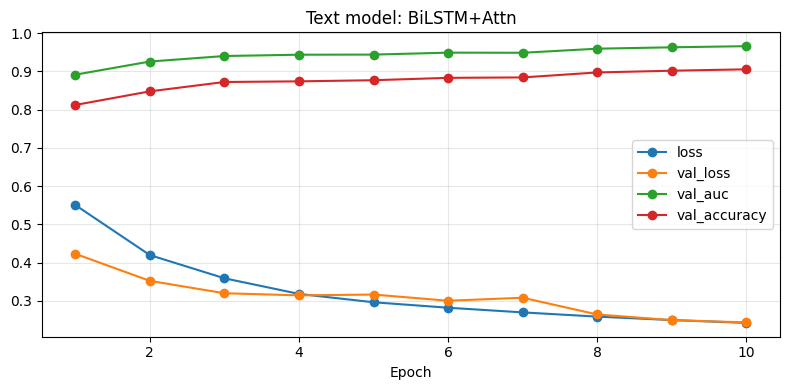

  saved plot -> /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/training_curve_text_bilstm_attn.png

────────────────────────────────────────────────────────────
TEXT — Hybrid  (10 epochs)
────────────────────────────────────────────────────────────
 epoch     loss  val_loss  accuracy  val_accuracy      auc  val_auc
     1 0.542613  0.390358  0.704035      0.817607 0.792485 0.905567
     2 0.337900  0.291774  0.856601      0.891991 0.929371 0.951988
     3 0.262023  0.346401  0.899091      0.875379 0.957167 0.961378
     4 0.233771  0.225284  0.911877      0.918338 0.965257 0.968410
     5 0.212499  0.201427  0.920397      0.927615 0.970718 0.973979
     6 0.199885  0.189683  0.925550      0.931611 0.973884 0.976606
     7 0.194186  0.187498  0.927881      0.931201 0.975349 0.977563
     8 0.184552  0.195973  0.932070      0.934519 0.977426 0.978816
     9 0.180834  0.195973  0.933400      0.928540 0.978235 0.979608
    10 0.172798  0.177618  0.936998    

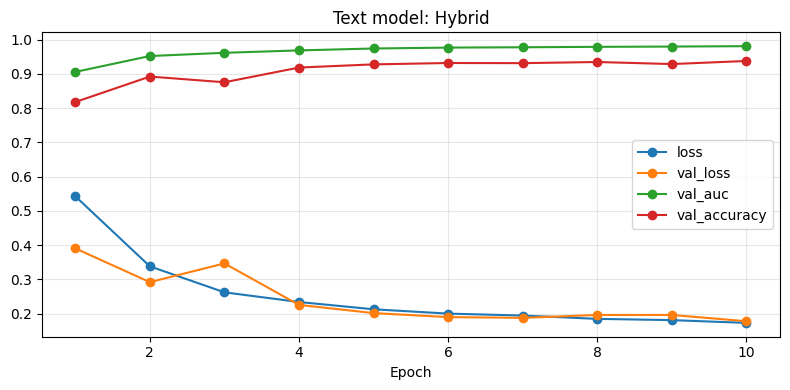

  saved plot -> /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/training_curve_text_hybrid.png

────────────────────────────────────────────────────────────
TEXT — Ultimate_Pro  (10 epochs)
────────────────────────────────────────────────────────────
 epoch     loss  val_loss  accuracy  val_accuracy      auc  val_auc
     1 0.537835  0.324185  0.726637      0.858484 0.802246 0.939823
     2 0.308810  0.220136  0.874506      0.916714 0.941388 0.970135
     3 0.239919  0.178614  0.904865      0.934251 0.964118 0.979922
     4 0.208106  0.154580  0.919828      0.942010 0.972604 0.984772
     5 0.187391  0.140146  0.928489      0.947121 0.977461 0.987237
     6 0.173295  0.135492  0.934309      0.949472 0.980503 0.988455
     7 0.162436  0.125539  0.938431      0.952614 0.982764 0.989482
     8 0.154568  0.118666  0.941974      0.955487 0.984244 0.990536
     9 0.148299  0.119774  0.944262      0.956476 0.985388 0.990489
    10 0.142614  0.111996  0.946400   

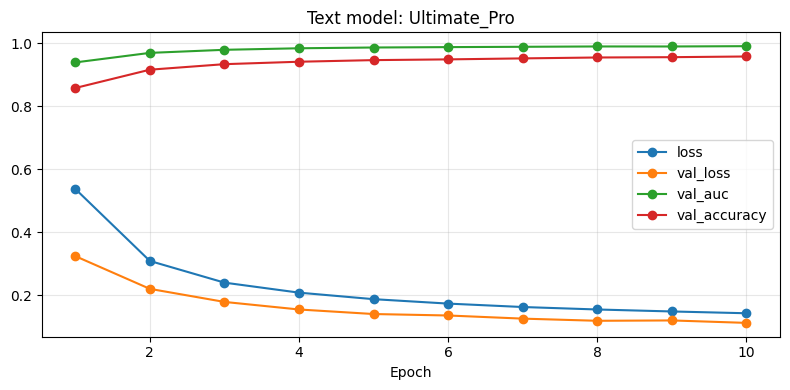

  saved plot -> /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/training_curve_text_ultimate_pro.png

────────────────────────────────────────────────────────────
VISION — ResNet-18 v6.3  (15 epochs)
────────────────────────────────────────────────────────────
 epoch  train_loss  val_f1  val_fpr  val_tpr  val_balanced  minutes
     1      0.0547  0.9987   0.0013   0.9994        0.9990     1.39
     2      0.0072  0.9962   0.0008   0.9937        0.9964     0.82
     3      0.0080  0.9975   0.0034   1.0000        0.9983     0.82
     4      0.0066  0.9994   0.0008   1.0000        0.9996     0.82
     5      0.0041  0.9994   0.0008   1.0000        0.9996     0.82
     6      0.0041  0.9978   0.0013   0.9975        0.9981     0.82
     7      0.0034  0.9528   0.0660   1.0000        0.9670     0.82
     8      0.0044  0.9994   0.0008   1.0000        0.9996     0.82
     9      0.0028  0.9997   0.0004   1.0000        0.9998     0.81
    10      0.0028  0.9997  

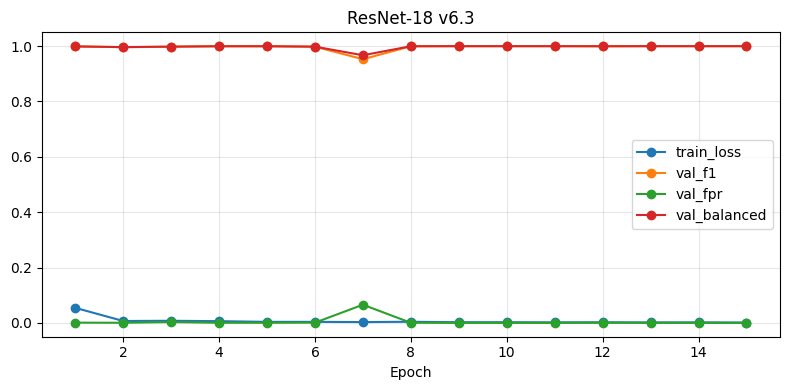

  saved plot -> /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/training_curve_resnet_v63.png

Look for JSON/PNG in:
  /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis


In [38]:
# ═══ Cell 28 — Training epochs per model (separate view) ═══
# Run after Cell 10 (text) and/or Cell 10B (ResNet). Requires Cell 2 paths.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("TRAINING EPOCHS — each model separately")
print("=" * 60)

_res = Path(RESULTS_DIR)
_text_dir = Path(TEXT_MODELS_DIR) if "TEXT_MODELS_DIR" in dir() else Path(MODELS_DIR)
_vision_dir = Path(MODELS_DIR) / "vision"

TEXT_MODELS = ["CNN", "LSTM+Attn", "BiLSTM+Attn", "Hybrid", "Ultimate_Pro"]

def _load_json(path):
    path = Path(path)
    if path.is_file():
        return json.loads(path.read_text(encoding="utf-8"))
    return None

def _show_table(title, rows, metrics=("loss", "val_f1", "val_fpr", "val_balanced", "val_accuracy", "val_auc")):
    if not rows:
        print(f"\n[{title}] — no epoch history file found")
        return None
    df = pd.DataFrame(rows)
    if "epoch" not in df.columns:
        df.insert(0, "epoch", range(1, len(df) + 1))
    cols = ["epoch"] + [c for c in metrics if c in df.columns]
    print(f"\n{'─'*60}\n{title}  ({len(df)} epochs)\n{'─'*60}")
    print(df[cols].to_string(index=False))
    return df

def _plot_model(df, title, y_cols, fname):
    if df is None or df.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    for col in y_cols:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], marker="o", label=col)
    ax.set_xlabel("Epoch")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    out = _res / fname
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150)
    plt.show()
    print(f"  saved plot -> {out}")

# ── 1) Text models (Keras) ───────────────────────────────────────────────────
for name in TEXT_MODELS:
    safe = name.lower().replace("+", "_").replace(" ", "_")
    hist = None
    for root in (_res, _text_dir, Path(MODELS_DIR)):
        hist = _load_json(root / f"text_training_history_{safe}.json")
        if hist:
            break
    df = _show_table(f"TEXT — {name}", hist,
                     metrics=("loss", "val_loss", "accuracy", "val_accuracy", "auc", "val_auc"))
    if df is not None:
        ycols = [c for c in ("loss", "val_loss", "val_auc", "val_accuracy") if c in df.columns]
        _plot_model(df, f"Text model: {name}", ycols, f"training_curve_text_{safe}.png")

# ── 2) ResNet v6.3 ───────────────────────────────────────────────────────────
vis_hist = _load_json(_res / "vision_training_history_v63.json")
if not vis_hist:
    rep = _load_json(_res / "vision_train_report_v63.json")
    if rep and "epoch_history" in rep:
        vis_hist = rep["epoch_history"]
if not vis_hist:
    st = _load_json(_vision_dir / "training_status_v63.json")
    if st:
        vis_hist = [st]
        print("\n[ResNet v6.3] only LAST epoch in training_status_v63.json (full history missing)")

df_vis = _show_table("VISION — ResNet-18 v6.3", vis_hist,
                     metrics=("train_loss", "val_f1", "val_fpr", "val_tpr", "val_balanced", "minutes"))
_plot_model(df_vis, "ResNet-18 v6.3", ["train_loss", "val_f1", "val_fpr", "val_balanced"],
            "training_curve_resnet_v63.png")

# ── 3) Summary files on Drive ────────────────────────────────────────────────
print(f"\n{'='*60}\nLook for JSON/PNG in:\n  {_res}\n{'='*60}")


In [39]:
# ═══ Cell THESIS — One-table summary for committee (run after 14, 22, 27F) ═══
# Requires: Cell 14 holdout, Cell 22 demo100, Cell 27F ablation (optional)
import json
from pathlib import Path
import pandas as pd

print("=" * 70)
print("THESIS UNIFIED SUMMARY — one table for committee")
print("=" * 70)

rows = []

# --- Primary: holdout (Cell 14 style) ---
if "hom_lbl" in dir() and "best_model" in dir():
    def _holdout_row(name, urls, labels, tag="v6_text"):
        seq = batch_encode_sequences(urls)
        lex = batch_encode_lexical(urls)
        raw = predict_model(best_model, seq, lex, use_lexical=True)
        if "adjust_preds_batch" in dir():
            probs = adjust_preds_batch(urls, raw)
        else:
            probs = raw
        preds = (probs >= FINAL_THRESHOLD).astype(int)
        lbl = labels.astype(int)
        if lbl.sum() == len(lbl):
            metric, val = "TPR", float(preds.mean())
        else:
            metric, val = "FPR", float(preds.mean())
        return {"system": tag, "eval": "holdout", "set": name, "metric": metric, "value": round(val, 4), "n": len(lbl)}

    rows.append(_holdout_row("homoglyph", hom_hold["url"].values, hom_hold["label"].values))
    rows.append(_holdout_row("unicode_safe", uni_hold["url"].values, uni_hold["label"].values))
    rows.append(_holdout_row("trusted_safe", trust_hold["url"].values, trust_hold["label"].values))

# --- Demo100 by category (Cell 22) ---
if "demo100_urls" in dir() and "demo100_cat" in dir():
    raw = predict_model(best_model, batch_encode_sequences(demo100_urls), batch_encode_lexical(demo100_urls), True)
    preds = (raw >= FINAL_THRESHOLD).astype(int)
    for cat in sorted(set(demo100_cat)):
        m = demo100_cat == cat
        acc = float((preds[m] == demo100_lbl[m]).mean())
        rows.append({"system": "v6_text", "eval": "demo100", "set": cat, "metric": "accuracy", "value": round(acc, 4), "n": int(m.sum())})

# --- Optional v6.5 text comparison ---
if "TEXT_MODELS_V65" in dir():
    import os, tensorflow as tf
    v65_p = os.path.join(TEXT_MODELS_V65, "best_ultimate_pro.keras")
    if os.path.isfile(v65_p) and "demo100_urls" in dir():
        m65 = tf.keras.models.load_model(v65_p, custom_objects=CUSTOM_OBJECTS, compile=False)
        raw65 = predict_model(m65, batch_encode_sequences(demo100_urls), batch_encode_lexical(demo100_urls), True)
        p65 = (raw65 >= FINAL_THRESHOLD).astype(int)
        gp = demo100_cat == "general_phish"
        if gp.any():
            acc = float((p65[gp] == demo100_lbl[gp]).mean())
            rows.append({"system": "v65_text", "eval": "demo100", "set": "general_phish", "metric": "accuracy", "value": round(acc, 4), "n": int(gp.sum())})
        hm = demo100_cat == "homoglyph"
        if hm.any():
            acc = float((p65[hm] == demo100_lbl[hm]).mean())
            rows.append({"system": "v65_text", "eval": "demo100", "set": "homoglyph", "metric": "accuracy", "value": round(acc, 4), "n": int(hm.sum())})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
out = Path(RESULTS_DIR) / "thesis_unified_summary.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)
print(f"\nSaved -> {out}")
print("\n--- Committee script (Kurdish) ---")
print("Primary: holdout homoglyph TPR + unicode/trusted FPR (Cell 14).")
print("Demo100: exploratory; general_phish limitation = future HTML/LLM work.")
print("System stack: v6 text + v63 vision + v6.4 dual-τ cascade.")


THESIS UNIFIED SUMMARY — one table for committee
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 5,000/5,000
  lexical   5,000/5,000
  sequences 2,500/2,500
  lexical   2,500/2,500
  sequences 100/100
  lexical   100/100
 system    eval             set   metric  value    n
v6_text holdout       homoglyph      TPR 0.9962 5000
v6_text holdout    unicode_safe      FPR 0.0000 5000
v6_text holdout    trusted_safe      FPR 0.0228 2500
v6_text demo100   general_phish accuracy 0.6000   20
v6_text demo100       homoglyph accuracy 0.8000   15
v6_text demo100       shortener accuracy 0.9231   13
v6_text demo100    trusted_safe accuracy 1.0000   15
v6_text demo100       typosquat accuracy 0.9565   23
v6_text demo100 typosquat_extra accuracy 1.0000    2
v6_text demo100    unicode_safe accuracy 1.0000   12

Saved -> /content/drive/MyDrive/Master2026/All_Models/Thesis_Models_2026/results_thesis/thesis_unified_summary.csv

--- Committee script (Kurdish) ---
Primary: holdout homoglyph TPR +